<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

 - **Readability and structure**: The notebook is well organized with clearly defined parts and headers. Markdown celles are used to outline tasks and interpretations, making the solution easy to read and follow. All imports are located in part 0, along with clearifications for the output. 
 - **Use of functions**: Functions are used throughout the solution to avoid duplication of code. Additionaly, the dataclass `MultiOutputModel` avoids reuse of code to stack multiple outputs.

# **Group Term Paper 2**
### Candidate numbers: 44, 117 & 185

### **AI Declaration**
For this term paper, we  have used generative AI tools, specifically Claude and SiktKI, as support tools in this assignment.  Specifically, AI was used to:

- Suggest improvements in the structure and wording of our explanations
- Assist with error handling and debugging by interpreting error messages.
- Explain how certain functions and components work in practice (e.g., `Pipeline`, `Confusion matrix` etc.).
- Design layout for tables, correlation tables and colors.

All code has been written and verified by us, and we have critically evaluated any suggestions provided by AI before incorporating them. The final analysis, interpretations, and written explanations are our own work. We have not copied any AI-generated output directly without modification, and we take full responsibility for the content of this assignment.

***
# **Abstract**
***


This paper set out to predict household expectations about inflation, house prices, unemployment, and the stock market using data from the Survey of Consumer Expectations (SCE), augmented with macroeconomic and financial variables from FRED and Yahoo Finance.

Macro and financial variables alone prove insufficient to predict individual-level expectations, yielding $R^2$ values close to zero or negative across all targets. Adding demographic characteristics through forward inclusion produces some improvements, most notably for stock market expectations where $R^2$ rises to approximately 9.4%. Among the regression models, *Ridge*, *Lasso*, and *ElasticNet* performs similarily and outperform both Linear Regression and Decision Tree.

For the classification task, most models collapse to predicting the majority class regardless of feature set. The exception is `optimist_stocks`, where adding individual variables allows KNN to achieve a test F1 of 0.300, confirming that demographic characteristics carry predictive signal for stock market optimism that macro variables alone cannot capture. While much of the variation in household expectations remains unexplained, the results suggest that expectations are partly systematic and can be partially predicted from key demographic and macroeconomic characteristics.



***
# **Part 0 - Preparing the enviroment**
***


Before we start, we import the necessary libraries for the analysis and create a color palette for the plots.

In [1]:
# Importing the required libraries for all the parts of the project

# Part 0: Preparing the enviornment
from matplotlib.colors import LinearSegmentedColormap  # For creating custom color maps for plots

# Part 1: Data preprocessing (SCE)
import pandas as pd                                    # For data manipulation and analysis
import numpy as np                                     # For numerical operations
import glob                                            # For file handling  

# Part 2: Data preprocessing (macro/finance)
import os                                              # For file handling
import yfinance as yf                                  # For downloading from Yahoo Finance
import pandas_datareader.data as pdr                   # For downloading from FRED

# Part 3: Model deployment (SCE)
import matplotlib.pyplot as plt                        # For data visualization

# Part 5: Predictive continuous expectation variables
from dataclasses import dataclass                                                              # For creating a simple data class to hold model information
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, LassoCV, ElasticNetCV       # For linear regression with cross-validation
from sklearn.preprocessing import OneHotEncoder, StandardScaler                                # For encoding categorical variables
from sklearn.model_selection import cross_val_score, KFold                                     # For cross-validation
from sklearn.metrics import mean_squared_error, r2_score                                       # For evaluating model performance
from sklearn.tree import DecisionTreeRegressor                                                 # For Decision Tree regression

# Part 6: Predictive classification variables
from sklearn.linear_model import LogisticRegression                                                             # For logistic regression with cross-validation
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier                             # For Random Forest classification
from sklearn.model_selection import GridSearchCV                                                                # For hyperparameter tuning with cross-validation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay     # For evaluating classification model performance
from sklearn.neighbors import KNeighborsClassifier                                                              # For K-Nearest Neighbors classification
from sklearn.pipeline import Pipeline                                                                           # For creating a pipeline to streamline preprocessing and modeling

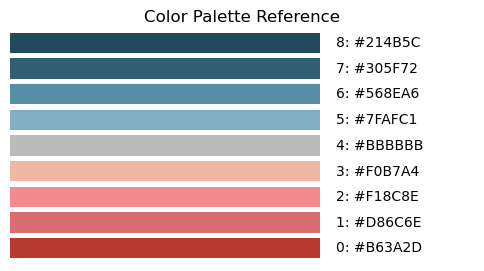

In [2]:
# Color palette for the plots
colors = ['#B63A2D', '#D86C6E', '#F18C8E', '#F0B7A4', '#BBBBBB', '#7FAFC1', '#568EA6', '#305F72','#214B5C']

# Plotting the color palette for easy reference
plt.figure(figsize=(6, 3))
for i, color in enumerate(colors):
    _ = plt.barh(y=i, width=1, color=color)
    _ =plt.text(x=1.05, y=i, s=f"{i}: {color}", va='center')

# Adjust plot limits and turn off axes
plt.ylim(-0.5, len(colors) - 0.5)
plt.xlim(0, 1.5)
plt.axis("off")
_ = plt.title("Color Palette Reference")

# Create a LinearSegmentedColormap object from the defined colors for use in plots
c_map = LinearSegmentedColormap.from_list("custom", ['#FFFFFF', colors[i]])

***
# **Part 1 - Data preprocessing (SCE)**
***

### **1.1 - Import and merge the data contained <tt>sce_extract_YYYY.csv<tt>**

In [3]:
# Path to data directory
DATA_PATH = './data'

In [4]:
#Path to CSV file with the data
file_paths = glob.glob(f"{DATA_PATH}/sce_extract_*.csv")

In [5]:
# Creating a empty list to store the dataframes
dfs = []
for file_path in file_paths:
    df = pd.read_csv(file_path)
    dfs.append(df)  

# Concatenating all the dataframes into a single dataframe
sce = pd.concat(dfs, ignore_index=True)

In [6]:
# Saving intitial data sample
sce_raw = sce.copy()

# Initial sample stats
n_individuals_init  = sce_raw['userid'].nunique()
n_obs_init          = len(sce_raw)
n_waves_init        = sce_raw['wid'].nunique()
date_first_init     = pd.to_datetime(sce_raw['date']).min().strftime('%Y-%m-%d')
date_last_init      = pd.to_datetime(sce_raw['date']).max().strftime('%Y-%m-%d')

### **1.2 - Forward-fill variables only asked in the initial wave**

In [7]:
# Sort by userid and date to ensure waves are in chronological order
sce = sce.sort_values(["userid", "date"]).reset_index(drop=True)

# Define variables to forward-fill (only asked in first wave)
vars_to_ffill = [
    'owner',               
    'couple',             
]

# Forward-fill within each respondent
sce[vars_to_ffill] = sce.groupby("userid")[vars_to_ffill].ffill()


We forward-fill variables that are only asked in the first interview wave of each respondent and are expected to remain stable throughout the observation period. 

We forward-fill the following variables: 
- **`owner`**: Whether the respondent owns their home 
- **`couple`**: Whether the respondent lives with a partner 

We considered forward-filling health, but decided against it for two reasons. First, the variable has a high share of missing values, and lastly the health status can plausibly change within a 12-month period, making it less reliable to carry forward.

We also considered forward-filling the numerical literacy variables, but ultimately excluded them from the analysis. Questions 8 and 9, which specifically test economic and financial understanding have a high share of missing values which leads to a small data sample. The remaining questions (1–6) are basic mathematical questions that do not necessarily require economic understanding. We believe that respondents who have completed even the lowest education level would generally be able to answer these correctly. Therefore, we argue that education already captures most of the variation in these questions, and that they provide little additional predictive value. Had questions 8 and 9 been available for a larger share of the sample, they would have been worth retaining given their more direct relevance to economic expectation formation.

### **1.3 - Drop all survey waves for the year 2025**

In [8]:
# Convert 'date' column to datetime format
sce["date"] = pd.to_datetime(sce["date"], format="%Y-%m-%d")

# Drop all 2025 observations
n_before = len(sce)
sce = sce[sce['date'].dt.year != 2025]
n_dropped_2025 = n_before - len(sce)

In [9]:
def print_obs_summary(title, n_before, n_after, label_dropped):
    """
    Parameters:
    ------------------
    title:
        Title for the summary table
    n_before:
        Number of observations before dropping
    n_after:
        Number of observations after dropping
    label_dropped:
        Label describing the reason for dropping observations
    """
    n_dropped = n_before - n_after

    tbl = pd.DataFrame({
        '': [f'{n_before:,}', f'{n_dropped:,}', f'{n_after:,}']
    }, index=['Total observations before',
              f'Observations dropped ({label_dropped})',
              'Observations remaining'])
    tbl.index.name = 'Summary'
    
    print(f"\n{'=' * 55}")
    print(f"  Sample Summary")
    print(f"{'=' * 55}")
    display(tbl)

In [10]:
# Print summary of observations before and after dropping 2025 using the function
print_obs_summary('Summary before and after dropping 2025:', n_before, len(sce), '2025')


  Sample Summary


,
Summary,
Total observations before,"180,268"
Observations dropped (2025),"4,167"
Observations remaining,"176,101"


### **1.4 - Drop observations with missing data for key variables**

Before selecting our variables, we examine the share of missing values across all variables in the dataset. Variables with a high fraction of missing observations are  excluded from the analysis, as including them would either severely reduce our sample size or require imputation that could introduce bias.

In [11]:
# Check missing values for all variables
missing_pct = sce.isnull().mean() * 100

# Print missing values for all SCE variables
tbl = missing_pct.sort_values(ascending=False).reset_index()
tbl.columns = ['Variable', 'Missing %']
tbl['Missing %'] = tbl['Missing %'].map('{:.2f}%'.format)
tbl = tbl.set_index('Variable')

print(f"\n{'=' * 55}")
print(f"  Sample Summary")
print(f"{'=' * 55}")
with pd.option_context('display.max_rows', None):
    display(tbl)


  Sample Summary


,Missing %
Variable,
prob_accept_job_12m,97.29%
prob_accept_job_3m,97.29%
jobless_length,96.51%
num_lit_q9_correct,89.82%
num_lit_q9,89.82%
num_lit_q8_correct,89.79%
num_lit_q8,89.79%
health,89.78%
num_lit_q6,86.85%


We exclude all variables with more than 10% missing values, as these are either only asked to a specific subgroup of respondents such as employment-related variables that are only asked to workers, or collected too infrequently to be useful.

From the remaining variables, we select those most likely to have predictive value for household expectations. Specifically, we include:
- **Target variables**: The four expectation variables we aim to predict.
- **Meta variables**: Identifiers and survey weights needed for tracking and weighting.
- **Individual-level features**: Demographic and socioeconomic characteristics such as age, gender, education, income, homeownership, and household composition, which prior research suggests are strong predictors of expectation formation.

In [12]:
# Target variables
target_vars = ["infl_1y", "house_price_change", "prob_unrate_up", "prob_stocks_up"]

# Meta vars
meta_vars = ["userid", "wid", "date", "weight", "tenure"]

# Individual-level features
individual_vars = ["age_init", "female", "hispanic", "black", "educ",  
                   "working", "owner", "hh_inc_bin_rank", "couple", "num_kids"]  

# Keep only the selected variables in the dataframe
sce = sce[target_vars + individual_vars + meta_vars]

# Drop observations with missing values in selected variables
n_before = len(sce)
sce = sce.dropna()
n_dropped_missing = n_before - len(sce)

# Print summary of observations before and after dropping missing values 
print_obs_summary('Summary before and after dropping missing values:', n_before, len(sce), 'missing')


  Sample Summary


,
Summary,
Total observations before,"176,101"
Observations dropped (missing),"4,215"
Observations remaining,"171,886"


### **1.5 - Remove outliers**

In [13]:
# Store number of observations before dropping outliers for later summary
n_before_var = len(sce)

# Drop observations outside 1st and 99th percentile in target variables
for var in target_vars:
    p1 = sce[var].quantile(0.01)
    p99 = sce[var].quantile(0.99)
    sce = sce[(sce[var] > p1) & (sce[var] < p99)] # Keep only observation strictly between p1 and p99

# Calculate number of observations dropped due to outliers
n_dropped_outliers =  n_before_var - len(sce)

In [14]:
# Final sample stats 
n_individuals_final  = sce['userid'].nunique()
n_obs_final          = len(sce)
n_waves_final        = sce['wid'].nunique()
date_first_final     = pd.to_datetime(sce['date']).min().strftime('%Y-%m-%d')
date_last_final      = pd.to_datetime(sce['date']).max().strftime('%Y-%m-%d')

# Initial sample table
tbl_initial = pd.DataFrame({
    '': [
        f'{n_individuals_init:,}',
        f'{n_obs_init:,}',
        f'{n_waves_init:,}',
        str(date_first_init),
        str(date_last_init)
    ]
}, index=['Number of individuals', 'Number of observations',
          'Number of survey waves', 'First survey date', 'Last survey date'])
tbl_initial.index.name = 'Initial Sample'

# Final sample table
tbl_final = pd.DataFrame({
    '': [
        f'{n_individuals_final:,}',
        f'{n_obs_final:,}',
        f'{n_waves_final:,}',
        str(date_first_final),
        str(date_last_final)
    ]
}, index=['Number of individuals', 'Number of observations',
          'Number of survey waves', 'First survey date', 'Last survey date'])
tbl_final.index.name = 'Final Sample'

# Observations dropped table
tbl_dropped = pd.DataFrame({
    '': [
        f'{n_dropped_2025:,}',
        f'{n_dropped_missing:,}',
        f'{n_dropped_outliers:,}',
        f'{n_obs_init - n_obs_final:,}'
    ]
}, index=['Drop 2025 waves', 'Drop missing values',
          'Drop outliers', 'Total observations dropped'])
tbl_dropped.index.name = 'Observations Dropped'

# Print all three tables
print(f"\n{'=' * 55}")
print(f"  Sample Summary")
print(f"{'=' * 55}")
display(tbl_initial)
display(tbl_final)
display(tbl_dropped)


  Sample Summary


,
Initial Sample,
Number of individuals,"23,886"
Number of observations,"180,268"
Number of survey waves,143
First survey date,2013-06-01
Last survey date,2025-05-01


,
Final Sample,
Number of individuals,"22,024"
Number of observations,"154,201"
Number of survey waves,139
First survey date,2013-06-01
Last survey date,2024-12-31


,
Observations Dropped,
Drop 2025 waves,"4,167"
Drop missing values,"4,215"
Drop outliers,"17,685"
Total observations dropped,"26,067"


### **1.6 - Create indicator variables**

In [15]:
# Create binary optimism indicator variables
sce['optimist_unrate'] = (sce['prob_unrate_up'] < 50).astype(int)           # 1 if probability of unemployment increase < 50%, if not 0
sce['optimist_stocks'] = (sce['prob_stocks_up'] > 50).astype(int)           # 1 if probability of stock market increase > 50%, if not 0
sce['optimist_house_price'] = (sce['house_price_change'] > 0).astype(int)   # 1 if respondent expects house prices to increase, if not 0

# List of optimism indicator variables
opt_vars   = ['optimist_unrate', 'optimist_stocks', 'optimist_house_price']

# Verify that the indicator variables were created correctly by printing their means (should be between 0 and 1)
tbl = pd.DataFrame({
    'Mean': [
        f"{sce['optimist_unrate'].mean():.3f}",
        f"{sce['optimist_stocks'].mean():.3f}",
        f"{sce['optimist_house_price'].mean():.3f}"
    ]
}, index=['Optimist unrate', 'Optimist stocks', 'Optimist house price'])
tbl.index.name = 'Indicator Variables (mean = share of optimists)'

print(f"\n{'=' * 55}")
print(f"  Indicator variables created (mean = share of optimists)")
print(f"{'=' * 55}")
display(tbl)


  Indicator variables created (mean = share of optimists)


,Mean
Indicator Variables (mean = share of optimists),
Optimist unrate,0.601
Optimist stocks,0.304
Optimist house price,0.837


<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 1**

 - **Structure and readability:** Markdown celles for interpretations and clearly defined subtasks make the code well structured and easy to follow. The code is also well-documented, with comments and doc-strings to define functions and explain concepts. 

 - **Use of functions:** Only one function (`print_obs_summary`) is defined to print a summary of observations after cleaning the dataset. Although this is perfectly fine for this part of the task, the following code (such as removing outliers) could be done with functions.

 - **Vectorization:** Both loops and vectorization are used to solve part 1. A clip-function could be used for a more effective solution (cell 29, removing outliers), although a loop is sufficient for this task. 

 - **Feature selection:** The 10% missing values limit is reasonable, but could benefit from additional argumentation. 

***
# **Part 2 - Data preprocessing (macro/finance)**
***

In [16]:
#Start and end dates for the data download
start = "2012-01-01"
end = "2024-12-31"

The macro/finance data is downloaded from 2012-01-01, one year before the first SCE observations in 2013. This is necessary because the merge strategy uses lagged values. For a respondent surveyed in month $t$, we use macro data from the end of month $t-1$ to avoid look-ahead bias. Additionally, 12-month differences of the macro variables require observations from 12 months prior. Starting the download in 2012 ensures that all lagged and differenced features are available for the earliest SCE observations without introducing missing values.

#### **Downloading the external data**

##### Downloading from Yahoo Finance

In [17]:
#Ticker symbols for bulk download
tickers = ["CL=F", "^GSPC"]

# Only download if file does not already exist
if not os.path.exists(f"{DATA_PATH}/oil_price.csv"):
    data = yf.download(tickers, start=start, end=end, auto_adjust=True)
    oil  = data['Close']['CL=F'].to_frame(name='oil_price')
    sp500 = data['Close']['^GSPC'].to_frame(name='sp500')
    oil.to_csv(f"{DATA_PATH}/oil_price.csv")
    sp500.to_csv(f"{DATA_PATH}/sp500.csv")
    print("Downloaded and saved to CSV")
else:
    print("Files already exist, skipping download")

# Always load from CSV
oil   = pd.read_csv(f"{DATA_PATH}/oil_price.csv", index_col=0, parse_dates=True)
sp500 = pd.read_csv(f"{DATA_PATH}/sp500.csv", index_col=0, parse_dates=True)

Files already exist, skipping download


##### Downloading from FRED

In [18]:
# FRED series codes and their descriptive names
fred_series = {
    'CPIAUCSL':     'CPI',
    'USSTHPI':      'HPI',
    'FEDFUNDS':     'FedFunds',
    'UNRATE':       'Unrate',
    'GDPC1':        'GDP',
    'DTWEXBGS':     'Dollar',
    'MORTGAGE30US': 'Mortgage',
}

# Only download if file does not already exist
if not os.path.exists(f"{DATA_PATH}/fred_data.csv"):
    fred_data = pdr.get_data_fred(list(fred_series.keys()), start=start, end=end)
    fred_data = fred_data.rename(columns=fred_series)
    fred_data.to_csv(f"{DATA_PATH}/fred_data.csv")
    print("Downloaded and saved to CSV")
else:
    print("File already exists, skipping download")

# Always load from CSV
fred_data = pd.read_csv(f"{DATA_PATH}/fred_data.csv", index_col=0, parse_dates=True)

File already exists, skipping download


#### **Resample data to monthly frequency**

In [19]:
# Resample to monthly frequency (last observation of each month)
oil_monthly      = oil.resample('ME').last()                          # Resample daily data to monthly frequency
sp500_monthly    = sp500.resample('ME').last()                        # Resample daily data to monthly frequency
cpi_monthly      = fred_data[['CPI']].resample('ME').last()           # Resample monthly CPI
fedfunds_monthly = fred_data[['FedFunds']].resample('ME').last()      # Resample monthly Federal Funds Rate
unrate_monthly   = fred_data[['Unrate']].resample('ME').last()        # Resample monthly Unemployment Rate
dollar_monthly   = fred_data[['Dollar']].resample('ME').last()        # Resample weekly Dollar Index to monthly frequency
mortgage_monthly = fred_data[['Mortgage']].resample('ME').last()      # Resample weekly Mortgage Rate to monthly frequency

# Resample quarterly GDP and HPI to monthly frequency 
gdp_quarterly      = fred_data[['GDP']].dropna().copy()              # Resample quarterly GDP to quarterly frequency
gdp_quarterly.index = gdp_quarterly.index + pd.offsets.QuarterEnd(0) # Ensure index is in datetime format for resampling
gdp_monthly      = gdp_quarterly.resample('ME').last().ffill()       # Resample quarterly GDP to monthly frequency

hpi_quarterly      = fred_data[['HPI']].dropna().copy()              # Resample quarterly HPI to quarterly frequency
hpi_quarterly.index = hpi_quarterly.index + pd.offsets.QuarterEnd(0) # Ensure index is in datetime format for resampling
hpi_monthly      = hpi_quarterly.resample('ME').last().ffill()       # Resample quarterly HPI to monthly frequency

# Combine all monthly macroeconomic variables into a single dataframe
macro_levels = pd.concat(
    [oil_monthly, sp500_monthly, cpi_monthly, hpi_monthly,
     fedfunds_monthly, unrate_monthly, gdp_monthly, dollar_monthly, mortgage_monthly],
    axis=1
)

In [20]:
# Print summary of the loaded and resampled macro/finance data
rows = []
for col in macro_levels:
    valid = macro_levels[col].dropna()
    if len(valid) > 0:
        rows.append([len(valid), str(valid.index[0].date()), str(valid.index[-1].date())])
    else:
        rows.append([0, 'N/A', 'N/A'])

tbl = pd.DataFrame(rows, columns=['Observations', 'From', 'To'], index=macro_levels.columns)
tbl.index.name = 'Variable'

print(f"\n{'=' * 55}")
print(f"  Macro/finance data loaded and resampled to monthly frequency:")
print(f"{'=' * 55}")
display(tbl)


  Macro/finance data loaded and resampled to monthly frequency:


,Observations,From,To
Variable,,,
oil_price,156,2012-01-31,2024-12-31
sp500,156,2012-01-31,2024-12-31
CPI,156,2012-01-31,2024-12-31
HPI,154,2012-03-31,2024-12-31
FedFunds,156,2012-01-31,2024-12-31
Unrate,156,2012-01-31,2024-12-31
GDP,154,2012-03-31,2024-12-31
Dollar,156,2012-01-31,2024-12-31
Mortgage,156,2012-01-31,2024-12-31


**Note:** GDP and HPI have 154 observations instead of 156. This is because both variables are originally quarterly, meaning the first available data point falls on 2012-03-31 (end of Q1 2012). Since forward-filling cannot impute values before the first observation, January and February 2012 remain NaN, resulting in 2 fewer observations than the other series.

#### **Create differences of the time series**

In [21]:
# Relative 12-month differences (YoY) for daily/weekly/monthly series
cpi_rel_12m      = cpi_monthly.pct_change(12).rename(columns={'CPI': 'CPI_rel_12m'})
sp500_rel_12m    = sp500_monthly.pct_change(12).rename(columns={'sp500': 'sp500_rel_12m'})
oil_rel_12m      = oil_monthly.pct_change(12).rename(columns={'oil_price': 'oil_rel_12m'})
dollar_rel_12m   = dollar_monthly.pct_change(12).rename(columns={'Dollar': 'dollar_rel_12m'})

# Relative 4-quarter differences for quarterly series (forward filled to monthly)
hpi_rel_4q       = hpi_monthly.pct_change(4).rename(columns={'HPI': 'HPI_rel_4q'})
gdp_rel_4q       = gdp_monthly.pct_change(4).rename(columns={'GDP': 'GDP_rel_4q'})

# Absolute 1-month differences for rate variables
mortgage_abs_1m  = mortgage_monthly.diff(1).rename(columns={'Mortgage': 'mortgage_abs_1m'})

# DataFrame containing only the difference variables
macro_diffs = pd.concat(
    [
        cpi_rel_12m,
        sp500_rel_12m,
        oil_rel_12m,
        dollar_rel_12m,
        hpi_rel_4q,
        gdp_rel_4q,
        mortgage_abs_1m,
    ],
    axis=1
)

# DataFrame with differences + selected variables in levels
macro_features = pd.concat(
    [
        macro_diffs,
        # Levels
        unrate_monthly,
        fedfunds_monthly,
        oil_monthly,
        sp500_monthly,
        mortgage_monthly,
    ],
    axis=1
)

In [22]:
# Summary table derived automatically from macro_features columns
rows = []
for col in macro_features.columns:
    if '_rel_12m' in col:
        vtype, freq = 'Relative difference', 'Yearly (12m)'
    elif '_rel_4q' in col:
        vtype, freq = 'Relative difference', 'Yearly (4q)'
    elif '_abs_1m' in col:
        vtype, freq = 'Absolute difference', 'Monthly (1m)'
    else:
        vtype, freq = 'Level', 'Monthly'
    rows.append([vtype, freq])

tbl = pd.DataFrame(rows, columns=['Type', 'Frequency'], index=macro_features.columns)
tbl.index.name = 'Variable'

print(f"\n{'=' * 55}")
print(f"  Macro feature summary:")
print(f"{'=' * 55}")
display(tbl)


  Macro feature summary:


,Type,Frequency
Variable,,
CPI_rel_12m,Relative difference,Yearly (12m)
sp500_rel_12m,Relative difference,Yearly (12m)
oil_rel_12m,Relative difference,Yearly (12m)
dollar_rel_12m,Relative difference,Yearly (12m)
HPI_rel_4q,Relative difference,Yearly (4q)
GDP_rel_4q,Relative difference,Yearly (4q)
mortgage_abs_1m,Absolute difference,Monthly (1m)
Unrate,Level,Monthly
FedFunds,Level,Monthly


**Levels**

For variables such as the federal funds rate, the unemployment rate, and mortgage rates, the level is economically meaningful and likely relevant for household expectations, as these are quantities households directly observe and respond to.

**Relative differences (12m / 4q)**

CPI, S&P 500, oil, dollar index, HPI, and GDP are included as year-on-year changes. We assume households base their expectations largely on what they have experienced over time rather than recent monthly movements, making the 12-month horizon more informative than shorter-term changes. This also matches the 12-month prediction horizon of the SCE expectations variables.

**Absolute difference (1m)**

The mortgage rate is included as a 1-month absolute difference rather than a relative change, as a change of 0.25 percentage points is assumed to carry the same meaning regardless of the starting level. We use the 1-month change rather than the 12-month change as we assume it is the recent movement in mortgage rates that most directly affects housing affordability and purchasing decisions.

#### **Merge macro/finance data into SCE dataset**

In [23]:
# Combine levels and differences into one full macro DataFrame for merging
macro_all = pd.concat([macro_levels, macro_diffs], axis=1)

# Create merge key: last day of previous month
sce['merge_date'] = sce['date'].dt.to_period('M').dt.to_timestamp() - pd.offsets.MonthEnd(1)

# Merge all macro data into SCE (left join keeps only SCE dates)
sce = pd.merge(sce, macro_all, left_on='merge_date', right_index=True, how='left')

# Drop merge key
sce = sce.drop(columns=['merge_date'])

In [24]:
# Check how many observations have non-missing values for the macro variables after the merge
rows = []
for col in macro_all.columns:
    n_missing = sce[col].isna().sum()
    rows.append([f'{len(sce) - n_missing:,}', f'{n_missing:,}'])

tbl = pd.DataFrame(rows, columns=['Non-missing', 'Missing'], index=macro_all.columns)
tbl.index.name = 'Variable'

print(f"\n{'=' * 55}")
print(f"  Macro/finance data merged into SCE dataset:")
print(f"{'=' * 55}")
print(f"  Observations: {len(sce):,}    Total columns: {len(sce.columns):,}")
display(tbl)


  Macro/finance data merged into SCE dataset:
  Observations: 154,201    Total columns: 38


,Non-missing,Missing
Variable,,
oil_price,"154,201",0
sp500,"154,201",0
CPI,"154,201",0
HPI,"154,201",0
FedFunds,"154,201",0
Unrate,"154,201",0
GDP,"154,201",0
Dollar,"154,201",0
Mortgage,"154,201",0


<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 2**

 - **Structure and readability:** Downloads and resampling are seperated into clearly defined and commented parts, making the script easy to read. 

 - **Functions:** This part does not contain any functions. Although functions could be used, there would not be much duplication avoided.

 - **Vectorization:** Transformations are done using vectorized functions, such as `resample`, `pct_change` and `diff`, which improves efficiency.

 - **Explanation of additional variables:** Cell 49 clearly explains the use of relative differences for rate variables, and a absolute difference for the mortgage rate. The 1-month difference is both well argumented, and follows the correct solution of avoiding look-ahead bias. 

***
# **Part 3 - Exploratory data analysis (SCE)**
***


### **3.1 - Histograms of expectation variables**

In [25]:
# Define target labels for plotting
target_labels = ['Inflation expectations (1y)','House price change', 'Prob. unemployment increase','Prob. stock market increase']

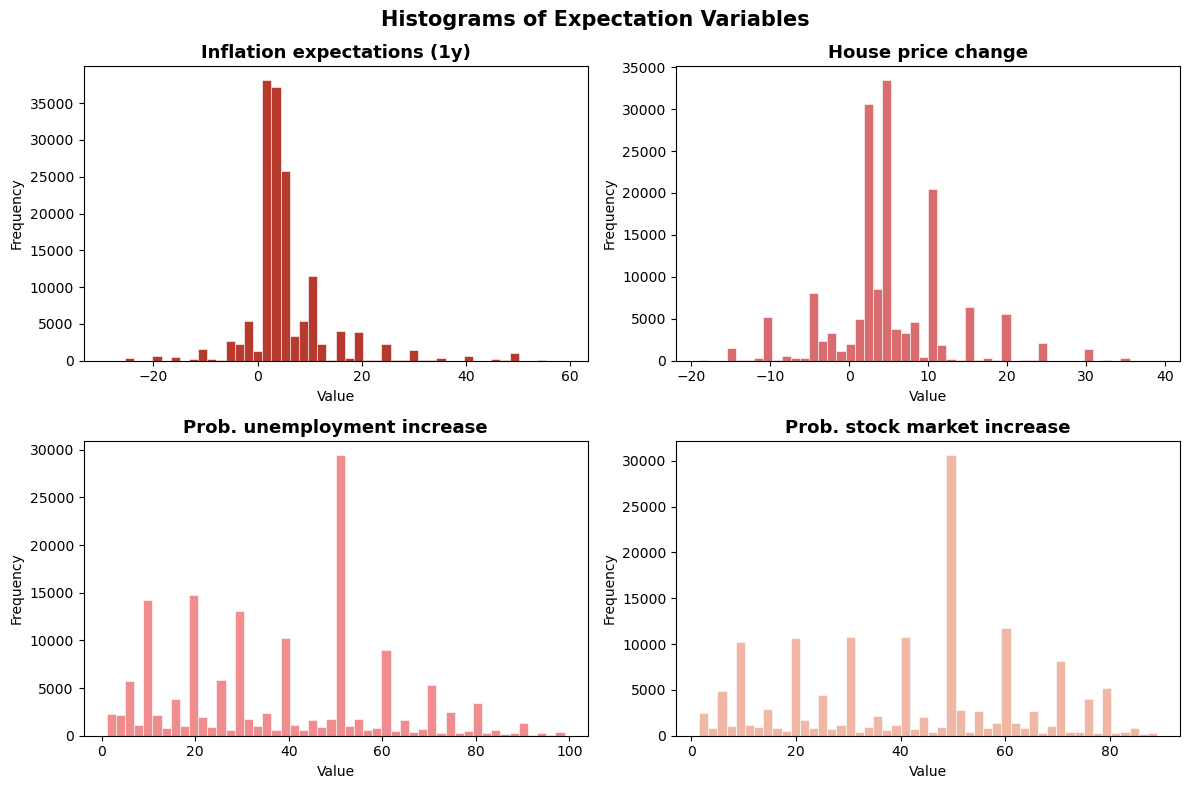

In [26]:
# Define layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Histograms for each target variable
for i, (var, label) in enumerate(zip(target_vars, target_labels)):
    axes[i].hist(sce[var], bins=50, color=colors[i], edgecolor='white', linewidth=0.4)           
    axes[i].set_title(label, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Adjust layout and print plot
fig.suptitle('Histograms of Expectation Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

**Inflation expectations** are centered around 2–4%, consistent with the Fed's 2% inflation target anchoring household expectations during the low-inflation period. The right skew and long tail can reflect the post-COVID inflation surge, where a subset of respondents might have updated their expectations upward.

**House price change** shows a similar right-skewed distribution centered near 3–5%, might reflecting the persistent upward trend in US house prices over the sample period. The notable mass at round numbers (0%, 5%, 10%) suggests **rounding behavior**, which is common in survey data where respondents anchor on salient values.

**Probability of unemployment increase** and **probability of stock market increase** are bounded between 0 and 100 by construction, and both display strong mass at round numbers (0, 10, 25, 50, 75, 100). Respondents might reflect uncertainty by choosing 50, rather than providing a precise probability estimate, which could explain the high spike at 50 for both plots. 

### **3.2 - Time series of average expectation variables**

In [27]:
# Function to plot time series of monthly average values for a list of variables
def plot_time_series(df, vars, labels, title, ncols=2, ylabel='Average value (%)', colors=colors, scale=1, show_overall_avg=True):
    """
    Plot time series of monthly average values for a list of variables, restricted to the SCE survey period.

    Parameters
    ----------
    df: 
        DataFrame with date as index or as a 'date' column
    vars: 
        list of column names to plot
    labels: 
        list of labels for each variable
    title: 
        title of the figure
    ncols: 
        number of columns in the subplot grid
    ylabel: 
        y-axis label
    colors: 
        list of colors for each subplot
    scale: 
        scaling factor for the y-axis
    show_overall_avg: 
        whether to show the overall average line
    """
    
    # Set date as index if it is a column
    if 'date' in df.columns:
        df = df.set_index('date')

    # Restrict to SCE survey period only if index is unique 
    if df.index.is_unique:
        sce_start = sce['date'].min()
        sce_end   = sce['date'].max()
        df        = df.loc[sce_start:sce_end]

    # Calculate number of rows needed
    nrows = int(np.ceil(len(vars) / ncols))

    # Calculate monthly average
    monthly_avg = df[vars].resample('ME').mean()

    # Create subplots
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
    axes = axes.flatten()

    # Plot time series for each variable
    for i, (var, label) in enumerate(zip(vars, labels)):
        axes[i].plot(monthly_avg.index, monthly_avg[var] * scale, color=colors[i], linewidth=1.5)
        if show_overall_avg:
            overall_avg = df[var].mean() * scale
            axes[i].axhline(overall_avg, color='gray', linestyle='--', linewidth=1, label='Overall avg')
            axes[i].legend(fontsize=9)
        axes[i].set_title(label, fontsize=13, fontweight='bold')
        axes[i].set_xlabel('Date')
        axes[i].set_ylabel(ylabel)
        axes[i].tick_params(axis='x', rotation=45)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()

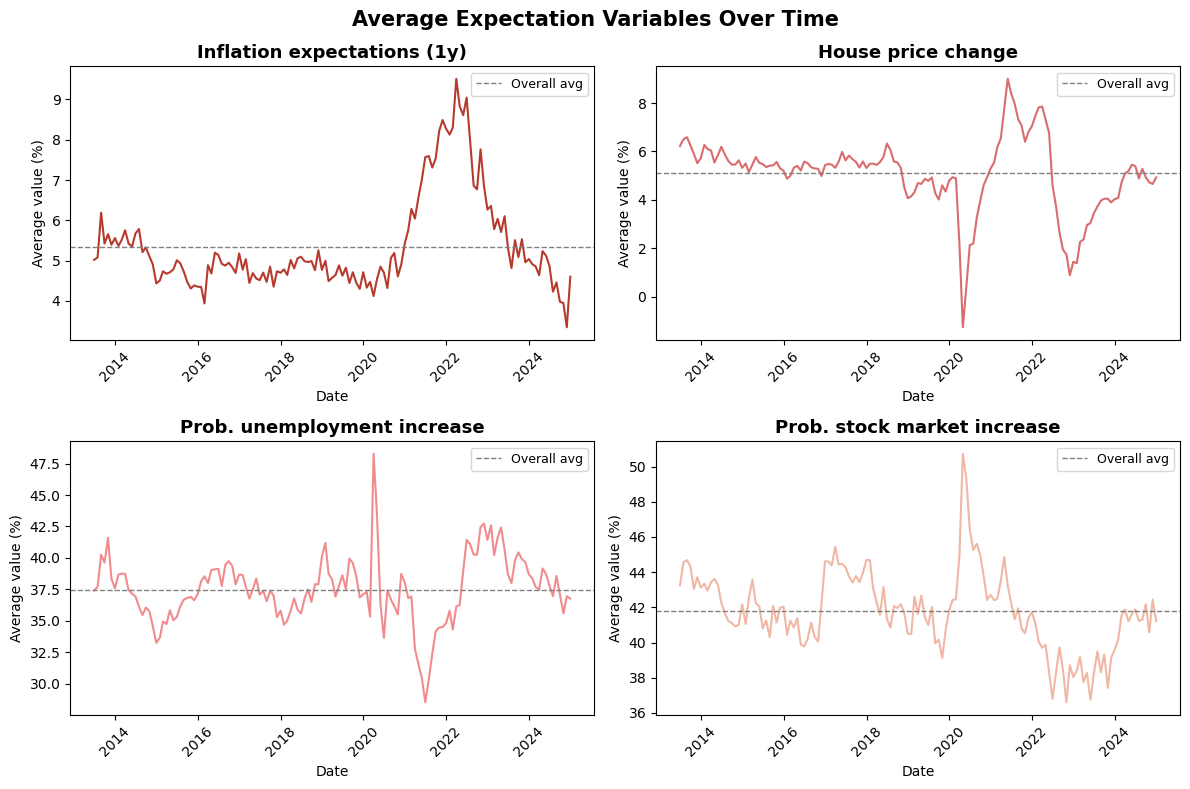

In [28]:
# Plot the time series of the average value over the survey period for the target variables
plot_time_series(sce, target_vars, target_labels, 'Average Expectation Variables Over Time', ncols=2)

**Inflation expectations** were relatively stable around 4–5% pre-covid, well above the Fed's 2% target. Expectations surged from 2021, peaking near 9–10% in mid-2022. The subsequent sharp decline might reflect the Fed repeatedly raising its interest rates over multiple consecutive meetings and the eventual cooling of inflation, with expectations falling back toward pre-pandemic levels by 2024.

**House price change expectations** were relatively stable around 4-6% pre-covid. The most striking feature is the sharp collapse in early 2020 reflecting COVID-19 shock, followed by a rapid rebound to above 8% in 2021–2022 as pandemic-era demand and supply constraints drove house prices to record highs. Expectations have since moderated as rising mortgage rates cooled the housing market.

**Probability of unemployment increase** shows more volatility over the period. The sharp spike in early 2020 reflects the COVID-19 labor market shock, when unemployment rose. The equally rapid decline mirrors the unprecedented speed of the labor market recovery. A secondary elevation in 2022–2023 likely reflects concerns about Fed-induced recession risk.

**Probability of stock market increase** trends gradually downward over the sample. The spice after 2016 might reflect the 2016 US presidential election of Trump. Another notable spike in mid-2020 as markets rebounded sharply from the COVID crash. The persistent decline after 2022 aligns with the bear market driven by rising interest rates eroding equity valuations.

Across all four variables, the COVID-19 period stands out as the dominant source of variation, reflecting how profoundly the pandemic disrupted household expectations about the macroeconomic outlook.

#### **Fraction of optimists over time**


In [29]:
# Define labels for optimism variables
opt_labels = ['Optimistic about unemployment', 'Optimistic about stocks', 'Optimistic about house prices']

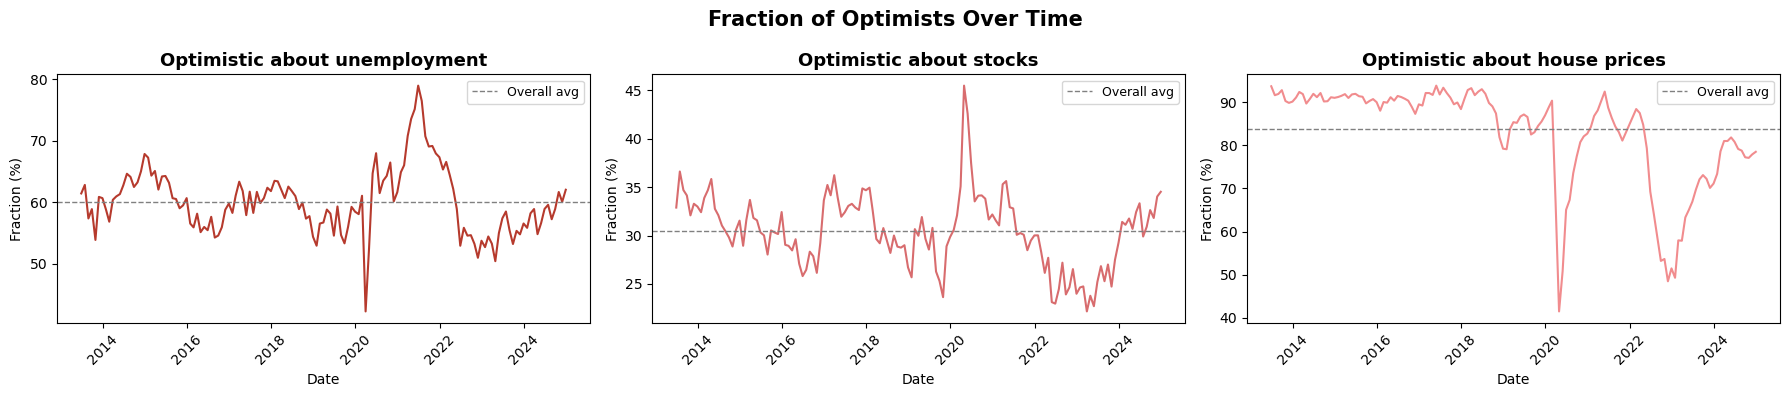

In [30]:
# Plot the time series of the fraction of optimists over the survey period for the optimism indicator variables
plot_time_series(sce, opt_vars, opt_labels, 'Fraction of Optimists Over Time', ncols=3, ylabel='Fraction (%)', scale=100, show_overall_avg=True)

The fraction of optimists over time mirrors the patterns seen in the continuous expectation variables, with the COVID-19 shock in 2020 being the dominant event across all three series.

**Optimistic about unemployment** averages around 60% over the sample, might reflecting that most households expect stable labor market conditions in normal times. The series drops sharply to below 40% in early 2020 as the pandemic caused unemployment to spike, before recovering as the labor market rebounded. A secondary decline in 2022–2023 might reflect concerns about a potential recession as the Fed raised rates to combat inflation.

**Optimistic about stocks** averages around 30%, meaning only about one in three respondents expect stock prices to rise at any given time, which might reflect the inherent uncertainty households attach to equity markets. The notable spike in mid-2020 captures the stock market recovery following the initial COVID crash. The 2016 election might have caused the visible uptick. 

**Optimistic about house prices** is consistently the highest of the three series, averaging above 80%, which can reflect a broadly held view that house prices tend to rise over time. The sharp collapse in early 2020 might again be COVID-driven, but the series recovered quickly as pandemic-era demand pushed house prices to record highs. The decline after 2022 aligns with the cooling housing market as mortgage rates rose.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 3**

 - **Structure and readability:** Part 3 is again well-structured and easy to read. Headers for subtasks and markdown files for explenations makes the code easy to follow.

 - **Functions:** `plot_time_series` is defined and reused throughout the notebook, avoiding reuse of code. To further improve readability and efficieny, the function could be split into multiple functions, but the function is sufficient as is.

***
# **Part 4 - Exploratory data analysis (macro/finance)**
***


### **4.1 - Time series of macro/finance variables in levels**

In [31]:
# Define labels for macro level variables
macro_labels = ['WTI Oil ($)', 'S&P 500 (points)', 'Consumer Price Index', 'House Price Index','Fed Funds Rate (%)', 'Unemployment Rate (%)', 'Real GDP ($)', 'USD Index', 
                '30Y Mortgage Rate (%)']

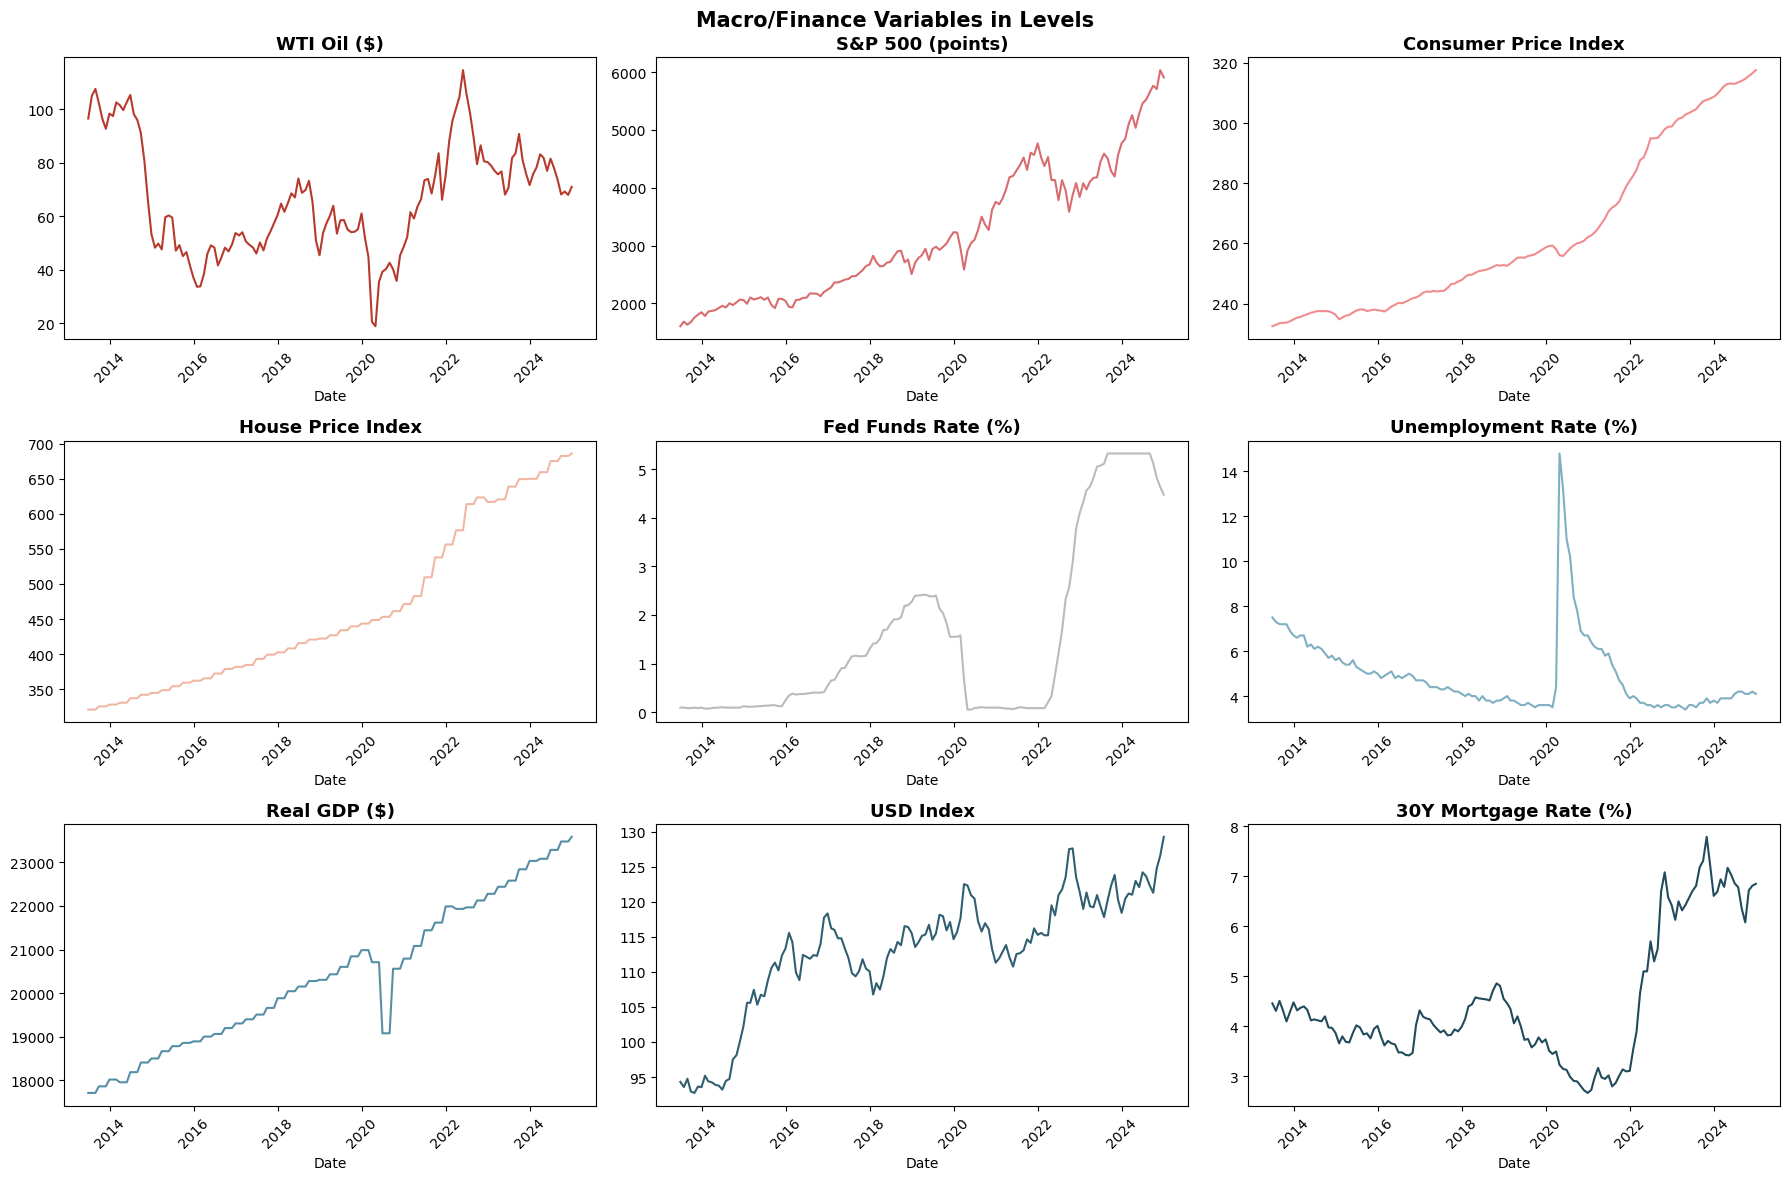

In [32]:
# Plot time series of macro/finance variables in levels
plot_time_series(macro_levels, macro_levels.columns.tolist(), macro_labels, 'Macro/Finance Variables in Levels', ncols=3, show_overall_avg=False, ylabel='')

**WTI Oil** shows high volatility throughout the sample, with two major collapses. The 2015–2016 supply glut that pushed prices below $30, and the COVID-19 demand shock in early 2020 where prices briefly fell near zero. Oil prices recovered strongly in 2021–2022 amid supply constraints and the Ukraine war.

**S&P 500** trended strongly upward over the sample, interrupted briefly by the COVID crash in early 2020 before resuming its upward trajectory to record highs by 2024.

**Consumer Price Index** grew steadily until 2021, when the slope steepened sharply, reflecting the post-pandemic inflation surge that peaked in mid-2022 before gradually moderating.

**House Price Index** rose persistently throughout the entire sample, with growth accelerating notably after 2020 as pandemic-era demand and low mortgage rates drove prices to record levels.

**Fed Funds Rate** was near zero from 2013 to 2015, then rose gradually before being cut back to zero in March 2020 in response to COVID-19. The rate then surged from near zero to above 5% in 2022–2023 as the Fed responded to elevated inflation.

**Unemployment Rate** declined steadily from around 7.5% in 2013 to a low of 3.5% in early 2020, before spiking dramatically to nearly 15% at the height of the COVID shock. The subsequent recovery was equally rapid, with unemployment returning to pre-pandemic lows by 2022.

**Real GDP** grew steadily over the sample, with the sharp COVID contraction in early 2020 followed by a swift recovery.

**USD Index** strengthened considerably over the sample, particularly after 2021, reflecting the dollar's safe-haven status and the interest rate differential as the Fed raised rates more aggressively than other central banks.

**30-Year Mortgage Rate** tracked the Fed Funds Rate closely, declining to the periods lowest at near 3% in 2020–2021 before rising sharply to above 7% by 2023 significantly affecting housing affordability.

### **4.2 - Time series of Macro/finance variables in differences**

In [33]:
# Define labels for macro difference variables
diff_labels = ['CPI YoY', 'S&P 500 YoY', 'Oil YoY', 'Dollar YoY','HPI YoY', 'GDP YoY', 'Mortgage Abs. Change (1m)']

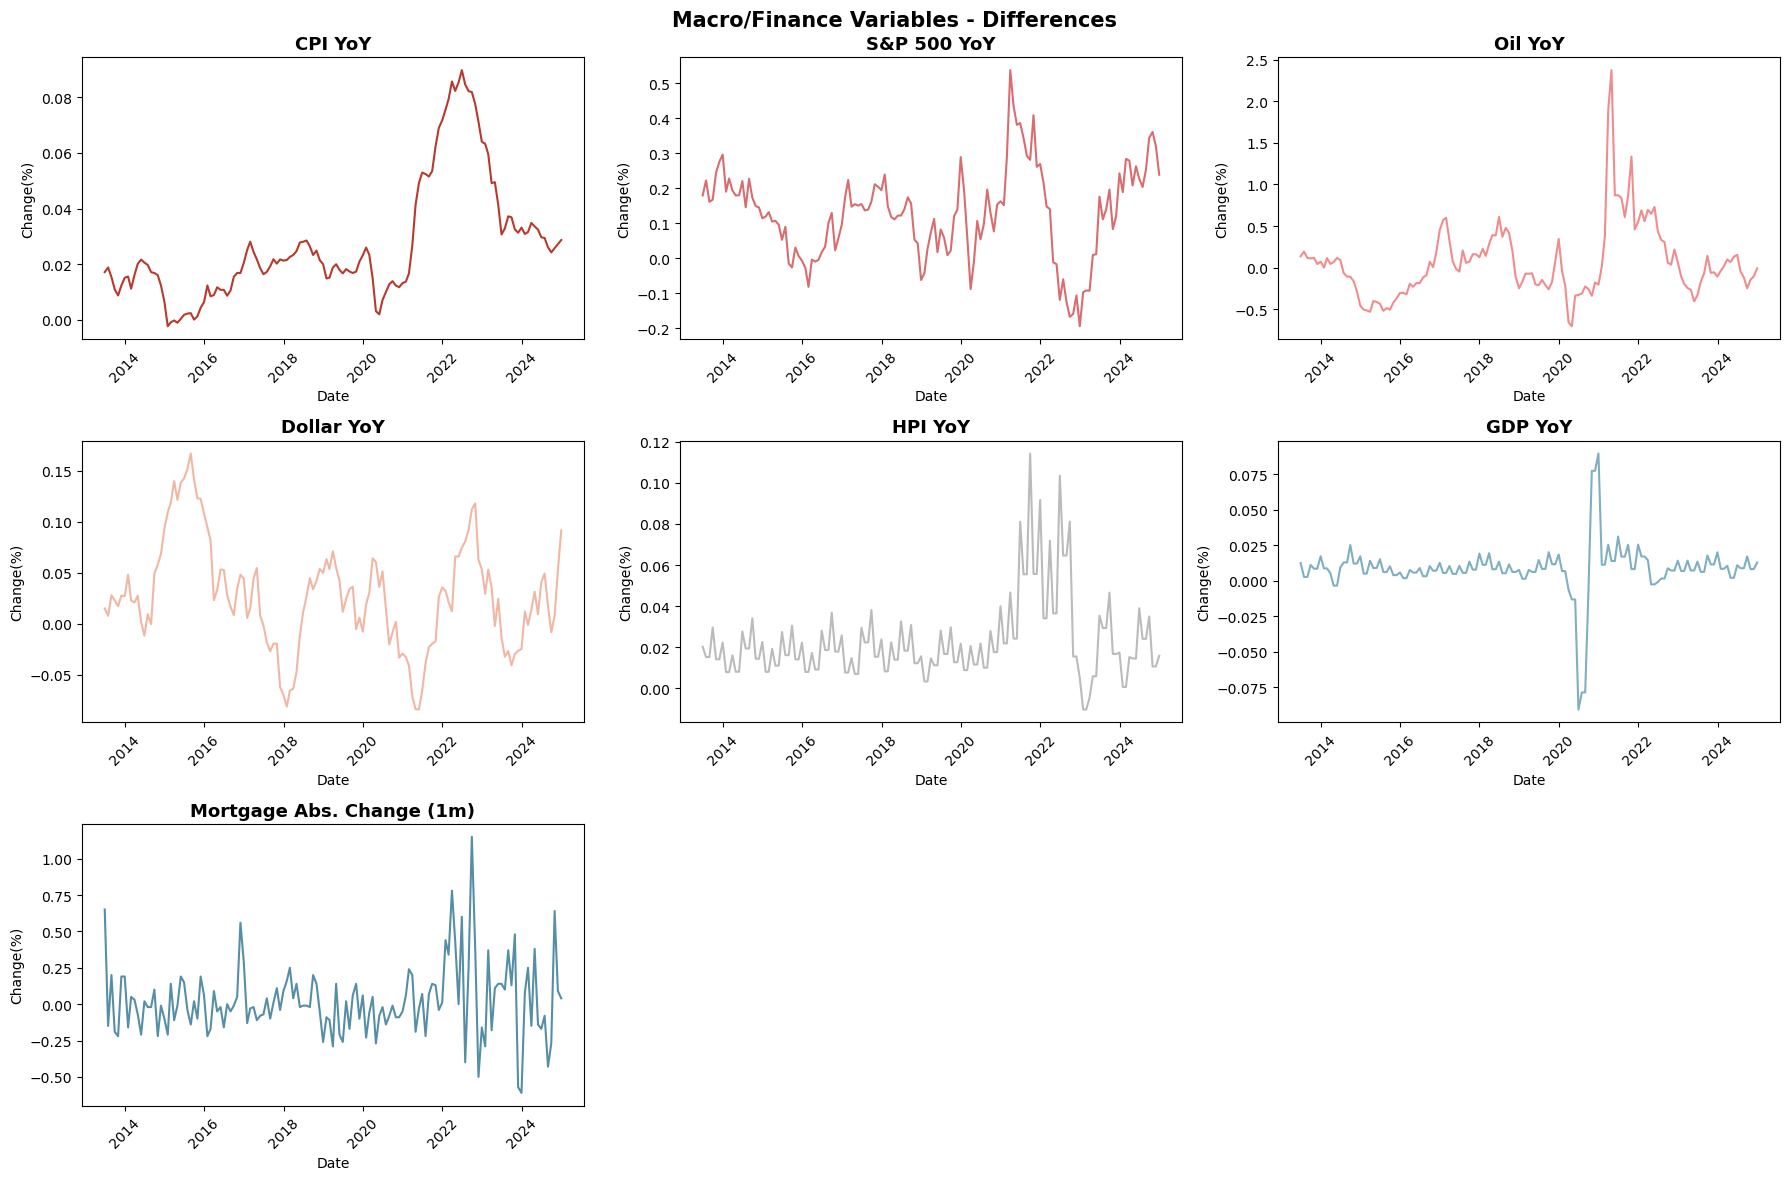

In [34]:
# Plot time series of macro/finance variables in differences
plot_time_series(macro_diffs, macro_diffs.columns.tolist(), diff_labels, 'Macro/Finance Variables - Differences', ncols=3, show_overall_avg=False, ylabel='Change(%)')

The differenced variables mostly reflect the same macroeconomic episodes visible in the levels, but remove persistent trends and make the *rate of change* more apparent. This is relevant for trending variables such as CPI, HPI, and GDP, where the level obscures whether conditions are improving or deteriorating. For volatile variables like oil and equities, the YoY changes also reveal base effects that are not visible in levels, most notably the extreme oil price swing in 2020–2021. The 1-month mortgage rate change captures how quickly borrowing costs shift from month to month, which is more directly relevant to household decision-making than the level of the rate itself.

#### **Correlation table**

In [35]:
# Function to plot correlation table between target variable and a list of feature variables
def plot_correlation_table(df, target, feature_vars, vmin=None, vmax=None):
    """
    Compute and display a correlation table between a target variable and a list of feature variables, sorted by correlation.

    Parameters
    ----------
    df:
        DataFrame containing both target and feature variables
    target:
        target variable name
    feature_vars:
        list of feature variable names to correlate with target
    vmin:
        minimum value for color gradient
    vmax:
        maximum value for color gradient
    """
    
    # Compute correlation of target with feature variables
    corr = df[feature_vars].corrwith(df[target])
    corr = corr.sort_values(ascending=False).to_frame(name='Correlation')

    # Print correlation table with color gradient
    print(f'\n{"=" * 60}\n Correlation of variables with: {target}\n{"=" * 60}')
    display(
        corr.round(3).style
        .format('{:.3f}')
        .background_gradient(cmap='coolwarm_r', vmin=vmin, vmax=vmax)
    )

In [36]:
# Compute global bounds across both macro and individual variables
all_vars = macro_all.columns.tolist() + individual_vars
all_corrs = pd.concat([
    sce[all_vars].corrwith(sce[target])
    for target in target_vars
])

# Set global vmin and vmax for consistent color scaling across all correlation tables
global_vmin = all_corrs.min()
global_vmax = all_corrs.max()

In [37]:
# Macro correlations
for target in target_vars:
    plot_correlation_table(sce, target, macro_all.columns.tolist(), vmin=global_vmin, vmax=global_vmax)


 Correlation of variables with: infl_1y


,Correlation
CPI_rel_12m,0.111
HPI_rel_4q,0.086
oil_rel_12m,0.085
oil_price,0.072
sp500,0.052
HPI,0.046
CPI,0.044
mortgage_abs_1m,0.043
GDP,0.041
GDP_rel_4q,0.016



 Correlation of variables with: house_price_change


,Correlation
sp500_rel_12m,0.134
oil_rel_12m,0.105
GDP_rel_4q,0.058
HPI_rel_4q,0.043
oil_price,0.039
mortgage_abs_1m,0.016
Unrate,0.002
CPI_rel_12m,-0.014
sp500,-0.021
GDP,-0.056



 Correlation of variables with: prob_unrate_up


,Correlation
Mortgage,0.054
FedFunds,0.044
dollar_rel_12m,0.033
Dollar,0.027
CPI,0.024
HPI,0.023
CPI_rel_12m,0.017
GDP,0.016
oil_price,0.014
mortgage_abs_1m,0.005



 Correlation of variables with: prob_stocks_up


,Correlation
Unrate,0.057
sp500_rel_12m,0.036
oil_rel_12m,0.000
mortgage_abs_1m,-0.015
dollar_rel_12m,-0.017
GDP_rel_4q,-0.021
HPI_rel_4q,-0.024
Dollar,-0.030
oil_price,-0.034
sp500,-0.037


Overall, the correlations are relatively weak as they all are below 0.15. This suggests that macroeconomic and financial variables alone have limited explanatory power for household expectations. This is not entirely surprising, as individual expectations are likely shaped by a combination of aggregate economic conditions and personal circumstances, such as income, employment status, and financial literacy. While variables like CPI growth and S&P 500 returns show the strongest correlations with inflation and house price expectations respectively, the low magnitudes suggest that households do not simply update their expectations in line with macroeconomic developments. For this reason, it would therefore be interesting to look further into whether individual-level characteristics are correlated with household expectations.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 4**

 - **Structure and readability:** The code is very well-structured, with correlation tables sorted in descending order to clearly display the output. Sorting using vmin and vmax to color scale the correlation tables further improves comparability across the different tables, improving readability. Interpretations in markdown cells provide explanations of the underlying economic theory, which seems to be in line with the given solution.

 - **Functions:** Both `plot_time_series` and `plot_correlation_table` are reused throughout the code, avoiding duplication.

***
# **Part 5 - Predicting continuous expectation variables**
***

### **5.1 - Split data into training set**

In [38]:
# Split into train and test based on date
train = sce[sce['date'] < '2024-01-01'].copy()
test  = sce[sce['date'] >= '2024-01-01'].copy()

# Print summary of train/test split
tbl = pd.DataFrame({
    'Observations': [f'{len(train):,}', f'{len(test):,}']
}, index=['Train', 'Test'])
tbl.index.name = 'Set'

print(f"\n{'=' * 55}")
print(f"  Train/test split summary:")
print(f"{'=' * 55}")
display(tbl)


  Train/test split summary:


,Observations
Set,
Train,"142,861"
Test,"11,340"


### **5.2 - Series of modeles to the training data**

In [39]:
# Categorical variables requiring OneHotEncoding
cat_vars = ['educ']

# Target arrays 
y_train = train[target_vars].to_numpy() # Convert train target variables to numpy array for modeling
y_test  = test[target_vars].to_numpy()  # Convert test target variables to numpy array for modeling

# Dictionary to collect results for summary table
results = {}

# Hyperparameter grids for regression models
ridge_alphas    = np.logspace(-5, 5, 50)              # Alpha grid for Ridge: covers very weak to very strong regularization
other_alphas    = np.logspace(-6, 2, 50)              # Alpha grid for lasso and elastic net: covers very weak to very strong regularization
L1_ratios = [0.1, 0.5, 0.7, 0.9, 0.95, 1.0]           # L1 ratio grid for Elastic Net
max_depths   = np.arange(1, 21)                       # Max-depth grid for Decision Tree
kf = KFold(n_splits=10, shuffle=True, random_state=1234) # KFold cross-validator for plotting validation curves (not LOO, which is too slow)

# Feat_names
feat_name_macro = 'Macro only'
feat_name_macro_indiv = 'Macro + Individual'

#### **Set up helper functions**

In [40]:
# Define a data class to hold model information and stack predictions
@dataclass
class MultiOutputModel:
    """
    Holds one fitted model per target and stacks their predictions into a single (n_samples, n_targets) array
    """
    
    # List of fitted models, one for each target variable
    models: list

    # Predict method to generate predictions for all models and stack them into a single array
    def predict(self, X):
        """
        Parameters
        ----------
        X : 
            numpy array or list of numpy arrays
        """

        # Stack predictions from each model into a single array
        Xs = X if isinstance(X, list) else [X] * len(self.models)
        return np.column_stack([m.predict(Xi) for m, Xi in zip(self.models, Xs)])

In [41]:
# Function to prepare features for modeling, including standardization and one-hot encoding
def prepare_features(features, train=train, test=test, cat_vars=cat_vars, vars_list=None):
    """""
    Prepare features for modeling by standardizing numeric features and one-hot encoding categorical features.
    
    Parameters
    ----------
    features:
        list of feature variable names or dictionary of the target list of feature variable names
    train: 
        training DataFrame used to fit scalers/encoders
    test:
        test DataFrame used to transform features
    cat_vars:
        list of categorical variable names to one-hot encode
    vars_list:
        optional list of target variable names to use when features is a dictionary 
    
    Returns
    -------
    X_train: 
        numpy array of prepared features for training
    X_test:
        numpy array of prepared features for testing
    """

    # If condition to prepare features separately for each target variable and return a list of arrays
    if isinstance(features, dict):
        keys = vars_list if vars_list is not None else target_vars
        return [prepare_features(features[t], train, test, cat_vars) for t in keys]

    # Separate numeric and categorical features
    other = [f for f in features if f not in cat_vars]
    cat   = [f for f in features if f in cat_vars]

    # Standardize numeric features fit on train only
    scaler      = StandardScaler()
    X_train_num = scaler.fit_transform(train[other].to_numpy())
    X_test_num  = scaler.transform(test[other].to_numpy())

    # One-hot encode categorical features fit on train only
    if cat:
        enc         = OneHotEncoder(drop='first', sparse_output=False)
        X_train_cat = enc.fit_transform(train[cat])
        X_test_cat  = enc.transform(test[cat])
        X_train     = np.hstack([X_train_num, X_train_cat])
        X_test      = np.hstack([X_test_num,  X_test_cat])
    else:
        X_train, X_test = X_train_num, X_test_num

    return X_train, X_test

In [42]:
def evaluate_model(model, X_test, y_test, label):
    """
    Print and store RMSE and R² on the test set for each target variable.
    Parameters
    ----------
    model : 
        fitted model with a predict method
    X_test : 
        numpy array or list of numpy arrays
    y_test : 
        numpy array of true target values for the test set
    label : 
        Label for this model in the results dictionary.
    """
        
    # Generate predictions using the model's predict method
    y_pred = model.predict(X_test)

    # Store results in the results dictionary for summary table
    results[label] = {}
    rows = []
    
    # Loop through each target variable, calculate RMSE and R², store in results dictionary
    for name, tgt_label, yt, yp in zip(target_vars, target_labels, y_test.T, y_pred.T):
        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)
        results[label][name] = (rmse, r2)
        rows.append({'Target': tgt_label, 'RMSE': round(rmse, 4), 'R²': round(r2, 4)}) 

    # Create a summary table from the results and display it
    tbl = pd.DataFrame(rows).set_index('Target').round(3)
    print(f"\n{'=' * 55}")
    print(f"  {label} — Test Set Performance")
    print(f"{'=' * 55}")
    display(tbl)

In [43]:
def plot_predictions(model, X_train, X_test, feat_name, model_name):
    """
    Plot monthly-average actual vs. predicted values for all four target variables.

    Parameters
    ----------
    model: 
        fitted model with a predict method
    X_train: 
        numpy array or list of numpy arrays one per target
    X_test: 
        numpy array or list of numpy arrays one per target
    feat_name: 
        Feature set label used in the plot title
    model_name: 
        Model name used in the plot title
    """

    # Generate predictions for both train and test sets using the model's predict method   
    pred_train = model.predict(X_train)
    pred_test  = model.predict(X_test)

    # Create subplots for each target variable
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()
    split_date = pd.Timestamp('2024-01-01')

    # Plot actual vs. predicted values for each target variable, with a vertical line indicating the train/test split
    for i, (var, label) in enumerate(zip(target_vars, target_labels)):
        ax = axes[i]

        # Monthly actual
        actual = sce.groupby(sce['date'].dt.to_period('M'))[var].mean()
        actual.index = actual.index.to_timestamp()

        # Monthly predicted
        combined = pd.concat([
            train[['date']].assign(pred=pred_train[:, i]),
            test[['date']].assign(pred=pred_test[:, i]),
        ])

        # Calculate monthly average predicted values by grouping by month and taking the mean
        predicted = combined.groupby(combined['date'].dt.to_period('M'))['pred'].mean()
        predicted.index = predicted.index.to_timestamp()

        # Plot actual and predicted values with a vertical line for the train/test split
        ax.plot(actual.index,    actual.values,    color=colors[8], linewidth=1.5, label='Actual')
        ax.plot(predicted.index, predicted.values, color=colors[2], linewidth=1.5, label='Predicted')
        ax.axvline(split_date, color='black', linestyle=':', linewidth=1.2, label='Train/Test split')
        ax.set_title(label, fontsize=12, fontweight='bold')  # Fixed
        ax.set_xlabel('Date')
        ax.set_ylabel('Average value (%)')
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=9)

    fig.suptitle(f'{model_name} ({feat_name}) — Actual vs. Predicted',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [44]:
def plot_validation_curve(alphas, cv_mse_list, feat_name, model_name, extra_params=None, x_label=None, log_scale=True, hyper_label='Best α'):
    """
    Parameters
    ----------
    alphas:
        list or array of hyperparameter values 
    cv_mse_list:
        list of arrays of cross-validated MSE values for each target variable, corresponding to the hyperparameter values in alphas
    feat_name:
        Feature set label used in the plot title
    model_name:
        Model name used in the plot title
    extra_params:
        Optional dictionary of additional hyperparameters to display in the summary table
    x_label:
        Label for the x-axis 
    log_scale:
        Whether to use logarithmic scale for the x-axis 
    hyper_label:
        Label for the best hyperparameter value in the summary table 
    """

    # Set default x-axis label if not provided
    x_label = x_label or r'Regularization strength $\alpha$ (log scale)'

    # Create subplots for each target variable and plot the cross-validated MSE against the hyperparameter values
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    # Loop through each target variable, plot the validation curve, and annotate the best hyperparameter value with a vertical line and text annotation
    for i, (name, label, mse_mean) in enumerate(zip(target_vars, target_labels, cv_mse_list)):
        ax = axes[i]
        imin = np.argmin(mse_mean)
        ax.plot(alphas, mse_mean, color=colors[i], linewidth=1.5)
        ax.scatter(alphas[imin], mse_mean[imin], s=30, c='black', zorder=100)
        ax.axvline(alphas[imin], ls=':', lw=0.75, c='black')
        ax.annotate(f'{hyper_label} = {alphas[imin]:.4g}',
                    xy=(alphas[imin], mse_mean[imin]),
                    xytext=(0.97, 0.95), textcoords='axes fraction',
                    ha='right', va='top', fontsize=9,
                    bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))
        ax.set_xlabel(x_label)
        ax.set_ylabel('Cross-validated MSE')
        ax.set_title(label, fontweight='bold')
        if log_scale:
            ax.set_xscale('log')
        ax.set_yscale('linear')
        ax.autoscale(axis='y')

    # Adjust layout and print plot
    fig.suptitle(f'{model_name} Validation Curves ({feat_name})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Build and display styled summary table
    rows = []
    for name, label, mse_mean in zip(target_vars, target_labels, cv_mse_list):
        imin = np.argmin(mse_mean)
        row = {'Target': label, hyper_label: f'{alphas[imin]:.4g}'}
        if extra_params and name in extra_params:
            row.update(extra_params[name])
        row['CV MSE'] = round(float(mse_mean[imin]), 4)
        rows.append(row)

    tbl = pd.DataFrame(rows).set_index('Target')
    print(f"\n{'=' * 55}")
    print(f"  {model_name} ({feat_name}) — Validation Summary")
    print(f"{'=' * 55}")
    display(tbl)

In [45]:
# Function to run the full regression pipeline for one model and one feature set
def run_regression_experiment(model_name, train_fn, feat_name, features):
    """
    Run the full regression pipeline for one model and one feature set: prepare features -> fit via train_fn -> evaluate -> plot predictions.

    Parameters
    ----------
    model_name : 
        Display name for the model 
    train_fn : 
        Function that takes X_train, y_train, feat_name and returns a fitted model
    feat_name : 
        Display name for the feature set
    features : 
        List of feature variable names or dictionary of the target list of feature variable names to prepare
    """
    
    # Prepare features 
    xy = prepare_features(features)

    # Handle case where prepare_features returns a list of arrays vs. a single array used for all targets
    if isinstance(xy, list):
        X_train_input = [pair[0] for pair in xy]
        X_test_input  = [pair[1] for pair in xy]
    else:
        X_train_input, X_test_input = xy

    # Fit the model using the caller-supplied training function
    model = train_fn(X_train_input, y_train, feat_name)

    # Evaluate on test set and plot predictions
    evaluate_model(model, X_test_input, y_test, f'{model_name} ({feat_name})')
    plot_predictions(model, X_train_input, X_test_input, feat_name, model_name)

#### **Helper functions for regressions**

In [46]:
# Train a Linear Regression model
def train_linear(X_train, y_train, feat_name=None):
    """
    Parameters
    ----------
    X_train:
        numpy array or list of numpy arrays of training features
    y_train:
        numpy array of shape of training target variables
    feat_name:
        optional feature set name for display purposes 
    
    Returns
    -------
    model:
        Fitted Linear Regression model or MultiOutputModel if X_train is a list of arrays
    """
    
    # Fit one model per target if X_train is a list, else fit a single model
    if isinstance(X_train, list):
        models = [LinearRegression().fit(X, y_train[:, j])
                  for j, X in enumerate(X_train)]
        return MultiOutputModel(models)
    return LinearRegression().fit(X_train, y_train)

In [47]:
# Ridge Regression with cross-validated alpha selection and validation curve plotting
def train_ridge(X_train, y_train, feat_name):
    """
    Parameters
    ----------
    X_train: 
        numpy array or list of numpy arrays of training features
    y_train: 
        numpy array of shape of training target variables
    feat_name: 
        feature set name for display purposes

    Returns
    -------
    model:
        Fitted Ridge Regression model with the best alpha for each target variable, wrapped in a MultiOutputModel 
    """
    
    # Fit one RidgeCV model per target variable
    X_list = X_train if isinstance(X_train, list) else [X_train] * len(target_vars)

    # Fit RidgeCV to select the best alpha for each target variable
    models = [RidgeCV(alphas=ridge_alphas, cv=kf).fit(X, y_train[:, j])
              for j, X in enumerate(X_list)]

    # Calculate cross-validated MSE for each alpha and target variable 
    cv_mse_list = [
        np.array([
            -cross_val_score(Ridge(alpha=a), X_list[j], y_train[:, j],
                             cv=kf, scoring='neg_mean_squared_error', n_jobs=-1).mean()
            for a in ridge_alphas
        ])
        for j in range(len(target_vars))
    ]

    # Plot validation curves for Ridge Regression and print best alpha values in a summary table
    plot_validation_curve(ridge_alphas, cv_mse_list, feat_name, 'Ridge')
    return MultiOutputModel(models)

In [48]:
# Train a Lasso Regression model with cross-validated alpha selection and validation curve plotting
def train_lasso(X_train, y_train, feat_name):
    """
    Parameters
    ----------
    X_train: 
        numpy array or list of numpy arrays of training features
    y_train: 
        numpy array of shape of training target variables
    feat_name: 
        feature set name for display purposes
    
    Returns
    -------
    model:
        Fitted LassoCV model with the best alpha for each target variable, wrapped in a MultiOutputModel
    """
    
    # Fit one LassoCV model per target variable and calculate cross-validated MSE for each alpha and target variable
    if isinstance(X_train, list):
        X_list = X_train
    else:
        X_list = [X_train] * len(target_vars)

    # List to hold fitted LassoCV models and their corresponding cross-validated 
    lasso_models = []
    cv_mse_list  = []
    
    # Fit LassoCV to select the best alpha for each target variable and calculate cross-validated MSE for each alpha
    for j, X in enumerate(X_list):
        lasso = LassoCV(alphas=other_alphas, cv=kf,
                        selection='random', max_iter=10000, n_jobs=-1)
        lasso.fit(X, y_train[:, j])
        lasso_models.append(lasso)
        cv_mse_list.append(lasso.mse_path_.mean(axis=1))

    # Plot validation curves for Lasso Regression and print best alpha values in a summary table
    plot_validation_curve(lasso_models[0].alphas_, cv_mse_list, feat_name, 'Lasso')
    return MultiOutputModel(lasso_models)

In [49]:
# Train a Decision Tree Regressor with cross-validated max_depth selection and validation curve plotting
def train_tree(X_train, y_train, feat_name):
    """
    Parameters
    ----------
    X_train: 
        numpy array or list of numpy arrays of training features
    y_train: 
        numpy array of shape (n_samples, n_targets) of training target variables
    feat_name: 
        feature set name for display purposes
    
    Returns
    -------
    model:
        Fitted DecisionTreeRegressor model with the best max_depth for each target variable, wrapped in a MultiOutputModel
    
    """
        
    # Fit one DecisionTreeRegressor per target variable for each value of max_depth and calculate cross-validated MSE for each max_depth and target variable
    X_list = X_train if isinstance(X_train, list) else [X_train] * len(target_vars)

    # List to hold cross-validated MSE for each max_depth and target variable
    cv_mse_list = [
        np.array([
            -cross_val_score(
                DecisionTreeRegressor(max_depth=d, random_state=1234),
                X_list[j], y_train[:, j],
                cv=kf, scoring='neg_mean_squared_error', n_jobs=-1
            ).mean()
            for d in max_depths
        ])
        for j in range(len(target_vars))
    ]

    # Select the best max_depth for each target variable based on the minimum cross-validated MSE
    best_depths = [max_depths[np.argmin(cv_mse)] for cv_mse in cv_mse_list]

    # Plot validation curves for Decision Tree Regressor and print best max_depth values in a summary table
    plot_validation_curve(
        max_depths, cv_mse_list, feat_name, 'Decision Tree',
        x_label='Max depth', log_scale=False, hyper_label='Best depth'
    )

    # Fit a DecisionTreeRegressor with the best max_depth for each target variable and return a MultiOutputModel
    models = [
        DecisionTreeRegressor(max_depth=d, random_state=1234).fit(X_list[j], y_train[:, j])
        for j, d in enumerate(best_depths)
    ]

    return MultiOutputModel(models)

In [50]:
# Train an Elastic Net Regression model with cross-validated alpha and l1_ratio selection and validation curve plotting
def train_elasticnet(X_train, y_train, feat_name):
    """
    Parameters
    ----------
    X_train: 
        numpy array or list of numpy arrays of training features
    y_train: 
        numpy array of shape (n_samples, n_targets) of training target variables
    feat_name: 
        feature set name for display purposes
    
    Returns
    -------
    model:
        Fitted ElasticNetCV model with the best alpha and l1_ratio for each target variable, wrapped in a MultiOutputModel
    
    """
    
    # Fit one ElasticNetCV model per target variable for each combination of alpha and l1_ratio, and calculate cross-validated MSE for each combination and target variable
    X_list = X_train if isinstance(X_train, list) else [X_train] * len(target_vars)

    # Lists to hold fitted ElasticNetCV models and their corresponding cross-validated MSE for the best alpha and l1_ratio
    enet_models = []
    cv_mse_list = []
    for j, X in enumerate(X_list):
        enet = ElasticNetCV(
            alphas=other_alphas, l1_ratio=L1_ratios,
            cv=kf, selection='random', max_iter=10000, n_jobs=-1
        )
        enet.fit(X, y_train[:, j])
        enet_models.append(enet)
        best_l1_idx = list(enet.l1_ratio).index(enet.l1_ratio_)
        cv_mse_list.append(enet.mse_path_[best_l1_idx, :, :].mean(axis=1))

    # Plot validation curves for Elastic Net Regression and print best alpha and l1_ratio values in a summary table
    extra_params = {
        name: {'L1_ratio': f"{m.l1_ratio_:.4g}"}
        for name, m in zip(target_vars, enet_models)
    }

    #  Plot validation curves for Elastic Net Regression and print best alpha and l1_ratio values in a summary table
    plot_validation_curve(
        enet_models[0].alphas_, cv_mse_list, feat_name, 'Elastic Net',
        extra_params=extra_params
    )

    return MultiOutputModel(enet_models)

### **Regression with macro variables**

##### **Linear Regression**


  Linear Regression (Macro only) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),9.099,-0.015
House price change,8.045,-0.005
Prob. unemployment increase,22.308,-0.008
Prob. stock market increase,22.510,-0.015


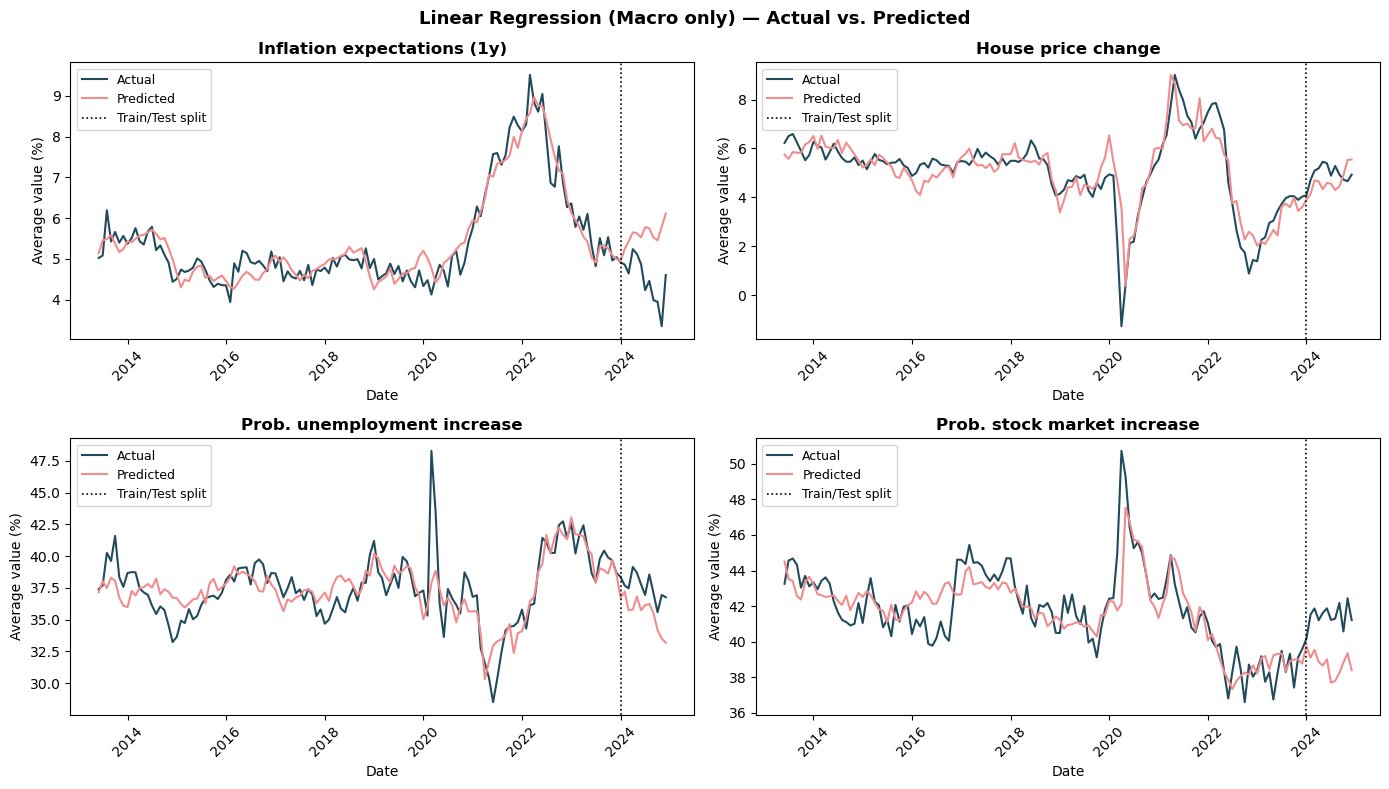

In [51]:
# Linear regression with only macro features
run_regression_experiment('Linear Regression', train_linear, feat_name_macro, macro_features)

##### **Ridge Regression** 

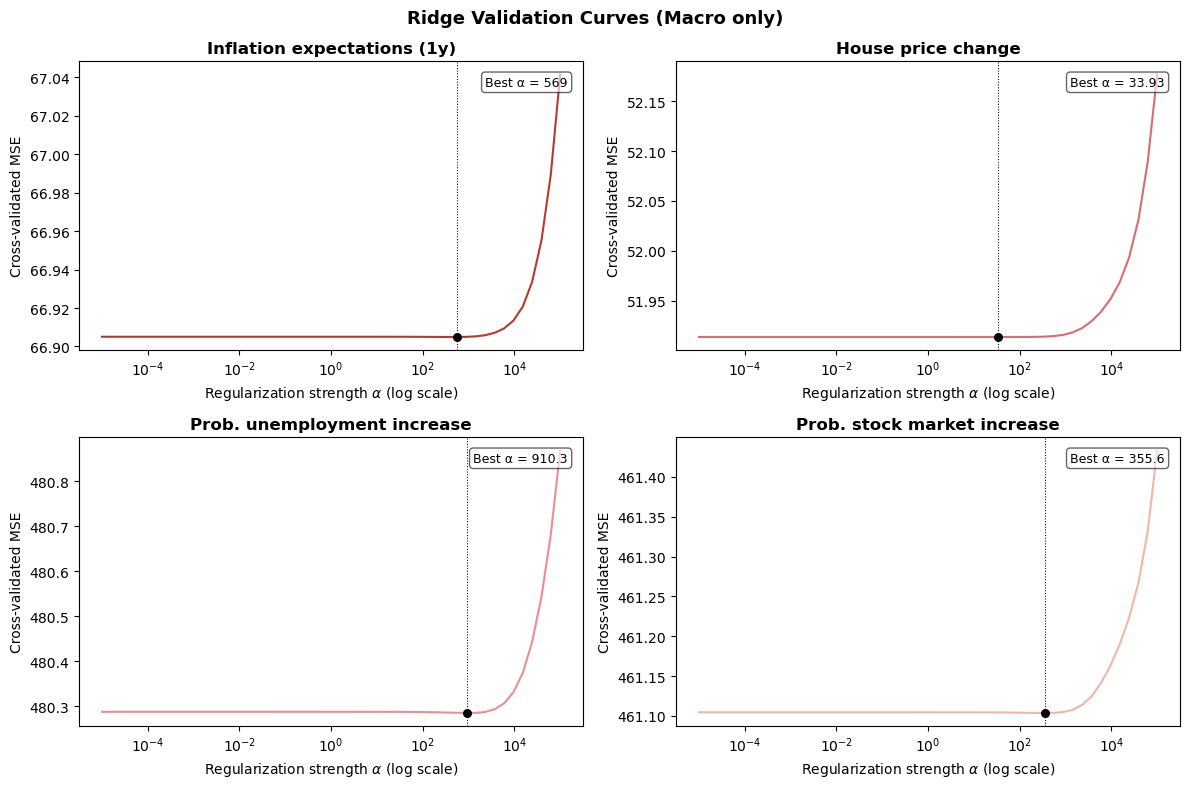


  Ridge (Macro only) — Validation Summary


,Best α,CV MSE
Target,,
Inflation expectations (1y),569,66.9049
House price change,33.93,51.9135
Prob. unemployment increase,910.3,480.2853
Prob. stock market increase,355.6,461.1036



  Ridge (Macro only) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),9.097,-0.014
House price change,8.045,-0.005
Prob. unemployment increase,22.295,-0.007
Prob. stock market increase,22.504,-0.014


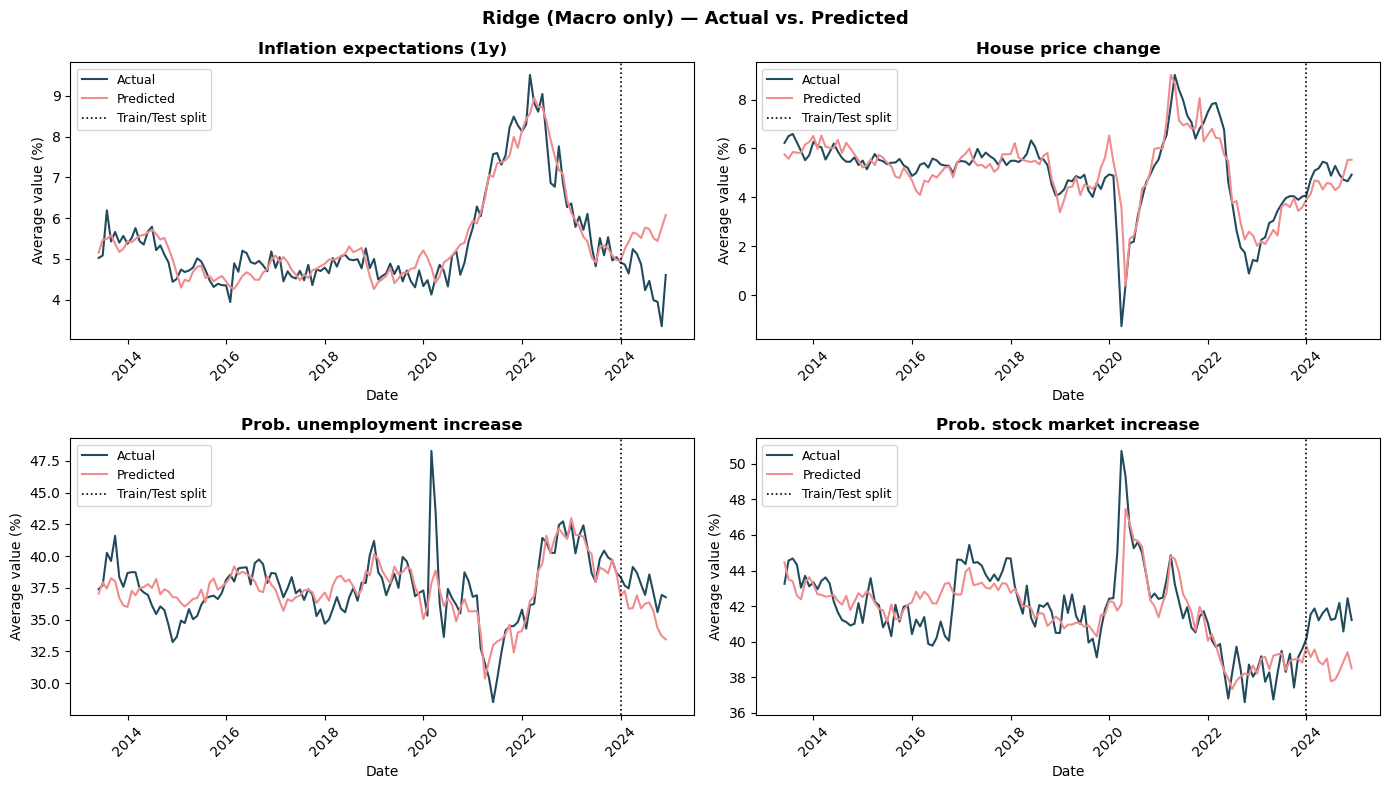

In [52]:
# Ridge regression with only macro features
run_regression_experiment('Ridge', train_ridge, feat_name_macro, macro_features)

##### **Lasso Regression**

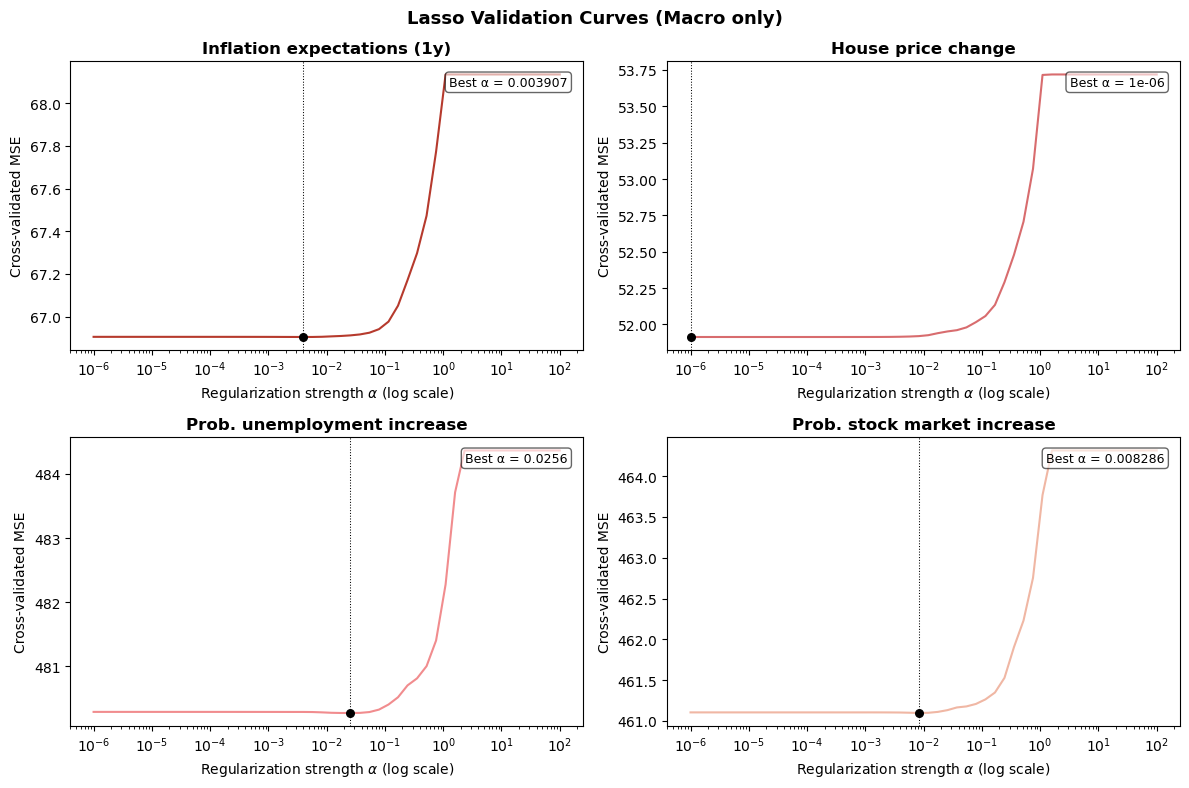


  Lasso (Macro only) — Validation Summary


,Best α,CV MSE
Target,,
Inflation expectations (1y),0.003907,66.9043
House price change,1e-06,51.9135
Prob. unemployment increase,0.0256,480.2707
Prob. stock market increase,0.008286,461.0970



  Lasso (Macro only) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),9.096,-0.014
House price change,8.045,-0.005
Prob. unemployment increase,22.264,-0.004
Prob. stock market increase,22.484,-0.013


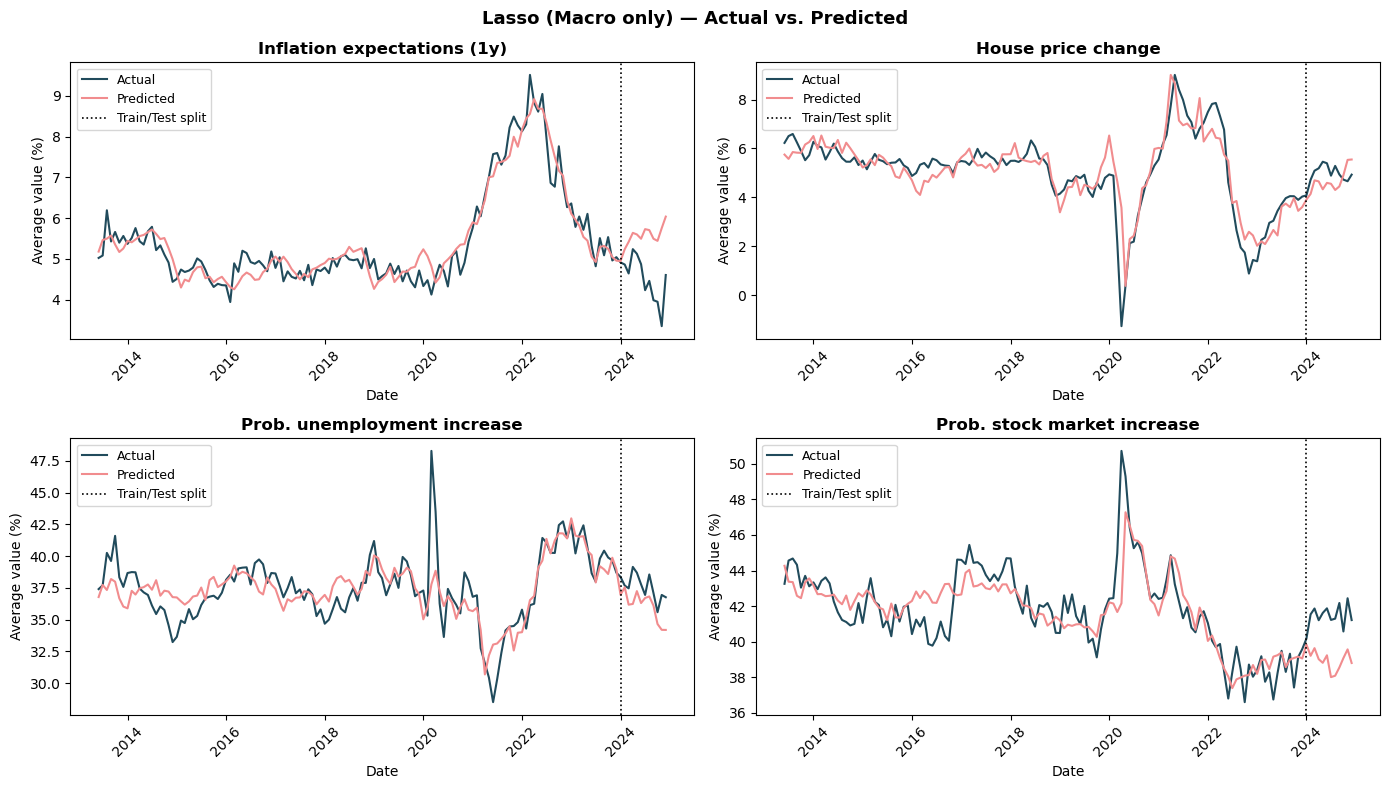

In [53]:
# Lasso regression with only macro features
run_regression_experiment('Lasso', train_lasso, feat_name_macro, macro_features)

##### **Desision Tree Regression** 

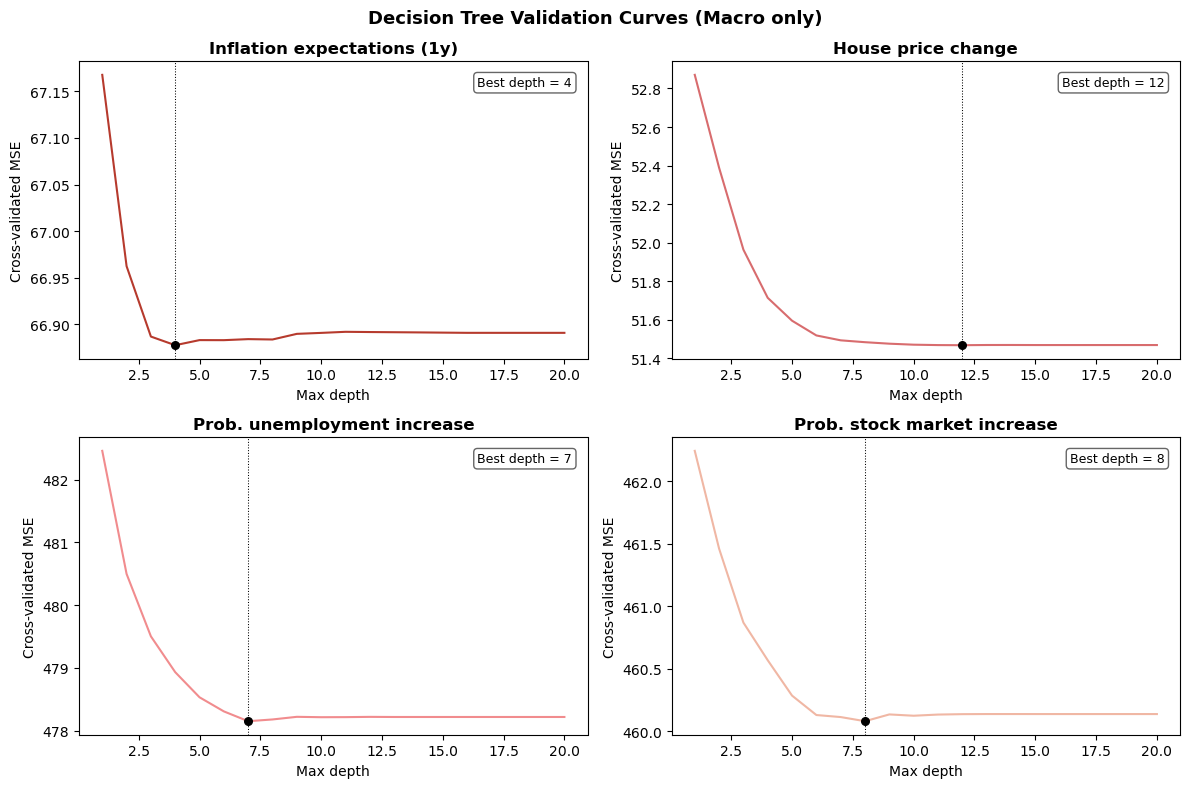


  Decision Tree (Macro only) — Validation Summary


,Best depth,CV MSE
Target,,
Inflation expectations (1y),4,66.8776
House price change,12,51.4681
Prob. unemployment increase,7,478.1505
Prob. stock market increase,8,460.0809



  Decision Tree (Macro only) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),9.045,-0.003
House price change,8.078,-0.013
Prob. unemployment increase,22.532,-0.028
Prob. stock market increase,22.444,-0.009


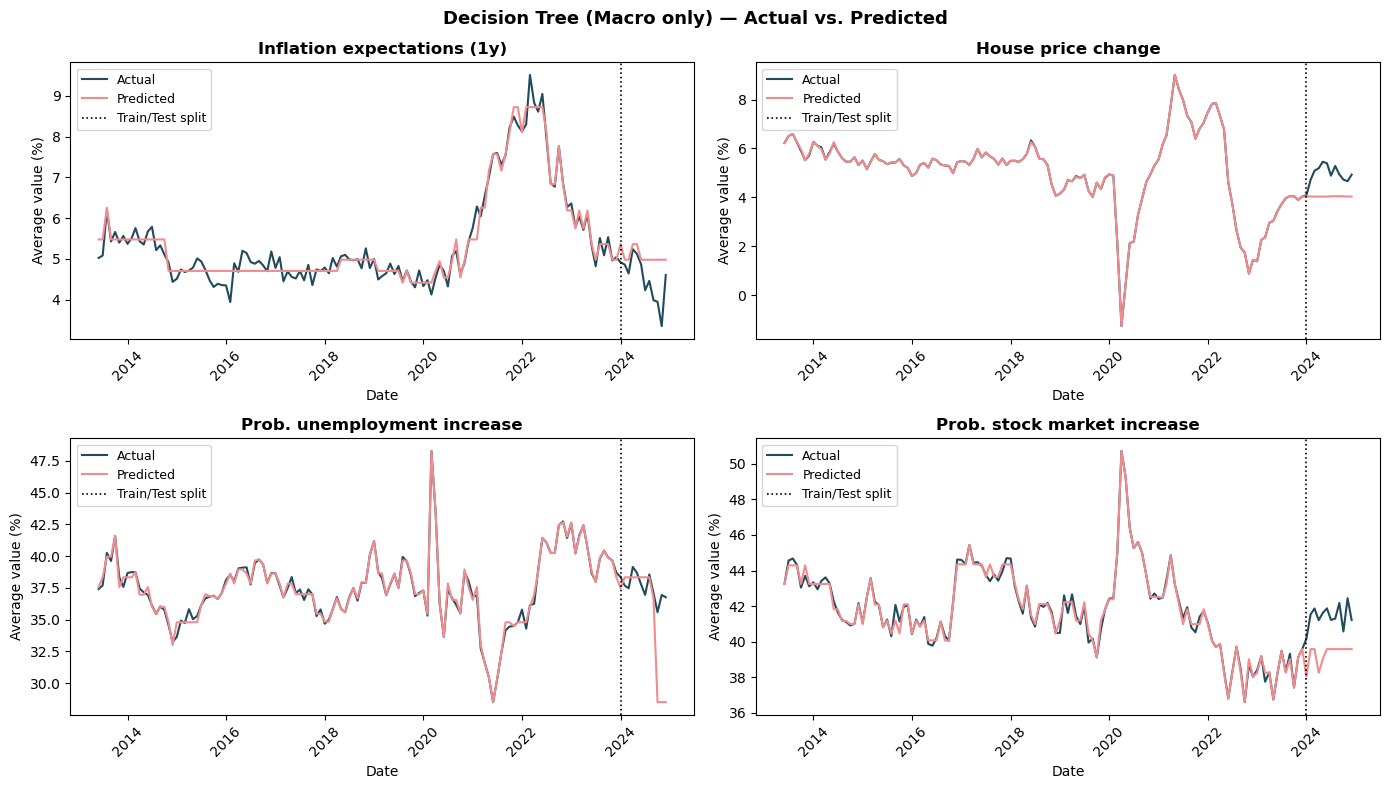

In [54]:
# Decision Tree regression with only macro features
run_regression_experiment('Decision Tree', train_tree, feat_name_macro, macro_features)

##### **ElasticNet Regression**

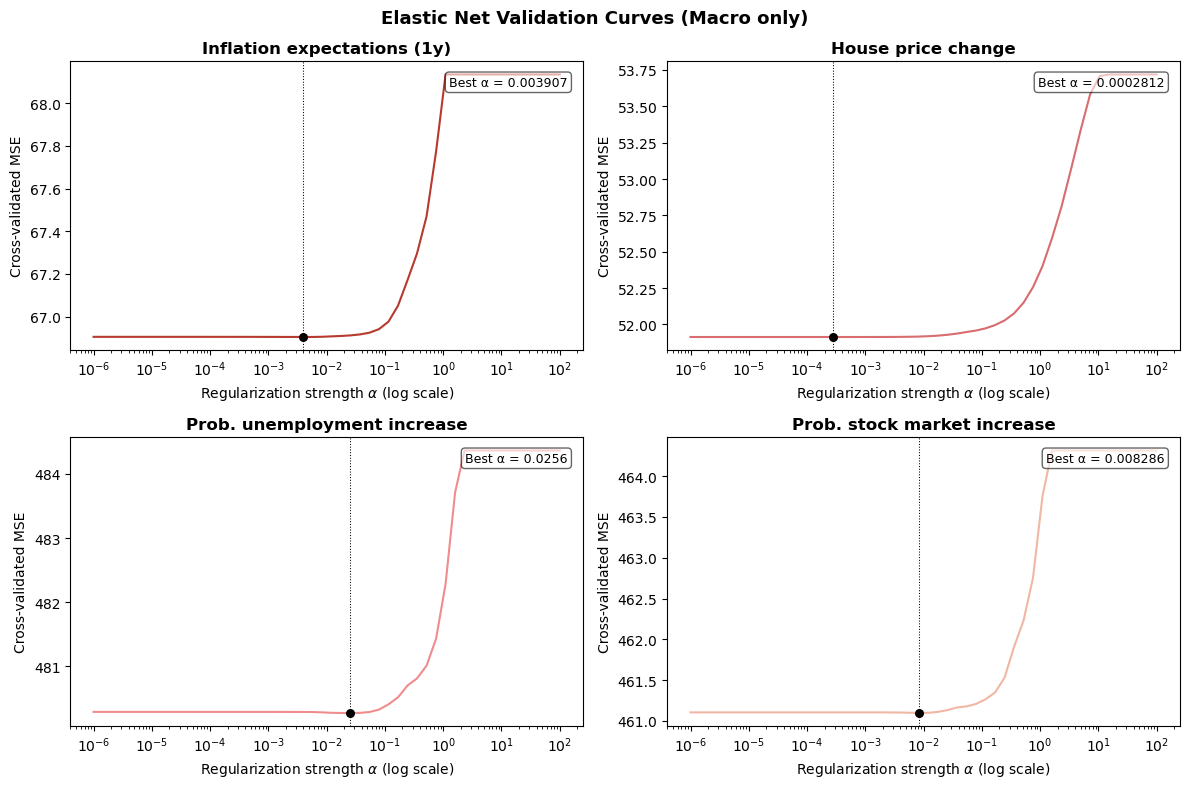


  Elastic Net (Macro only) — Validation Summary


,Best α,L1_ratio,CV MSE
Target,,,
Inflation expectations (1y),0.003907,1,66.9043
House price change,0.0002812,0.1,51.9135
Prob. unemployment increase,0.0256,1,480.2707
Prob. stock market increase,0.008286,1,461.0971



  Elastic Net (Macro only) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),9.095,-0.014
House price change,8.045,-0.005
Prob. unemployment increase,22.264,-0.004
Prob. stock market increase,22.484,-0.013


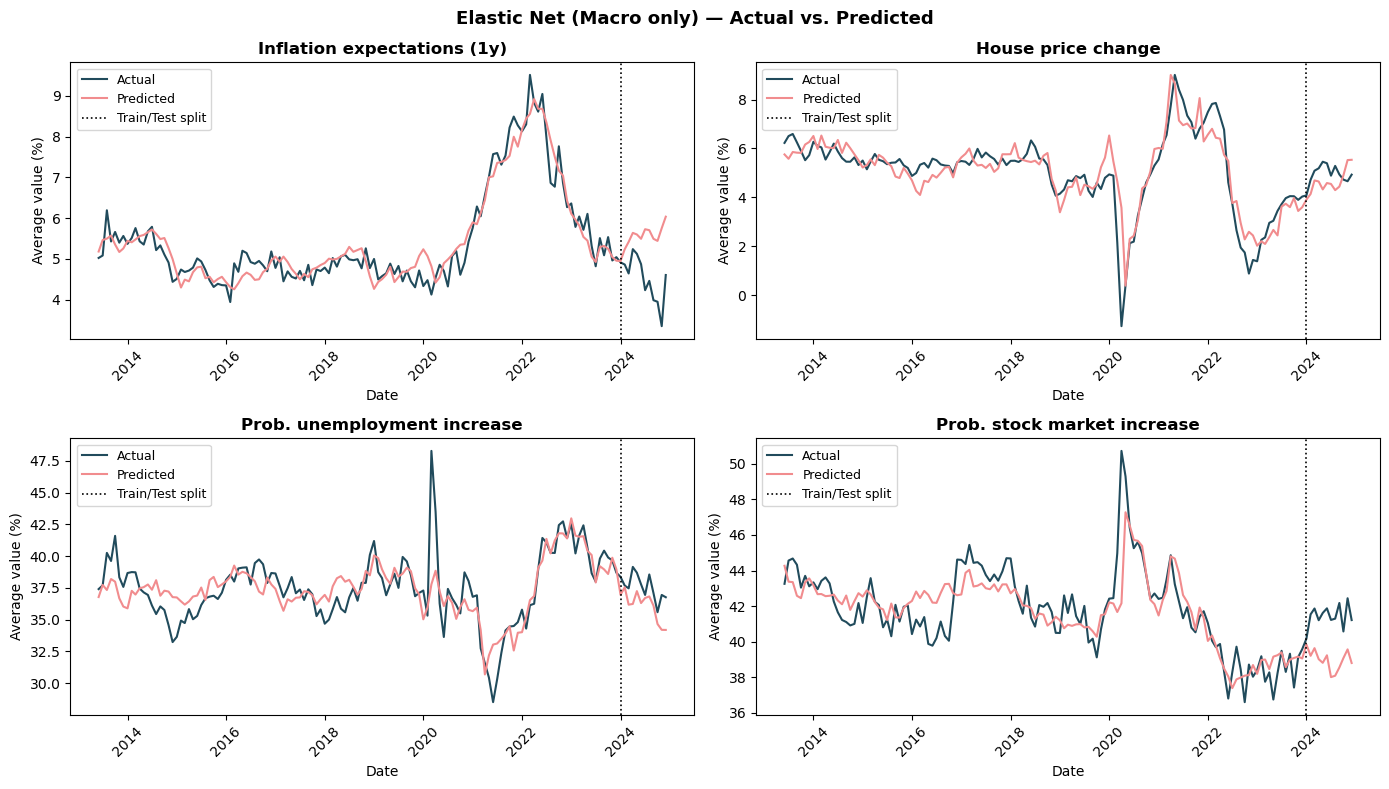

In [55]:
# Elastic Net regression with only macro features
run_regression_experiment('Elastic Net', train_elasticnet, feat_name_macro, macro_features)

Across all five models, performance is remarkably similar where RMSE values are close to 9.1 for `infl_1y`, 8.0 for `house_price_change`, and 22.3–22.5 for both probability targets. $R^2$ is close to zero or negative for all models and targets. The near-identical performance across all models suggests that the choice of model matters little when the features themselves carry limited predictive signal.

Overall, the results indicate that macro/finance variables alone are insufficient to predict individual household expectations  which suggests that macro variables can be informative about aggregate sentiment over time, but have limited power in explaining why individual respondents differ from each other at any given point in time

#### **Regression with macro and individual variables**

##### **Correlation plot for the individual variables**

Before selecting individual-level variables to include alongside the macro features, we examine their pairwise correlations with each target variable. This helps us identify which variables carry the most predictive signal and gives us a baseline in the process of adding individual variables.

In [56]:
# Individual correlations with targets
for target in target_vars:
    plot_correlation_table(sce, target, individual_vars, vmin=global_vmin, vmax=global_vmax)


 Correlation of variables with: infl_1y


,Correlation
female,0.125
black,0.114
age_init,0.043
hispanic,0.041
num_kids,0.035
working,-0.058
couple,-0.065
owner,-0.065
educ,-0.161
hh_inc_bin_rank,-0.171



 Correlation of variables with: house_price_change


,Correlation
black,0.092
female,0.080
age_init,0.069
hispanic,0.032
num_kids,-0.008
working,-0.061
owner,-0.064
couple,-0.071
educ,-0.115
hh_inc_bin_rank,-0.152



 Correlation of variables with: prob_unrate_up


,Correlation
educ,0.062
hh_inc_bin_rank,0.032
working,0.030
couple,0.004
num_kids,-0.008
hispanic,-0.025
owner,-0.032
black,-0.036
age_init,-0.045
female,-0.059



 Correlation of variables with: prob_stocks_up


,Correlation
educ,0.172
hh_inc_bin_rank,0.151
working,0.046
couple,0.034
owner,0.015
num_kids,-0.039
age_init,-0.039
hispanic,-0.048
black,-0.076
female,-0.172


To enhance the predictive power of the model, we selected additional features based on the correlation plots. Starting from the single most correlated individual variable, we added one feature at a time, stopping when additional variables no longer improved the model


In [57]:
# plain list of column names
macro_features_cols = macro_features.columns.tolist()

# Feature set combining macro and individual variables for each target
indiv_features = {
    'infl_1y':             macro_features_cols + ['hh_inc_bin_rank', 'educ', 'female', 'black', 'couple', 'owner'],
    'house_price_change': macro_features_cols + ['hh_inc_bin_rank', 'educ', 'black', 'female'],
    'prob_unrate_up':     macro_features_cols + ['educ', 'female','age_init','black'],
    'prob_stocks_up':     macro_features_cols + ['educ', 'female' , 'hh_inc_bin_rank','black', 'hispanic', 'working','age_init', 'num_kids','couple'],
}

##### **Linear Regression**


  Linear Regression (Macro + Individual) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),8.893,0.031
House price change,7.901,0.031
Prob. unemployment increase,21.985,0.021
Prob. stock market increase,21.274,0.093


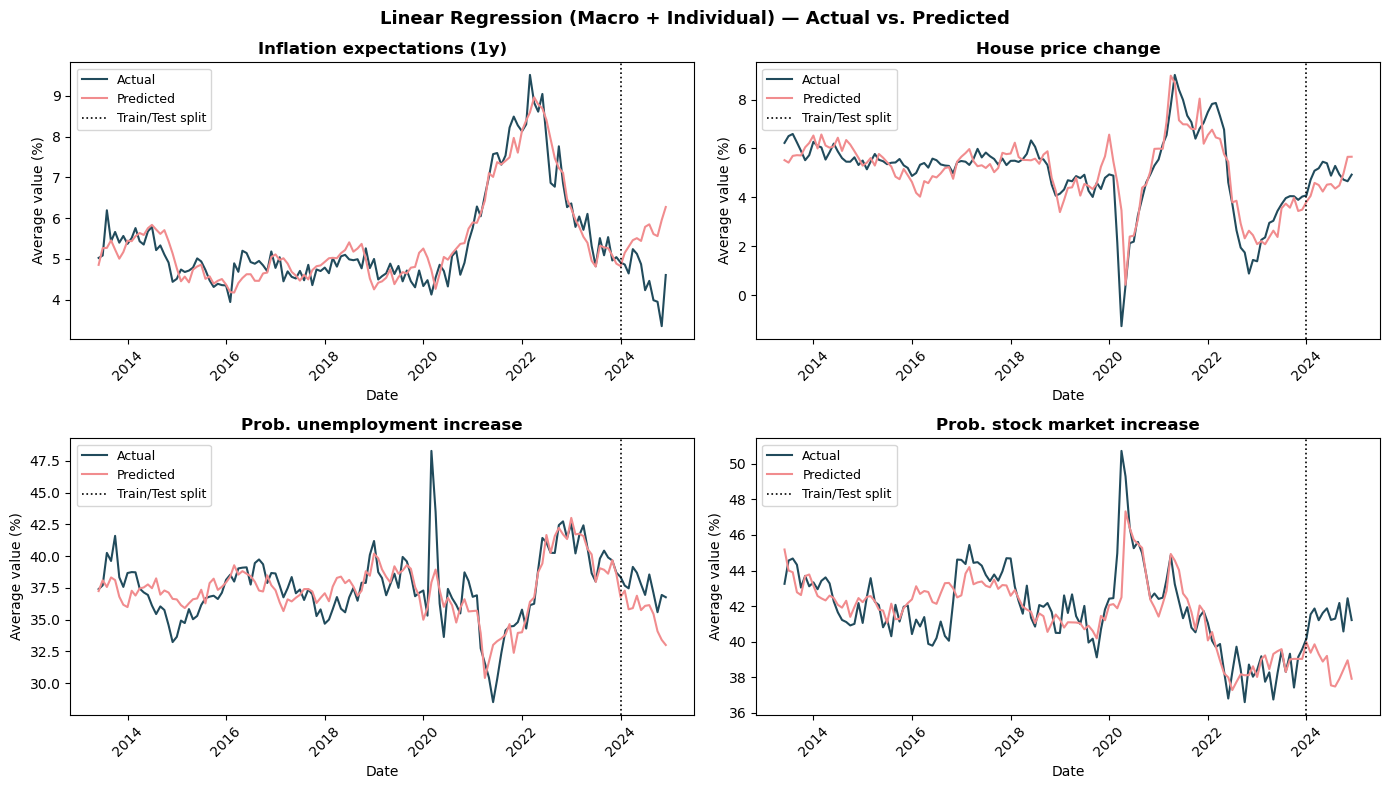

In [58]:
# Linear regression with macro + individual features for each target
run_regression_experiment('Linear Regression', train_linear, feat_name_macro_indiv, indiv_features)

##### **Ridge Regression**

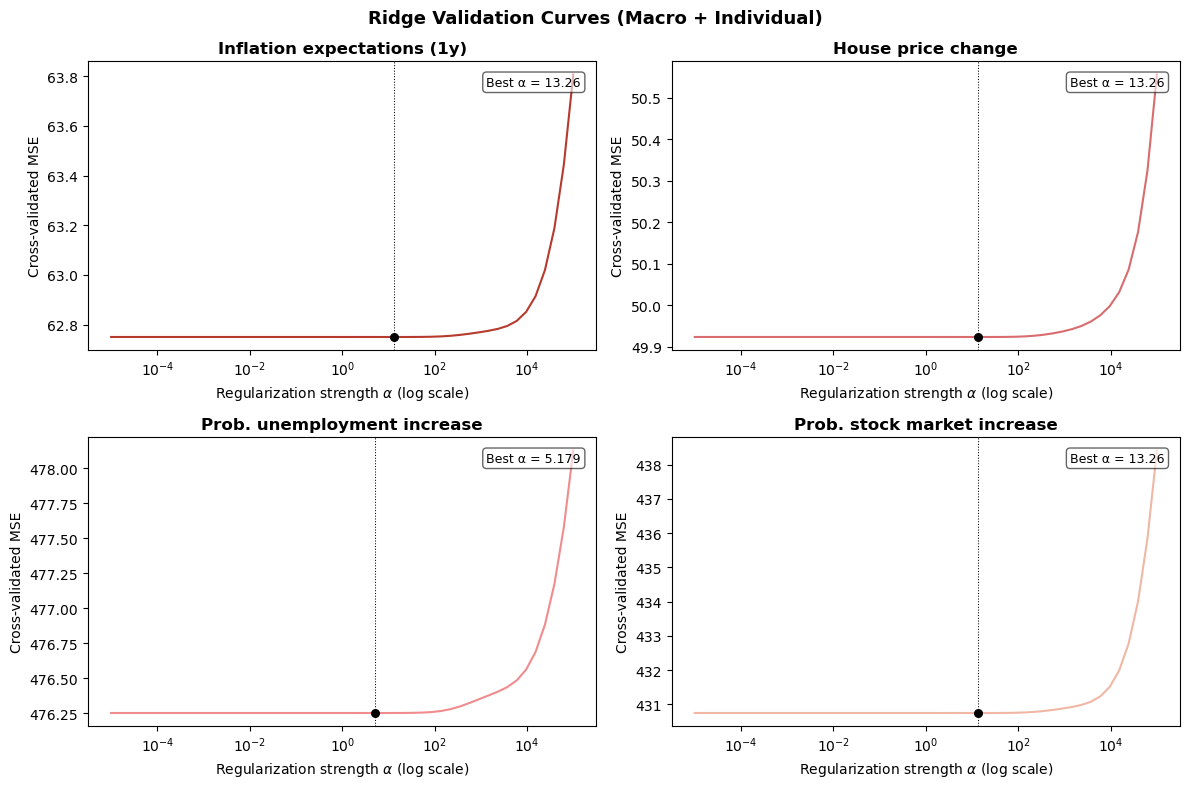


  Ridge (Macro + Individual) — Validation Summary


,Best α,CV MSE
Target,,
Inflation expectations (1y),13.26,62.7502
House price change,13.26,49.9238
Prob. unemployment increase,5.179,476.2523
Prob. stock market increase,13.26,430.7464



  Ridge (Macro + Individual) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),8.892,0.031
House price change,7.901,0.031
Prob. unemployment increase,21.985,0.021
Prob. stock market increase,21.274,0.094


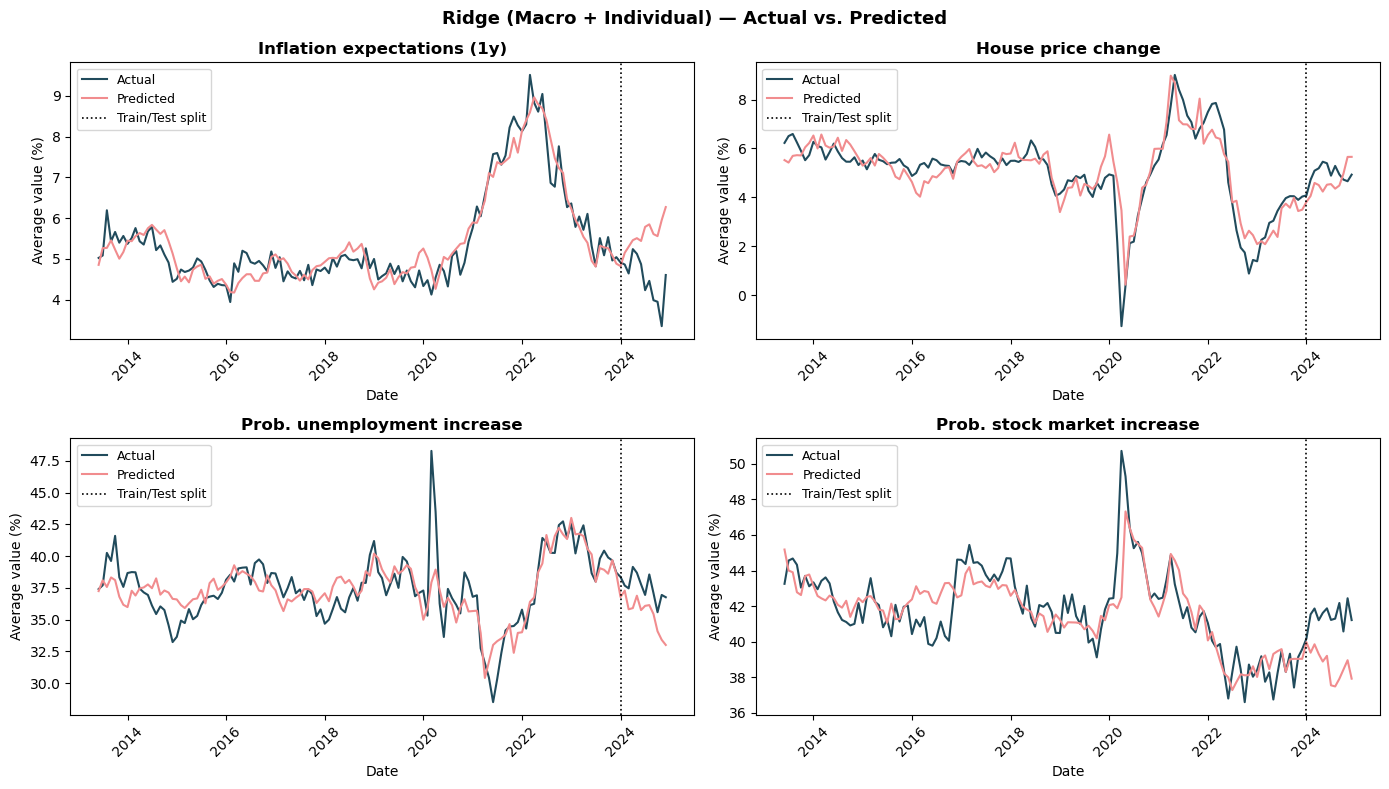

In [59]:
# Ridge regression with macro + individual features for each target
run_regression_experiment('Ridge', train_ridge, feat_name_macro_indiv, indiv_features)

##### **Lasso Regression**

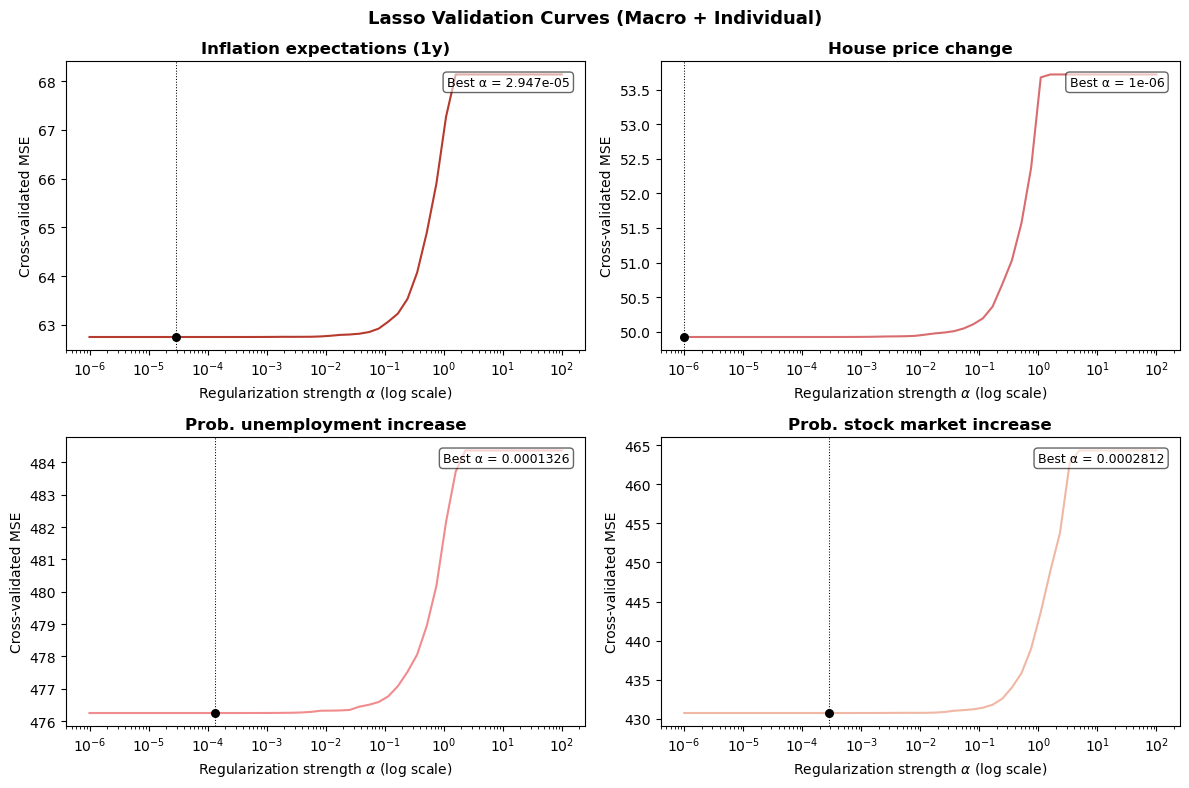


  Lasso (Macro + Individual) — Validation Summary


,Best α,CV MSE
Target,,
Inflation expectations (1y),2.947e-05,62.7503
House price change,1e-06,49.9239
Prob. unemployment increase,0.0001326,476.2524
Prob. stock market increase,0.0002812,430.7467



  Lasso (Macro + Individual) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),8.892,0.031
House price change,7.901,0.031
Prob. unemployment increase,21.985,0.021
Prob. stock market increase,21.273,0.094


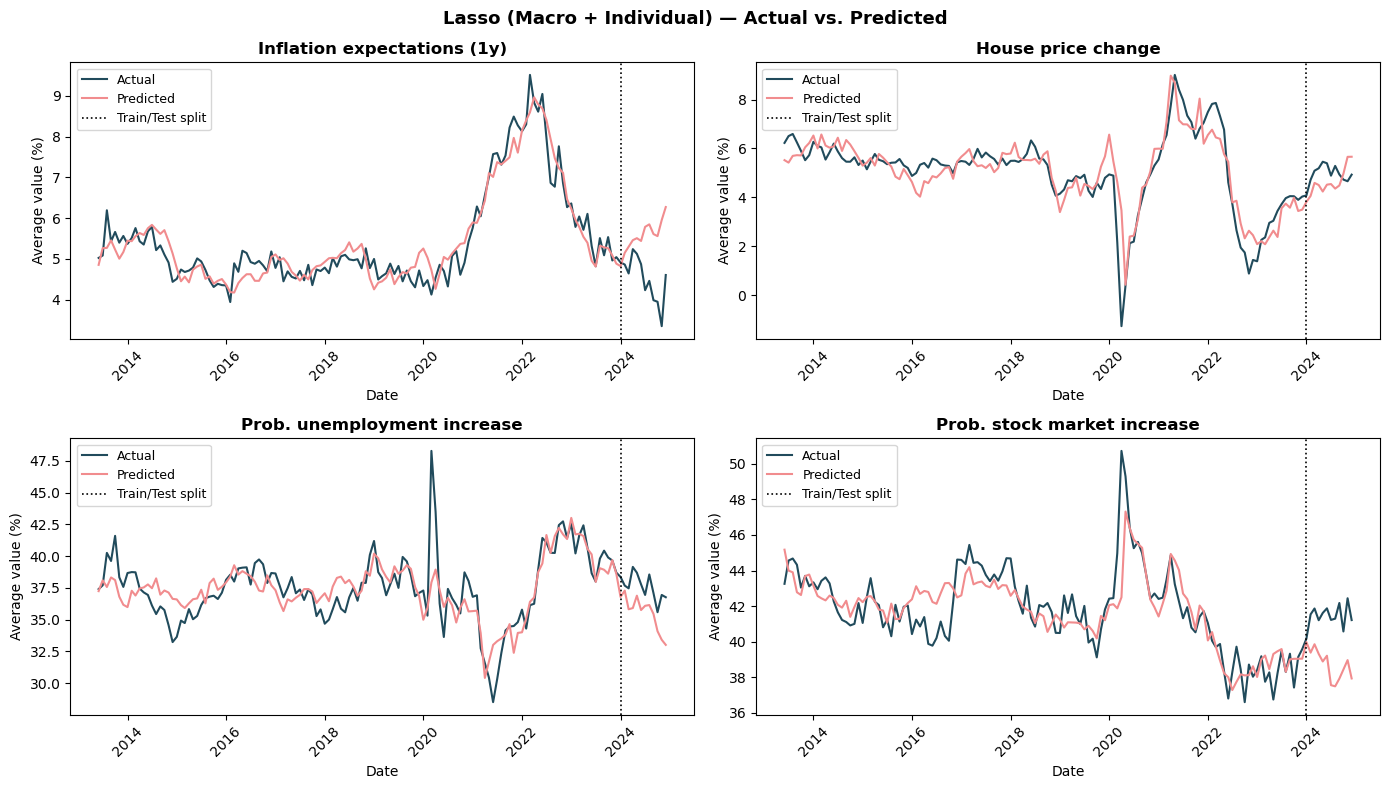

In [60]:
# Lasso regression with macro + individual features for each target
run_regression_experiment('Lasso', train_lasso, feat_name_macro_indiv, indiv_features)

##### **Desision Tree Regression** 

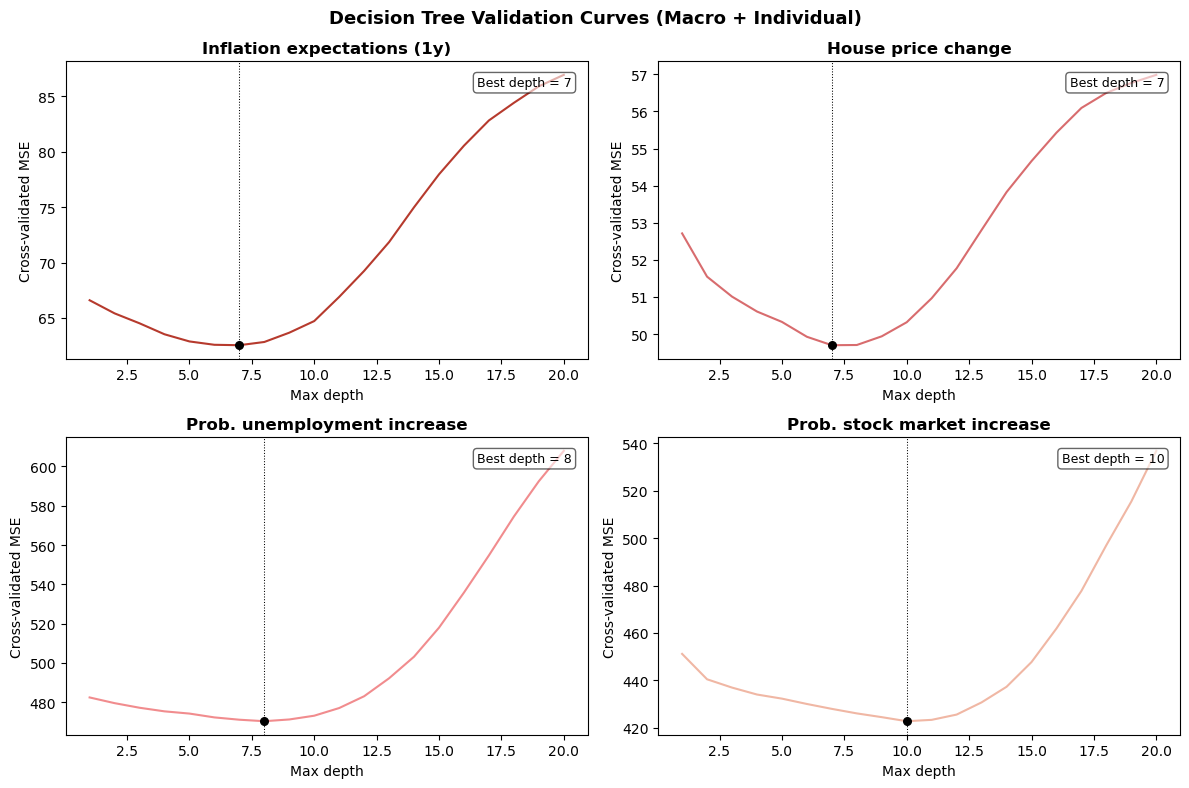


  Decision Tree (Macro + Individual) — Validation Summary


,Best depth,CV MSE
Target,,
Inflation expectations (1y),7,62.5302
House price change,7,49.7001
Prob. unemployment increase,8,470.3701
Prob. stock market increase,10,422.8071



  Decision Tree (Macro + Individual) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),8.974,0.013
House price change,7.995,0.008
Prob. unemployment increase,22.260,-0.004
Prob. stock market increase,21.890,0.040


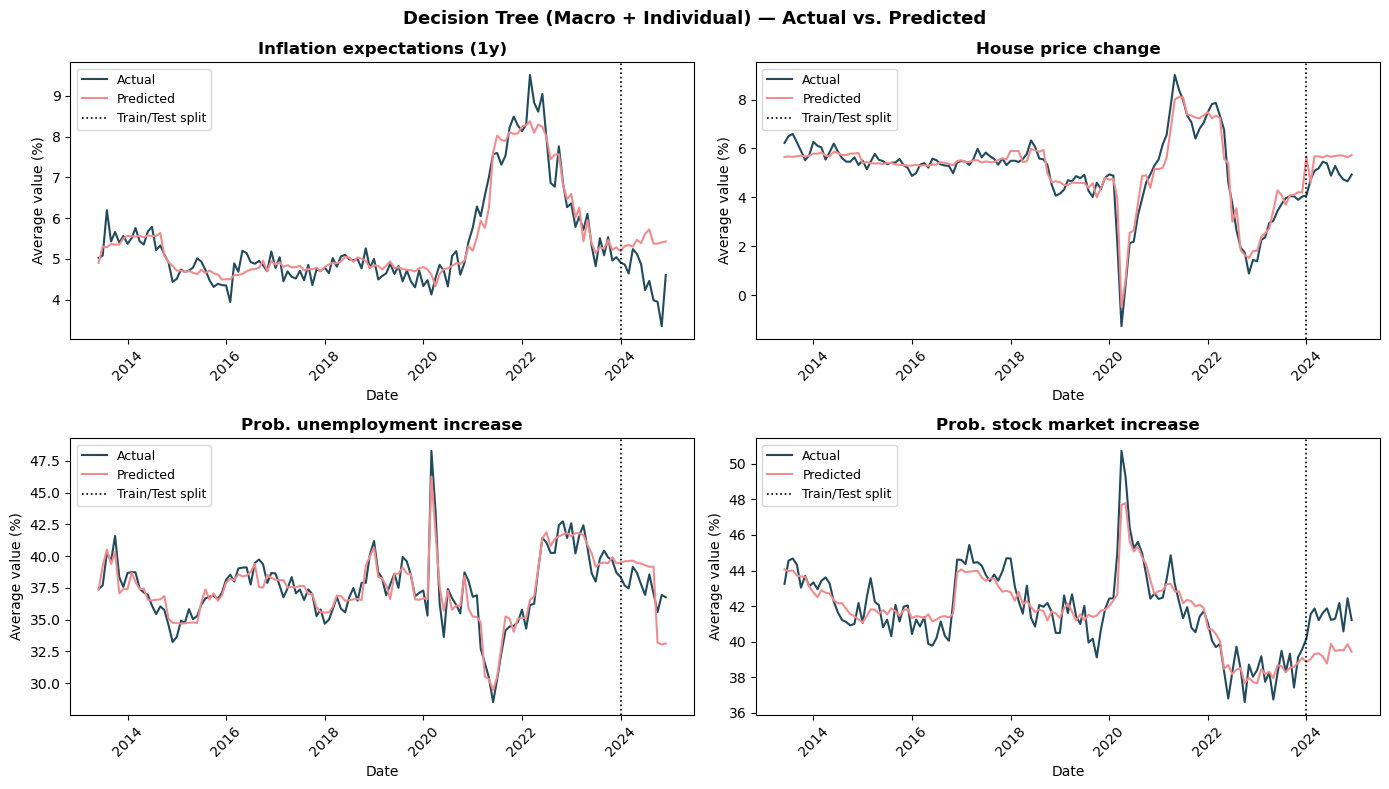

In [61]:
# Decision Tree regression with macro + individual features for each target
run_regression_experiment('Decision Tree', train_tree, feat_name_macro_indiv, indiv_features)

##### **ElasticNet Regression**

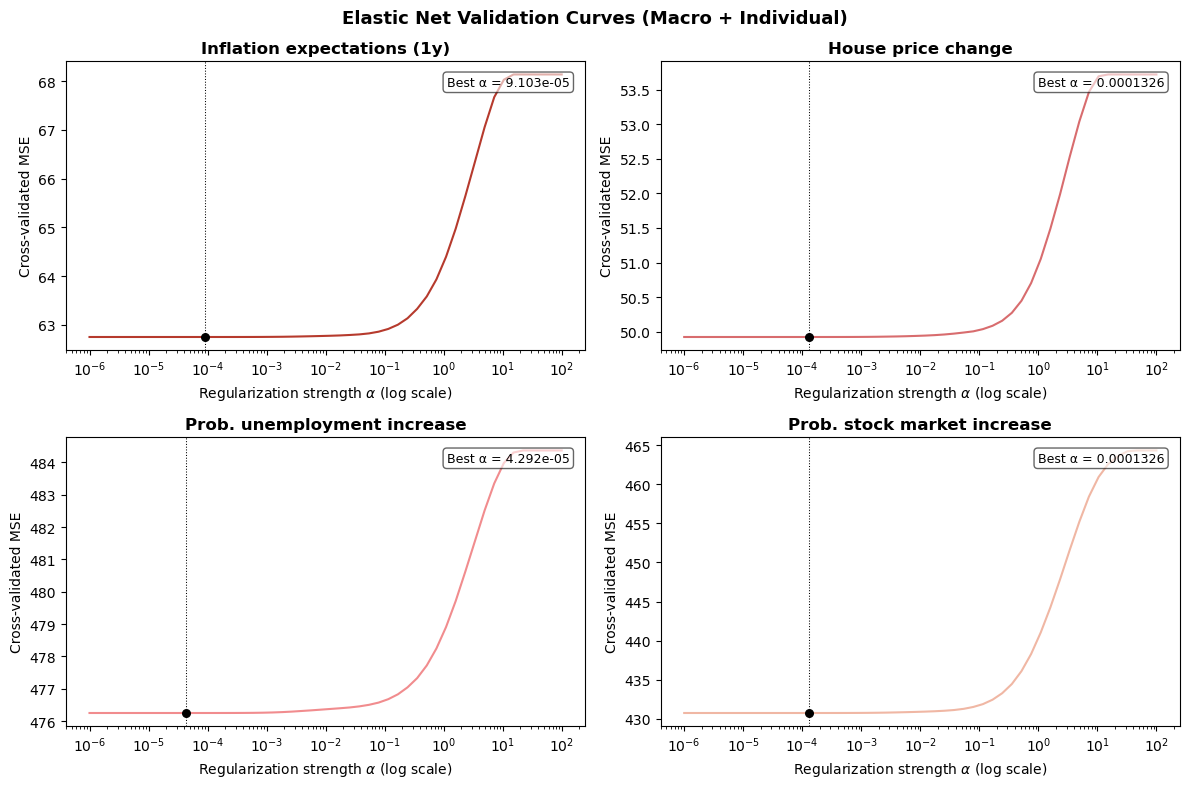


  Elastic Net (Macro + Individual) — Validation Summary


,Best α,L1_ratio,CV MSE
Target,,,
Inflation expectations (1y),9.103e-05,0.1,62.7502
House price change,0.0001326,0.1,49.9239
Prob. unemployment increase,4.292e-05,0.1,476.2523
Prob. stock market increase,0.0001326,0.1,430.7464



  Elastic Net (Macro + Individual) — Test Set Performance


,RMSE,R²
Target,,
Inflation expectations (1y),8.892,0.031
House price change,7.901,0.031
Prob. unemployment increase,21.985,0.021
Prob. stock market increase,21.273,0.094


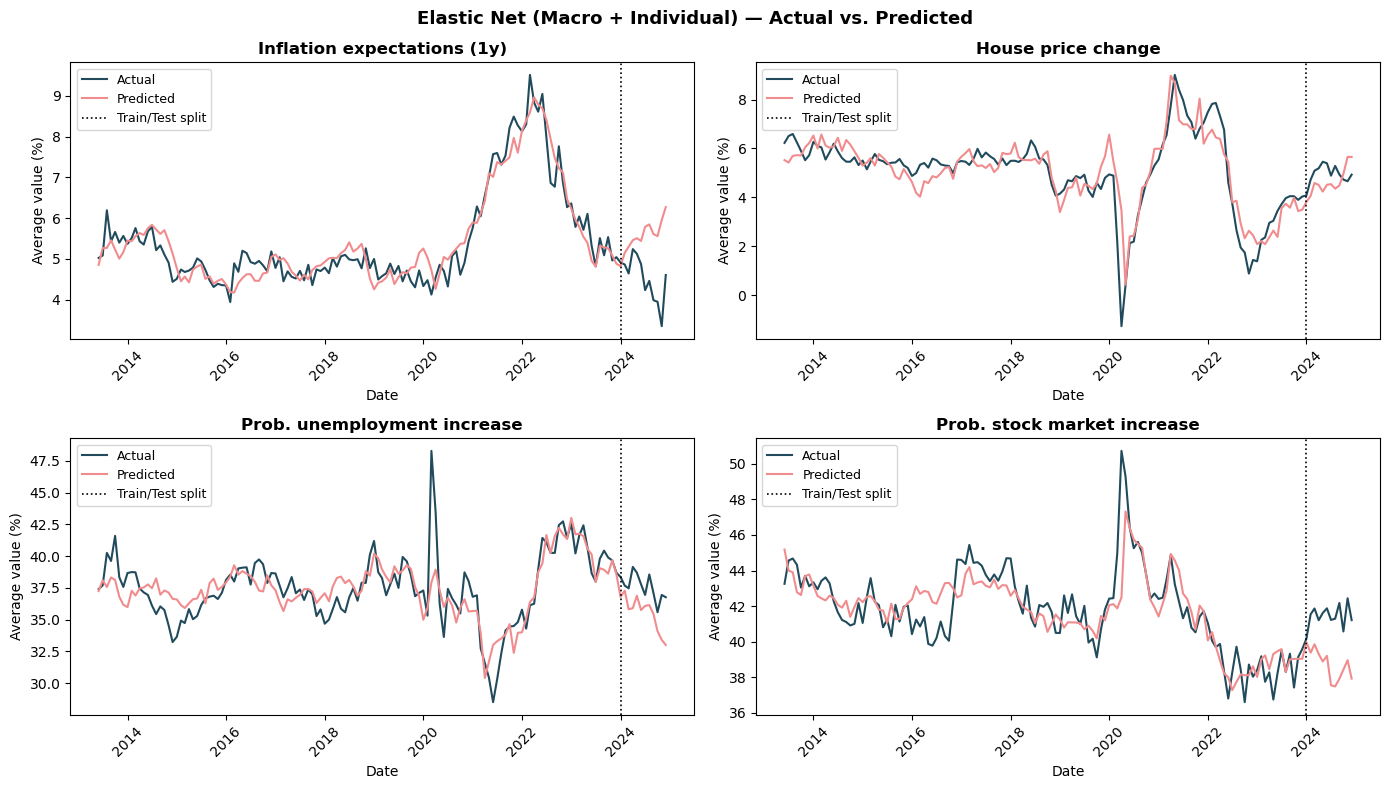

In [62]:
# Elastic Net regression with macro + individual features for each target
run_regression_experiment('Elastic Net', train_elasticnet, feat_name_macro_indiv, indiv_features)

**Linear Regression** has no hyperparameters and does not require feature scaling.

**Ridge, Lasso, and ElasticNet** all require feature scaling since they penalize coefficient magnitudes, without scaling, variables on larger scales would be disproportionately penalized. All three use the regularization strength α as a hyperparameter tuned via cross-validation. ElasticNet additionally tunes `l1_ratio`, which controls the mix between the Lasso and Ridge penalties.

**Decision Tree** requires neither feature scaling nor regularization, but uses `max_depth` as a hyperparameter tuned via cross-validation to control tree complexity.

#### **Evaluating preformance**
Adding individual-level variables leads to a consistent but modest improvement across all models and targets. RMSE decreases slightly and $R^2$ turns positive across all modeles where we include the individual variables. The improvement is most pronounced for `prob_stocks_up`, where $R^2$ rises to around 9.4%, suggesting what we already see in the correlation tabel that demographic characteristics are meaningful predictors of stock market optimism.

However, $R^2$ remains low across all models even with individual variables, indicating that the improvement from adding individual characteristics is not substantial enough to fundamentally change the predictive power of the models. The linear models perform virtually identically to each other, confirming that regularization adds little when the feature set is well-conditioned. The Decision Tree shows slightly weaker out-of-sample performance. Overall, while  individual variables do provide some additional signal, the models still explain only a small share of the variation in household expectations.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 5**

 - **Structure and readability:** Headers for subtasks, markdown cells for explanations and clear distinctions between parts result in well-structured code that is easy to follow.

 - **Functions:** Functions are defined and reused multiple times, eliminating nearly all repetition possible. The `MultiOutputModel` dataclass returns data in a uniform and consistent manner, in addition to avoiding reuse of code.

 - **Vectorization:** Some functions use loops to iterate over a small number of variables, although all data handling uses vectorization.

 - **Additional models:** 

 - **Correct use of models:** The code standardizes features for all models using the `prepare_features` function, although the the explanation given in markdown cell 129 states that linear regression "does not require feature scaling". This does not affect the model, but is an inconsistency accross the notebook. Otherwise, all models correctly cross-validate their hyperparameters.

 - **Feedback:** We use `TimeSeriesSplit` for cross-validation, to ensure hyperparameters are selected without any look-ahead bias from future observations.

***
# **Part 6 - Predicting binary optimism variables**
***

In [63]:
# Target arrays for classification
y_train_cls = train[opt_vars].to_numpy()
y_test_cls  = test[opt_vars].to_numpy()

# Dictionary to store classification results
cls_results = {}

# Hyperparameter grid for Logistic Regression 
C_grid = np.logspace(-2, 2, 20)
depth_grid_rf = {'max_depth': np.arange(2, 11)}
depth_grid_hgb = {'max_depth': np.arange(2, 16)}
knn_grid = np.arange(5, 51, 5)   

#### **Set up helper functions**

In [64]:
# Function to compute and print accuracy, precision, recall, and F1 for a fitted classifier on both training and test
def tabulate_classifier_metrics(model, X_train, y_train, X_test, y_test, label, cv_info=None):
    """
    Compute and print accuracy, precision, recall, and F1 for a fitted classifier on both training and test sets. Stores test results in cls_results.

    Parameters
    ----------
    model: 
        fitted classifier with predict() method
    X_train: 
        preprocessed training features
    y_train:   
        true binary labels for training set
    X_test: 
        preprocessed test features
    y_test: 
        true binary labels for test set
    label: 
        Key for cls_results dict
    cv_info
        optional list of dicts with hyperparameter info per target
    """

    # Print hyperparameter info in a table if provided
    if cv_info is not None:
        cv_tbl = pd.DataFrame([
            {'Target': opt_vars[j], **cv_info[j]}
            for j in range(len(opt_vars))
        ]).set_index('Target').round(4)
        print(f"\n{'=' * 55}")
        print(f"  {label} — Hyperparameters")
        print(f"{'=' * 55}")
        display(cv_tbl)

    cls_results[label] = {}

    # Compute predictions and metrics for both train and test sets
    for split_name, X_split, y_split in [('Train', X_train, y_train),
                                          ('Test',  X_test,  y_test)]:
        y_pred = model.predict(X_split)

        rows = []
        for i, name in enumerate(opt_vars):
            acc  = accuracy_score (y_split[:, i], y_pred[:, i])
            prec = precision_score(y_split[:, i], y_pred[:, i], zero_division=0)
            rec  = recall_score   (y_split[:, i], y_pred[:, i], zero_division=0)
            f1   = f1_score       (y_split[:, i], y_pred[:, i], zero_division=0)
            rows.append({'Target': name, 'Accuracy': round(acc, 3), 'Precision': round(prec, 3),
                         'Recall': round(rec, 3), 'F1': round(f1, 3)})

            if split_name == 'Test':
                cls_results[label][name] = {
                    'Accuracy': acc, 'Precision': prec,
                    'Recall': rec,   'F1': f1
                }

        tbl = pd.DataFrame(rows).set_index('Target')
        print(f"\n{'=' * 55}")
        print(f"  {label} — {split_name} set")
        print(f"{'=' * 55}")
        display(tbl)

In [65]:
# Function to plot monthly-average actual vs. predicted probabilities for the classification targets
def plot_optimist_fractions(model, X_train, X_test, feat_name, model_name):
    """"
    Plot monthly-average actual vs. predicted probabilities for the classification targets.

    Parameters
    ----------
    model:
        fitted classifier with predict_proba() method
    X_train:
        numpy array or list of numpy arrays of training features
    X_test:
        numpy array or list of numpy arrays of test features
    feat_name:
        Feature set label used in the plot title
    model_name:
        Model name used in the plot title   
    """

    # Handle per-target feature lists
    X_trains = X_train if isinstance(X_train, list) else [X_train] * len(model.models)
    X_tests  = X_test  if isinstance(X_test,  list) else [X_test]  * len(model.models)

    # predict_proba returns P(class=1) for each sub-model
    prob_train = np.column_stack([m.predict_proba(X)[:, 1] for m, X in zip(model.models, X_trains)])
    prob_test  = np.column_stack([m.predict_proba(X)[:, 1] for m, X in zip(model.models, X_tests)])

    # Create subplots for each classification target
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    split_date = pd.Timestamp('2024-01-01')

    # Plot actual vs. predicted probabilities for each classification target, with a vertical line indicating the train/test split
    for i, (var, label) in enumerate(zip(opt_vars, opt_labels)):
        ax = axes[i]

        actual = sce.groupby(sce['date'].dt.to_period('M'))[var].mean()
        actual.index = actual.index.to_timestamp()

        tr = train[['date']].copy().reset_index(drop=True)
        te = test[['date']].copy().reset_index(drop=True)
        tr['pred'] = prob_train[:, i]
        te['pred'] = prob_test[:, i]
        combined  = pd.concat([tr, te])
        predicted = combined.groupby(combined['date'].dt.to_period('M'))['pred'].mean()
        predicted.index = predicted.index.to_timestamp()

        ax.plot(actual.index,    actual.values,    color=colors[8], lw=1.5, label='Actual')
        ax.plot(predicted.index, predicted.values, color=colors[2], lw=1.5, label='Predicted prob.')
        ax.axvline(split_date, color='black', linestyle=':', lw=1.0, label='Train/Test split')
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Fraction / Probability')
        ax.legend(fontsize=8)

    # Adjust layout and print plot
    fig.suptitle(f'{model_name} — {feat_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [66]:
# Function to plot confusion matrices for each optimist variable
def plot_confusion_matrices(model, X, y_true, title_prefix):
    """
    Plot a confusion matrix for each binary target variable.
 
    Parameters
    ----------
    model: 
        fitted classifier
    X: 
        feature matrix
    y_true:
        true binary labels
    title_prefix:
        string prefix for the subplot title
    """
    
    # Predict labels and plot confusion matrices for each optimist variable
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    y_pred = model.predict(X)
 
    # Loop through each optimist variable and corresponding subplot
    for i, (var, label) in enumerate(zip(opt_vars, opt_labels)):
        cm = ConfusionMatrixDisplay.from_predictions(
            y_true[:, i], y_pred[:, i],
            display_labels=['Pessimist', 'Optimist'],
            cmap=c_map, colorbar=False,
            values_format=',d',
            ax=axes[i]
        )
        axes[i].set_title(f'{title_prefix}\n{label}', fontsize=10, fontweight='bold')
 
    plt.tight_layout()
    plt.show()

In [67]:
# Function to run the full classification pipeline for one model and one feature set
def run_classification_experiment(model_name, train_fn, feat_name, features):
    """
    Run the full classification pipeline for one model and one feature set: prepare features -> fit via train_fn -> evaluate -> plot probabilities and confusion matrices.

    Parameters
    ----------
    model_name:
        Display name for the model
    train_fn:
        Function that takes X_train, y_train_cls, feat_name and returns a fitted classifier
    feat_name:
        Display name for the feature set
    features:
        List of feature variable names or dictionary of the target list of feature variable names to prepare    
    """
    
    # Prepare features for classification
    xy = prepare_features(features, vars_list=opt_vars)

    # Handle case where prepare_features returns a list of arrays vs. a single array used for all targets
    if isinstance(xy, list):
        X_train_f = [pair[0] for pair in xy]
        X_test_f  = [pair[1] for pair in xy]
    else:
        X_train_f, X_test_f = xy

    # Fit the classifier using the caller-supplied training function
    model, cv_info = train_fn(X_train_f, y_train_cls, feat_name)
    label = f'{model_name} ({feat_name})'

    # Evaluate the fitted classifier and print metric
    tabulate_classifier_metrics(
        model, X_train_f, y_train_cls,
        X_test_f, y_test_cls,
        label, cv_info=cv_info
    )

    # Plot monthly-average actual vs. predicted probabilities and confusion matrices for the classification targets
    if cv_info is not None:
        for j, name in enumerate(opt_vars):
            cls_results[label][name].update(cv_info[j])

    plot_optimist_fractions(model, X_train_f, X_test_f, feat_name, model_name)
    plot_confusion_matrices(model, X_test_f, y_test_cls, label)

#### **Helper functions regressions**

In [68]:
# Train a Logistic Regression model with cross-validated C selection and validation curve plotting
def train_logistic(X_train, y_train, feat_name=None):
    """"
    Parameters
    ----------
    X_train:
        numpy array or list of numpy arrays of training features
    y_train:
        numpy array of shape n_samples, n_targets of binary training target variables
    feat_name:
        optional feature set name for display purposes

    Returns
    -------
    model:
        Fitted Logistic Regression model with the best C for each target variable
    """
    # Fit one LogisticRegression with GridSearchCV per target variable to select the best C based on F1 score, and collect cross-validation info for each target variable
    X_list = X_train if isinstance(X_train, list) else [X_train] * len(opt_vars)
    models, cv_info = [], []
    for j, X in enumerate(X_list):
        gs = GridSearchCV(
            LogisticRegression(l1_ratio=0, solver='lbfgs', max_iter=1000, random_state=1234),
            param_grid={'C': C_grid},
            cv=kf, scoring='f1', n_jobs=-1
        )

        # Fit the GridSearchCV to find the best C for the current target variable
        gs.fit(X, y_train[:, j])
        models.append(gs.best_estimator_)
        cv_info.append({'Best C': gs.best_params_['C'], 'CV F1': gs.best_score_})    
    return MultiOutputModel(models), cv_info

In [69]:
# Train a Random Forest Classifier with cross-validated max_depth selection and validation curve plotting
def train_random_forest(X_train, y_train, feat_name=None):
    """
    Parameters
    ----------
    X_train:
        numpy array or list of numpy arrays of training features
    y_train:
        numpy array of shape n_samples, n_targets of binary training target variables
    feat_name:
        optional feature set name for display purposes  
    Returns
    -------
    model:
        Fitted Random Forest Classifier with the best max_depth for each target variable
    """

    # Fit one RandomForestClassifier with GridSearchCV per target variable to select the best max_depth based on F1 score, and collect cross-validation
    X_list = X_train if isinstance(X_train, list) else [X_train] * len(opt_vars)
    models, cv_info = [], []
    for j, X in enumerate(X_list):
        gs = GridSearchCV(
            RandomForestClassifier(n_estimators=50, random_state=1234, n_jobs=-1),
            param_grid=depth_grid_rf, cv=kf, scoring='f1', n_jobs=-1
        )

        # Fit the GridSearchCV to find the best max_depth for the current target variable
        gs.fit(X, y_train[:, j])
        models.append(gs.best_estimator_)
        cv_info.append({
            'Best max_depth': gs.best_params_['max_depth'],
            'CV F1':          gs.best_score_
        })
    return MultiOutputModel(models), cv_info

In [70]:
# Train a HistGradientBoostingClassifier with cross-validated max_depth selection and validation curve plotting
def train_hgb(X_train, y_train, feat_name=None):
    """"
    Parameters    
    ----------
    X_train:
        numpy array or list of numpy arrays of training features
    y_train:
        numpy array of shape n_samples, n_targets of binary training target variables
    feat_name:
        optional feature set name for display purposes
    
    Returns    
    -------
    model:
        Fitted HistGradientBoostingClassifier with the best max_depth for each target variable
    """ 

    # Fit one HistGradientBoostingClassifier with GridSearchCV per target variable to select the best max_depth based on F1 score, and collect cross-validation
    X_list = X_train if isinstance(X_train, list) else [X_train] * len(opt_vars)
    models, cv_info = [], []
    for j, X in enumerate(X_list):
        gs = GridSearchCV(
            HistGradientBoostingClassifier(random_state=1234),
            param_grid=depth_grid_hgb, cv=kf, scoring='f1', n_jobs=-1
        )

        # Fit the GridSearchCV to find the best max_depth for the current target variable
        gs.fit(X, y_train[:, j])
        models.append(gs.best_estimator_)
        cv_info.append({
            'Best max_depth': gs.best_params_['max_depth'],
            'CV F1':          gs.best_score_
        })
    return MultiOutputModel(models), cv_info

In [71]:
# Train a K-Nearest Neighbors Classifier with cross-validated n_neighbors selection and validation curve plotting
def train_knn(X_train, y_train, feat_name=None):
    """
    Fit a K-Nearest Neighbors classifier for each target in opt_vars. Uses GridSearchCV to tune n_neighbors. Feature scaling is handled internally via
    a Pipeline since KNN is distance-based.

    Parameters
    ----------
    X_train:
        numpy array or list of numpy arrays of training features
    y_train:
        numpy array of shape n_samples, n_targets of binary training target variables
    feat_name:
        optional feature set name for display purposes
    Returns
    -------
    model:
        Fitted K-Nearest Neighbors Classifier with the best n_neighbors for each target variable
    """

    # Fit one KNeighborsClassifier with GridSearchCV per target variable to select the best n_neighbors based on F1 score, and collect cross-validation 
    X_list = X_train if isinstance(X_train, list) else [X_train] * len(opt_vars)
    models, cv_info = [], []
    for j, X in enumerate(X_list):
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier()),
        ])
        gs = GridSearchCV(
            pipe,
            param_grid={'knn__n_neighbors': knn_grid},
            cv=kf, scoring='f1', n_jobs=-1,
        )

        # Fit the GridSearchCV to find the best n_neighbors for the current target variable
        gs.fit(X, y_train[:, j])
        models.append(gs.best_estimator_)
        cv_info.append({
            'Best n_neighbors': gs.best_params_['knn__n_neighbors'],
            'CV F1': gs.best_score_,
        })
    return MultiOutputModel(models), cv_info

#### **Regression with macro variables**

We examine the correlation between the macro variables and the optimism targets as an indication of how well these variables will be able to predict the binary outcomes in the classification models.

In [72]:
# Correlation of macro variables with each optimist target
for target in opt_vars:
    plot_correlation_table(sce, target, macro_features_cols, vmin=global_vmin, vmax=global_vmax)


 Correlation of variables with: optimist_unrate


,Correlation
sp500_rel_12m,0.069
oil_rel_12m,0.045
Unrate,0.042
HPI_rel_4q,0.028
GDP_rel_4q,0.010
sp500,0.006
mortgage_abs_1m,0.004
oil_price,-0.004
CPI_rel_12m,-0.006
dollar_rel_12m,-0.034



 Correlation of variables with: optimist_stocks


,Correlation
Unrate,0.043
sp500_rel_12m,0.037
oil_rel_12m,-0.000
mortgage_abs_1m,-0.009
GDP_rel_4q,-0.010
dollar_rel_12m,-0.014
HPI_rel_4q,-0.016
oil_price,-0.018
sp500,-0.019
FedFunds,-0.027



 Correlation of variables with: optimist_house_price


,Correlation
sp500_rel_12m,0.143
GDP_rel_4q,0.054
oil_rel_12m,0.041
Unrate,0.019
mortgage_abs_1m,-0.014
oil_price,-0.024
dollar_rel_12m,-0.037
HPI_rel_4q,-0.038
FedFunds,-0.154
Mortgage,-0.154


Overall, the correlations between macro variables and the optimism targets are weak across the board, suggesting that macro variables alone will have limited predictive power for the classification models. However we see that `optimist_house_price` shows stronger correlations with several macro variables.

##### **Logistic Regression**


  Logistic Regression (Macro only) — Hyperparameters


,Best C,CV F1
Target,,
optimist_unrate,0.01,0.7504
optimist_stocks,0.01,0.0000
optimist_house_price,0.01,0.9130



  Logistic Regression (Macro only) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.602,0.603,0.994,0.750
optimist_stocks,0.697,0.000,0.000,0.000
optimist_house_price,0.841,0.843,0.996,0.913



  Logistic Regression (Macro only) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.585,0.585,1.0,0.738
optimist_stocks,0.680,0.000,0.0,0.000
optimist_house_price,0.788,0.788,1.0,0.881


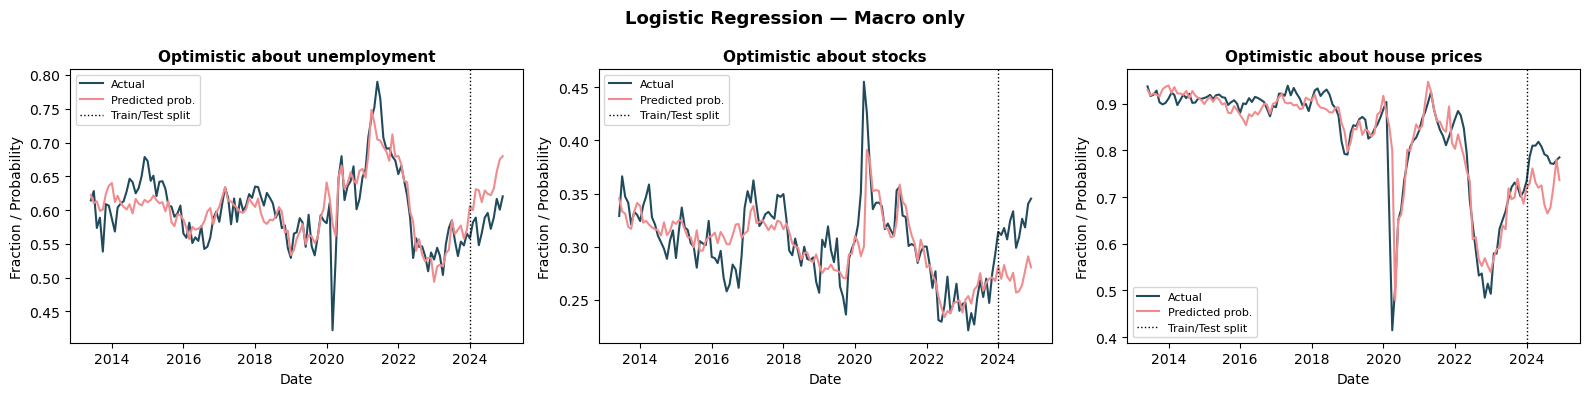

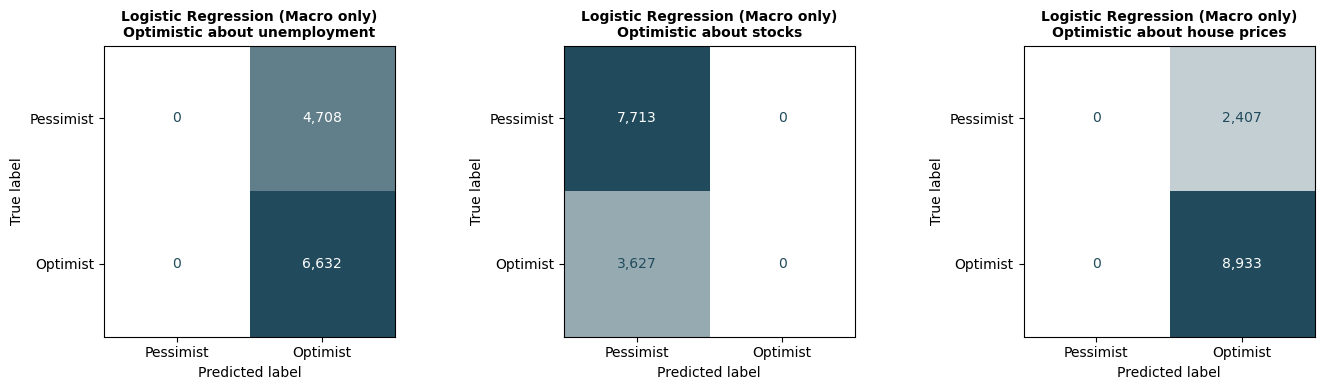

In [73]:
# Logistic Regression with only macro features
run_classification_experiment('Logistic Regression', train_logistic, feat_name_macro, macro_features)

##### **Random forest**

/opt/anaconda3/envs/FIE463/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



  Random Forest (Macro only) — Hyperparameters


,Best max_depth,CV F1
Target,,
optimist_unrate,2,0.7518
optimist_stocks,2,0.0000
optimist_house_price,3,0.9137



  Random Forest (Macro only) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.602,0.602,1.000,0.752
optimist_stocks,0.697,0.000,0.000,0.000
optimist_house_price,0.842,0.843,0.997,0.914



  Random Forest (Macro only) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.585,0.585,1.0,0.738
optimist_stocks,0.680,0.000,0.0,0.000
optimist_house_price,0.788,0.788,1.0,0.881


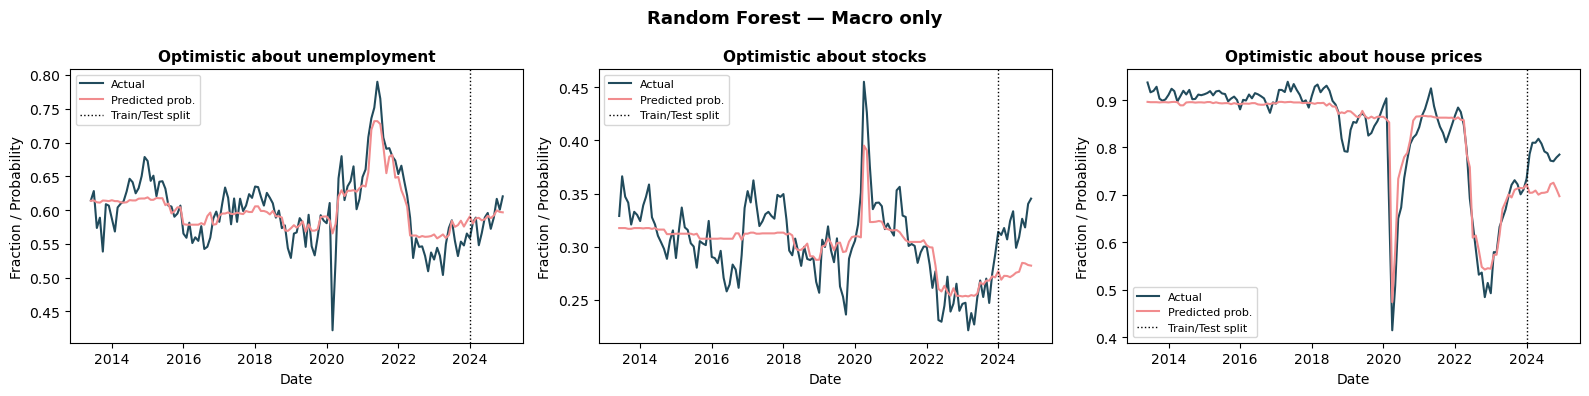

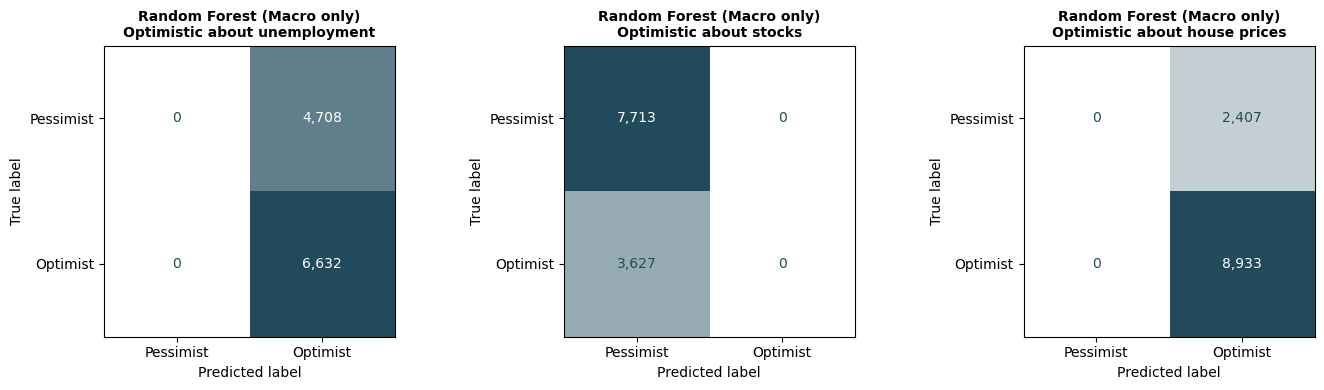

In [74]:
# Random Forest Classifier with only macro features
run_classification_experiment('Random Forest', train_random_forest, feat_name_macro, macro_features)

##### **HistGradientBoosting Classifier**


  HistGradientBoosting (Macro only) — Hyperparameters


,Best max_depth,CV F1
Target,,
optimist_unrate,2,0.7514
optimist_stocks,2,0.0000
optimist_house_price,2,0.9134



  HistGradientBoosting (Macro only) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.603,0.603,0.996,0.751
optimist_stocks,0.697,0.000,0.000,0.000
optimist_house_price,0.842,0.843,0.997,0.914



  HistGradientBoosting (Macro only) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.585,0.585,1.0,0.738
optimist_stocks,0.680,0.000,0.0,0.000
optimist_house_price,0.788,0.788,1.0,0.881


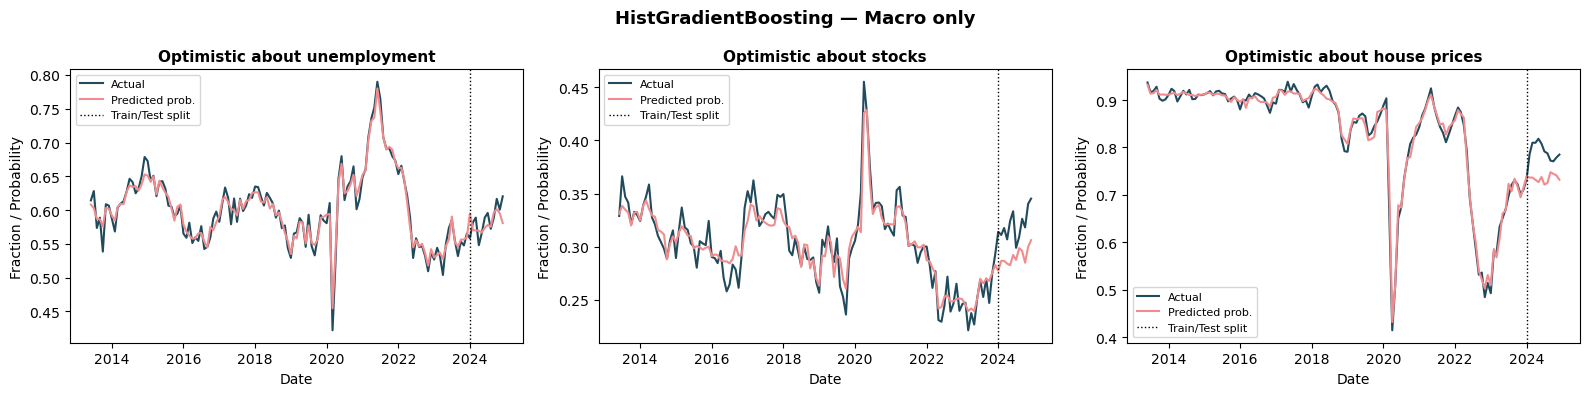

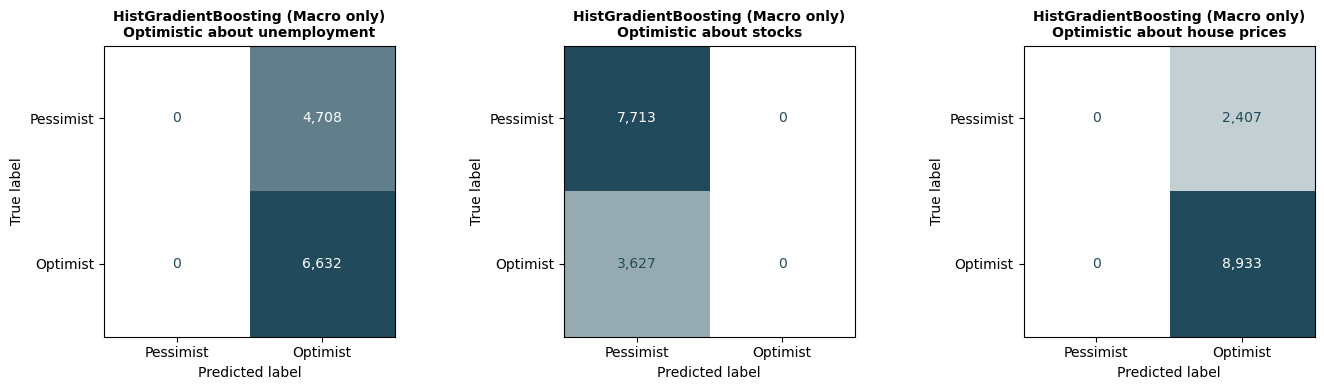

In [75]:
# HistGradientBoostingClassifier with only macro features
run_classification_experiment('HistGradientBoosting', train_hgb, feat_name_macro, macro_features)

##### **KNN**


  KNN (Macro only) — Hyperparameters


,Best n_neighbors,CV F1
Target,,
optimist_unrate,45,0.7384
optimist_stocks,5,0.1849
optimist_house_price,45,0.9130



  KNN (Macro only) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.600,0.606,0.960,0.743
optimist_stocks,0.640,0.318,0.165,0.217
optimist_house_price,0.841,0.850,0.984,0.912



  KNN (Macro only) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.585,0.585,1.0,0.738
optimist_stocks,0.680,0.000,0.0,0.000
optimist_house_price,0.788,0.788,1.0,0.881


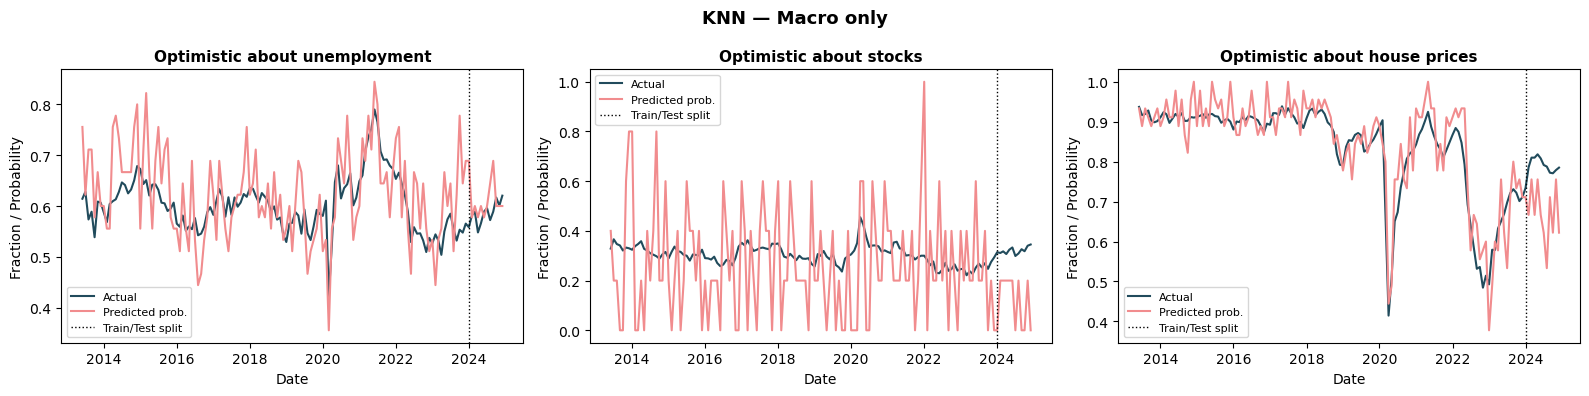

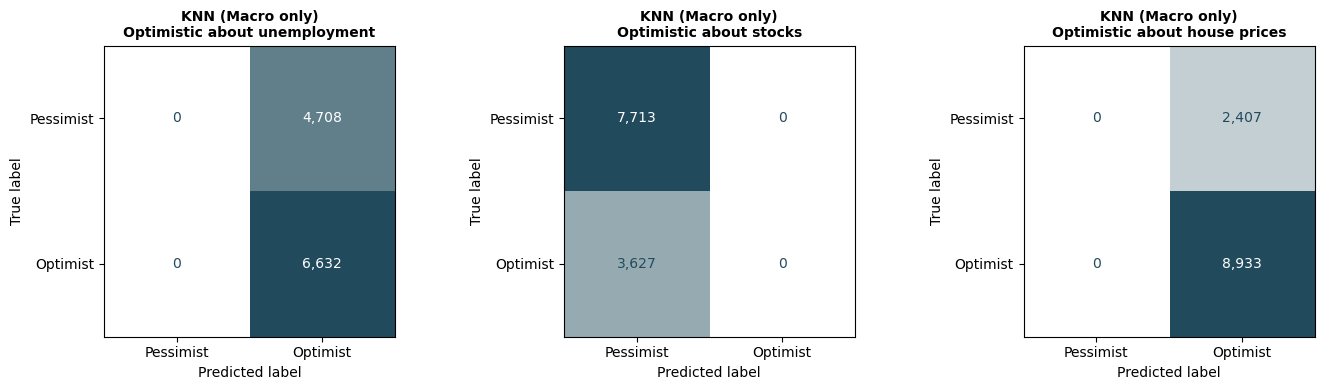

In [76]:
# K-Nearest Neighbors Classifier with only macro features
run_classification_experiment('KNN', train_knn, feat_name_macro, macro_features)

All four models produce similar results on the macro-only feature set, consistent with the weak correlations observed earlier. The confusion matrices reveal that Logistic Regression, Random Forest, and HistGradientBoosting all collapse to predicting the majority class for each target and classify every observation as Optimist for `optimist_unrate` and `optimist_house_price`, and every observation as Pessimist for `optimist_stocks`. This indicates the models have learned nothing beyond the class distribution, which is reflected in an F1 score of 0.000 for `optimist_stocks` across all three models.

KNN shows slightly more variation in its predicted probabilities, as visible in the time series plots, but ultimately collapses to the same degenerate behavior on the test set. The accuracy figures that comes to ~0.59, ~0.68, ~0.79 are therefore misleading and they simply reflect the fraction of the majority class rather than any genuine predictive ability. Train and test metrics are nearly identical across all models, suggesting that the issue is not overfitting but rather insufficient signal in the macro features to distinguish between optimists and pessimists at the individual level.

#### **Regression with macro and individual variables**

##### **Correlation plot for the individual variables**

As in part 5, before selecting individual-level variables to include alongside the macro features, we examine their pairwise correlations with each target variable. This helps us identify which variables carry the most predictive signal and gives us a baseline in the process of adding individual variables.

In [77]:
# Individual correlations with optimist targets
for target in opt_vars:
    plot_correlation_table(sce, target, individual_vars, vmin=global_vmin, vmax=global_vmax)


 Correlation of variables with: optimist_unrate


,Correlation
female,0.041
age_init,0.031
black,0.026
hispanic,0.024
owner,0.024
num_kids,0.007
couple,-0.003
hh_inc_bin_rank,-0.021
working,-0.021
educ,-0.040



 Correlation of variables with: optimist_stocks


,Correlation
educ,0.129
hh_inc_bin_rank,0.110
working,0.041
couple,0.022
owner,0.004
num_kids,-0.029
hispanic,-0.030
age_init,-0.042
black,-0.060
female,-0.139



 Correlation of variables with: optimist_house_price


,Correlation
age_init,0.071
owner,0.027
black,-0.001
hh_inc_bin_rank,-0.002
couple,-0.004
hispanic,-0.007
educ,-0.007
female,-0.028
working,-0.028
num_kids,-0.028


Overall, the individual variable correlations are weak across the board, similar to what we observed for the macro variables. The exception is `optimist_stocks`, where we see  somewhat stronger correlations.

In [78]:
# Feature set combining macro and individual variables for each optimist target, based on correlation
indiv_features_opt = {
    'optimist_unrate':       macro_features_cols + ['female', 'educ', 'age_init','black', 'hispanic'],
    'optimist_stocks':       macro_features_cols + ['female', 'educ', 'hh_inc_bin_rank','black','age_init','working','hispanic'],
    'optimist_house_price':  macro_features_cols + ['age_init', 'num_kids', 'female', 'owner', 'working'],
}

##### **Logistic Regression**


  Logistic Regression (Macro + Individual) — Hyperparameters


,Best C,CV F1
Target,,
optimist_unrate,14.3845,0.7510
optimist_stocks,5.4556,0.0186
optimist_house_price,0.0100,0.9125



  Logistic Regression (Macro + Individual) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.608,0.608,0.983,0.751
optimist_stocks,0.697,0.513,0.009,0.019
optimist_house_price,0.840,0.844,0.993,0.913



  Logistic Regression (Macro + Individual) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.585,0.585,1.0,0.738
optimist_stocks,0.680,0.000,0.0,0.000
optimist_house_price,0.788,0.788,1.0,0.881


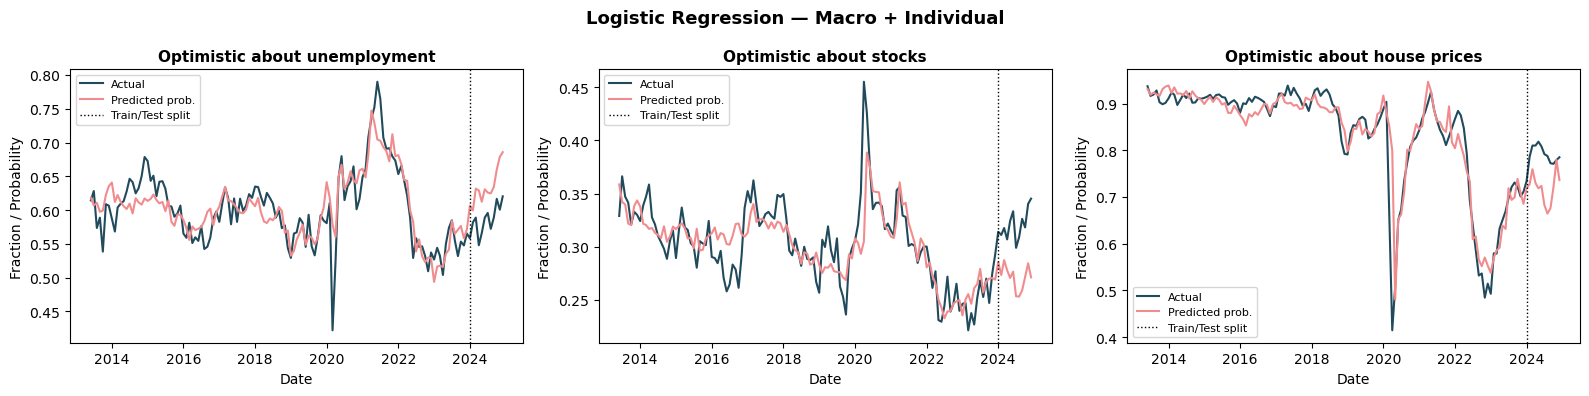

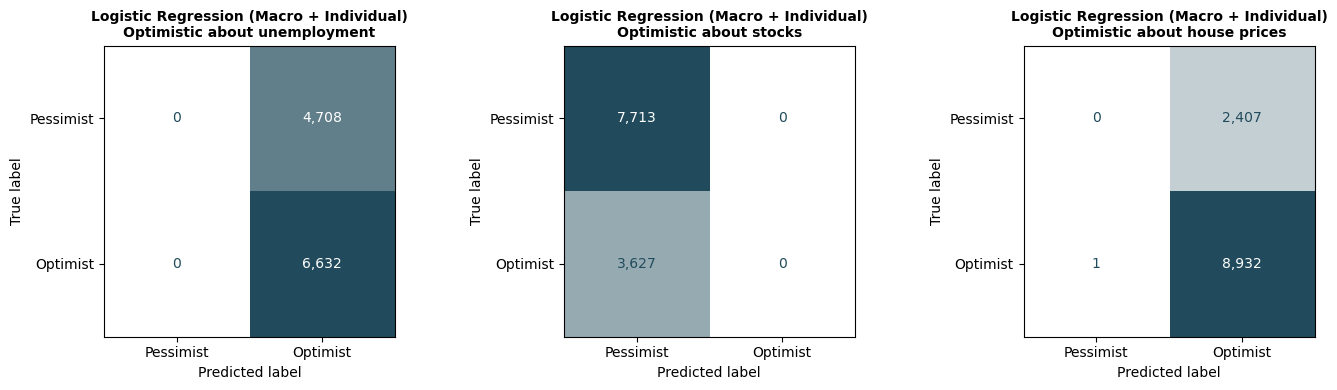

In [79]:
# Logistic Regression with macro + individual features for each optimist target
run_classification_experiment('Logistic Regression', train_logistic, feat_name_macro_indiv, indiv_features_opt)

##### **Random forest**


  Random Forest (Macro + Individual) — Hyperparameters


,Best max_depth,CV F1
Target,,
optimist_unrate,4,0.7520
optimist_stocks,10,0.0582
optimist_house_price,8,0.9141



  Random Forest (Macro + Individual) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.605,0.605,0.996,0.752
optimist_stocks,0.703,0.685,0.039,0.075
optimist_house_price,0.846,0.851,0.990,0.915



  Random Forest (Macro + Individual) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.585,0.585,1.000,0.738
optimist_stocks,0.684,0.716,0.022,0.042
optimist_house_price,0.788,0.788,1.000,0.881


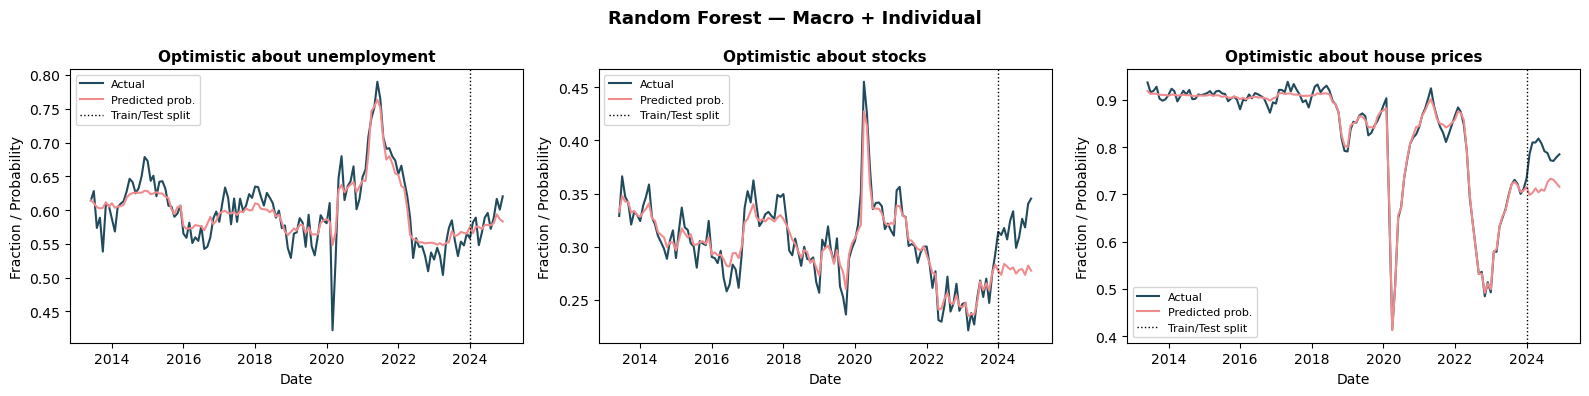

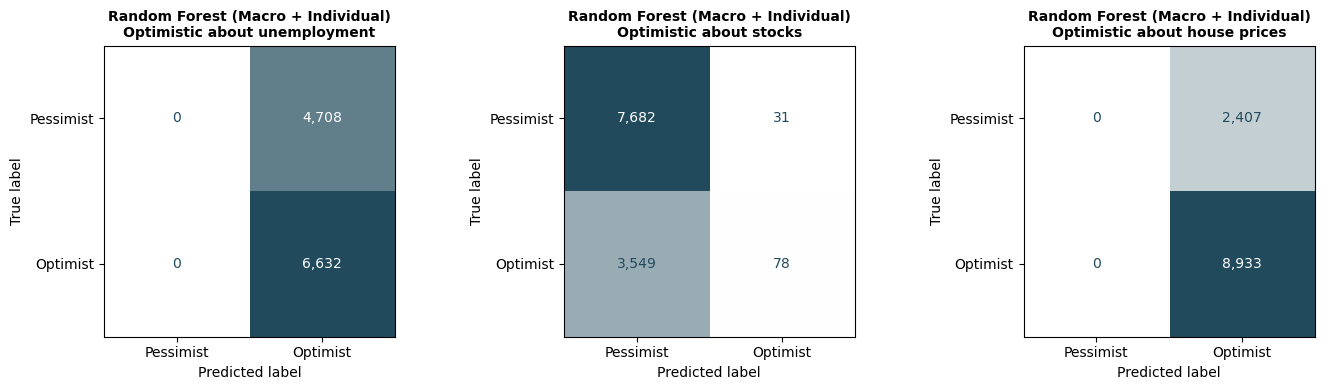

In [80]:
# Random Forest Classifier with macro + individual features for each optimist target
run_classification_experiment('Random Forest', train_random_forest, feat_name_macro_indiv, indiv_features_opt)

##### **HistGradientBoosting Classifier**


  HistGradientBoosting (Macro + Individual) — Hyperparameters


,Best max_depth,CV F1
Target,,
optimist_unrate,2,0.7501
optimist_stocks,6,0.1154
optimist_house_price,15,0.9150



  HistGradientBoosting (Macro + Individual) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.613,0.613,0.966,0.750
optimist_stocks,0.706,0.638,0.071,0.128
optimist_house_price,0.848,0.854,0.988,0.916



  HistGradientBoosting (Macro + Individual) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.590,0.590,0.979,0.736
optimist_stocks,0.689,0.650,0.058,0.106
optimist_house_price,0.788,0.788,1.000,0.881


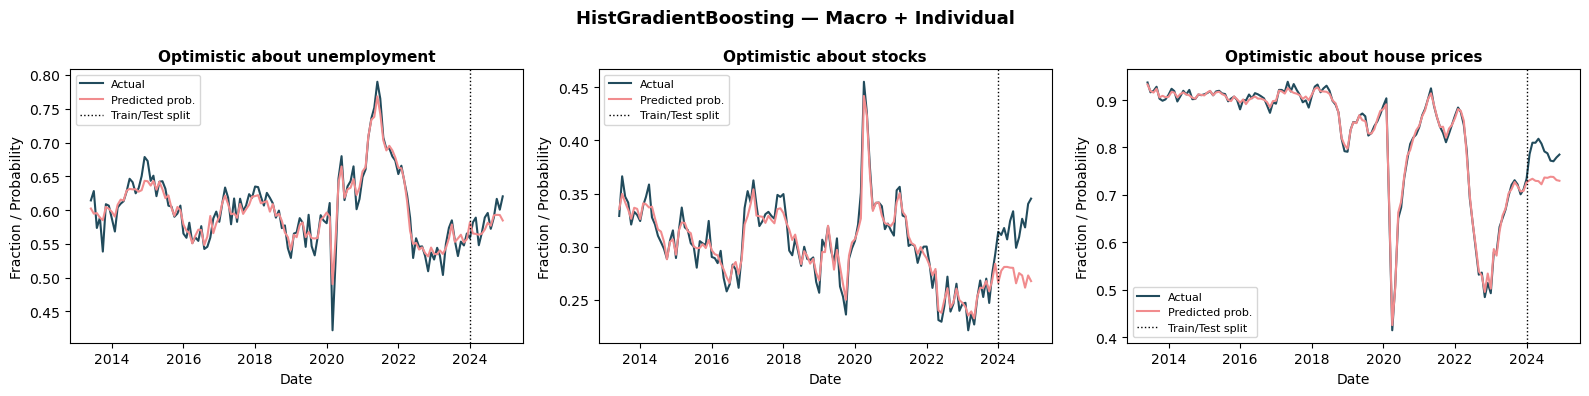

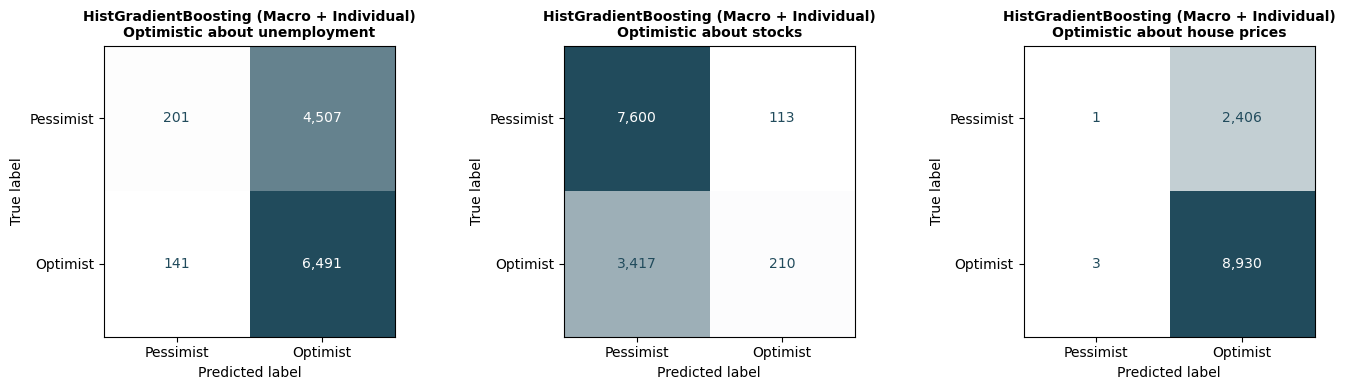

In [81]:
# HistGradientBoostingClassifier with macro + individual features for each optimist target
run_classification_experiment('HistGradientBoosting', train_hgb, feat_name_macro_indiv, indiv_features_opt)

##### **KNN Regression**


  KNN (Macro + Individual) — Hyperparameters


,Best n_neighbors,CV F1
Target,,
optimist_unrate,45,0.7219
optimist_stocks,5,0.2984
optimist_house_price,50,0.9127



  KNN (Macro + Individual) — Train set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.629,0.641,0.871,0.739
optimist_stocks,0.760,0.665,0.420,0.515
optimist_house_price,0.846,0.856,0.982,0.914



  KNN (Macro + Individual) — Test set


,Accuracy,Precision,Recall,F1
Target,,,,
optimist_unrate,0.582,0.633,0.682,0.656
optimist_stocks,0.670,0.467,0.221,0.300
optimist_house_price,0.786,0.788,0.997,0.880


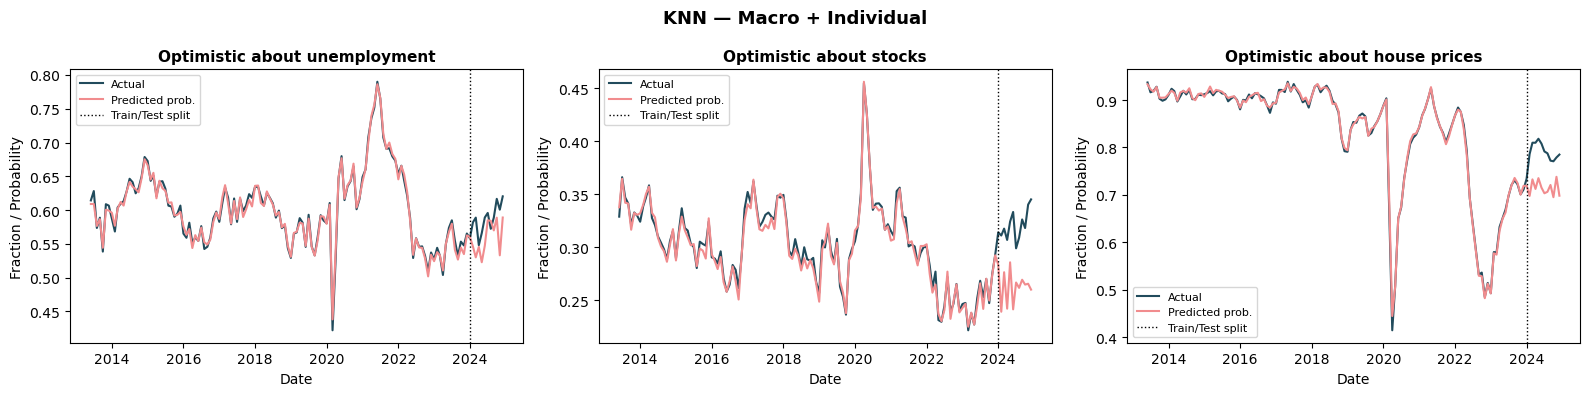

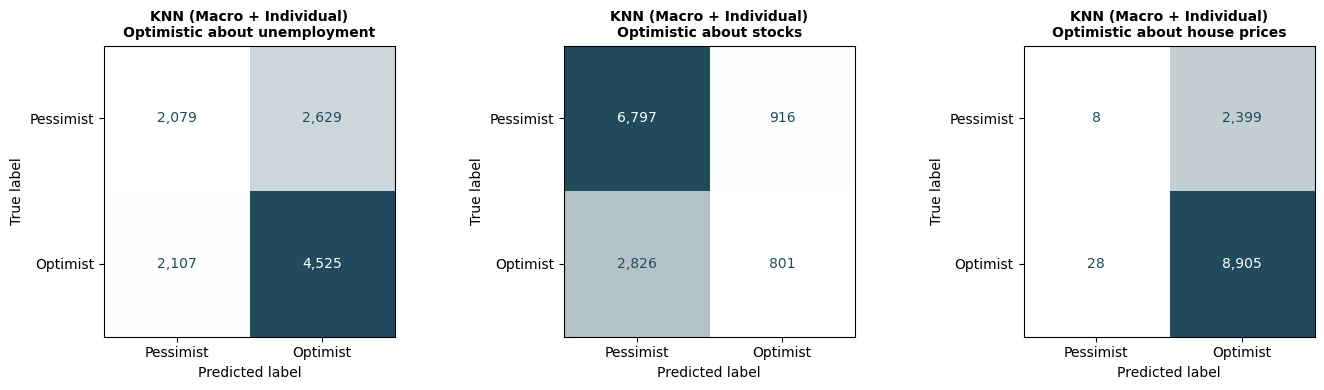

In [82]:
# K-Nearest Neighbors Classifier with macro + individual features for each optimist target
run_classification_experiment('KNN', train_knn, feat_name_macro_indiv, indiv_features_opt)

Adding individual-level variables leads to a modest but visible improvement compared to the macro-only results. The most notable change is for `optimist_stocks`, where adding the  individual variables now gives a non-zero F1 scores where KNN achieves the highest test F1 of 0.300, followed by HistGradientBoosting and Random Forest, compared to 0.000 for all models with macro variables alone. The improvment is also shown in the confusion matrices where KNN in particular now classifies a meaningful number of observations in both classes, with 801 correctly identified optimists and 916 correctly identified pessimists for `optimist_stocks`.

For `optimist_unrate` and `optimist_house_price`, performance is largely unchanged across all models with the majority of models continue to predict the dominant class for nearly all observations, and accuracy figures remain similar to the macro-only case. However we see an exception for KNN with `optimist_unrate`, which shows a more balanced confusion matrix.

Overall, the improvement from adding individual variables looks to not be  enogh to fundamentally change predictive performance for most models and targets. KNN stands out as benefiting the most from individual features, particularly for `optimist_stocks`, likely because it can exploit the demographic similarity between nearby respondents in feature space. Nevertheless, substantial heterogeneity in household optimism seems to remain unexplained across all models.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 6**

 - **Structure and readability:** The structure follows the logic from the prevoius parts of the notebook, increasing readability and making the code easy to follow. 

 - **Functions:** Helper functions are defined and used throughout part 6 to reuse code. Functions include both doc-strings and comments to explain the different steps in each function.

 - **Motivation of additional models:** Motivation of models used is given in part 7, as opposed to part 6 where they are introduced. The motivation given is thorough, and provides details for choices made regarding models.

 - **Correct use of models:** As `prepare_features` standardizes all features across models, the use of `StandardScaler` in `train_knn` is redundant and leads to features being standardize twice. Standardizing already standardized features doesn't dramatically impact the output, but should be avoided. Hyperparameters seems to be correctly cross-validated with GridSearchCV using F1 as the scoring metric.

 - **Scoring metrics:** Accuracy, precision, recall and F1 are reported for all models. The submission correctly acknowledges accuracy as misleading under class imbalance, and therefore uses F1 as the primary CV metric. AUC would benefit the submission, as it measures classification independently of the decision threshold and is not affected by class imbalance in the same way. 

***
# **Part 7 - Conclusion**
***

### **Summary of our effort to predict the expectation variables**

##### **Part 5 - Predicting Continuous Expectation Variables**

Linear, Ridge and Lasso regression all performed poorly, yielding low $R^2$ values and high RMSE across all four target variables. To address this, we explored improvements by trying additional models and refining the existing ones.

To explore whether more flexible models could improve predictions, we additionally fitted a Decision Tree and an ElasticNet. The Decision Tree was motivated by its ability to capture non-linear relationships and interactions between macro variables without requiring explicit feature engineering. ElasticNet was included as it combines the variable selection property of Lasso with the grouping property of Ridge, which could be beneficial when macro variables are correlated. However, neither model provided meaningful improvements over the simpler linear models, suggesting that the limited predictive signal in the macro variables is a fundamental constraint rather than a modelling problem.

We also explored feature engineering by constructing polynomial features and fitting the models through a pipeline. The motivation was that non-linear transformations of macro variables, such as squared terms or interaction effects, might capture relationships that linear models miss. However, this did not improve performance on the test set, and the added complexity made the code considerably harder to read and maintain. We therefore decided to exclude this approach from the final solution.

For hyperparameter selection, we employed a consistent cross-validation strategy across all models. We used KFold with 10 folds and random shuffle, as the SCE data is sorted chronologically and shuffling ensures each fold is representative of the full sample period. This strategy was applied uniformly to Ridge, Lasso, Elastic Net and Decision Tree to ensure comparability of cross-validated performance metrics. 

To extend the feature set with individual-level variables, we used a forward selection procedure. Each candidate variable was first tested in isolation before we evaluated the effect by building up combinations. As the variables could affect both the different targets and the different regression models unevenly, the final selection required an overall assessment of performance changes across all targets and models, balancing gains in predictive accuracy against the risk of overfitting. We stopped combining variables when we observed marginal or deteriorating performance across two or more consecutive additions.

The following individual targets were used in the regressions:
* **Inflation expectations:** `hh_inc_bin_rank`, `educ`, `female`, `black`, `couple`, `owner`
* **House price change:** `hh_inc_bin_rank`, `educ`, `black`, `female`
* **Probability of unemployment increase:** `educ`, `female`, `age_init`, `black`
* **Probability of stock price increase:** `educ`, `female`, `hh_inc_bin_rank`, `black`, `hispanic`, `working`, `age_init`, `num_kids`, `couple`

However, multicollinearity it is worth considering. In linear regression , high multicollinearity inflates the variance of the estimated coefficients and can produce large, unstable estimates that differ substantially across samples, even when the fitted values and predictions are similar. Ridge, Lasso, and ElasticNet directly address this by shrinking the coefficients toward zero, which stabilises the estimates at the cost of introducing a small bias. This is one reason to prefer regularised linear models over linear regression when for example macro variables in levels are included alongside their year-on-year differences can cause this.


##### **Part 6 - Predicting Binary Optimism Variables**

Logistic regression and Random forest performed poorly which might be due to class imbalance and low correlation between the macro variables and target variables. With the majority of respondents classified as optimists, models defaulted to predicting the majority class, resulting in high accuracy but poor F1 scores and confusion matrices dominated by zeros in one column.

To explore whether more flexible models could improve predictions, we initially fitted standard logistic regression, but found that adding predicted probabilities from the macro models as features produced substantially better results. We therefore extended the classifier set with a HistGradientBoosting classifier and a K-Nearest Neighbors classifier. HistGradientBoosting was motivated by its ability to capture complex non-linear relationships and interactions between features, while KNN was included as a non-parametric alternative that makes no assumptions about the functional form of the decision boundary. Across all macro-only specifications, logistic regression was the weakest performer overall, while KNN achieved the best F1 scores, though gains remained limited given the restricted signal in the macro features.

When extending the feature set to include individual-level variables, we followed the same forward selection approach as in Part 5, adding features one at a time and stopping when additional variables produced marginal or deteriorating F1 scores across two or more consecutive additions. The inclusion of individual variables produced noticeably better confusion matrices, with models more accurately identifying observations in both classes. The improvement was most pronounced for `optimist_stocks`, where KNN achieved a test F1 of 0.300, followed by HistGradientBoosting and Random Forest, compared to 0.000 for all models with macro features alone. This might be due to optimistic about stock prices have stronger correlation with some of the individual variables than the other target optimistic variables. KNN in particular showed a more balanced confusion matrix, correctly identifying a meaningful number of observations in both classes as respondents close to each other in terms of income, age, and education tend to share similar views on the stock market. For `optimist_unrate` and `optimist_house_price`, performance was largely unchanged across feature sets, with most models continuing to predict the dominant class for nearly all observations. The following individual features were retained:
* **Optimist unemployment:** `female`, `educ`, `age_init`, `black`, `hispanic`
* **Optimist stocks:** `female`, `educ`,`hh_inc_bin_rank`, `black`, `age_init`, `working`, `hispanic`
* **Optimist house price:** `age_init`, `num_kids`, `female`, `owner`, `working`


### **Summary of our best models and feature sets**

##### **Part 5 - Predicting Continuous Expectation Variables**

In [83]:
# Build summary table comparing RMSE and R² across all models and feature sets
rows = []
for label, targets in results.items():
    feat_set = 'Macro only' if 'Macro only' in label else 'Macro + Individual'
    model    = label.replace(' (Macro only)', '').replace(' (Macro + Individual)', '')
    for target, (rmse, r2) in targets.items():
        rows.append({
            'Model':       model,
            'Feature set': feat_set,
            'Target':      target,
            'RMSE':        round(rmse, 4),
            'R²':          round(r2,   4),
        })

summary = pd.DataFrame(rows)

# Print one table per target variable
for target in indiv_features.keys():
    print("\n" + "=" * 120)
    print(f"Results for {target}")
    print("=" * 120)

    tbl = summary[summary['Target'] == target].copy()
    tbl = tbl.drop(columns='Target')
    tbl = tbl.set_index(['Model', 'Feature set']).sort_index()
    display(tbl)

    # Print only the individual features for this target
    indiv_only = [f for f in indiv_features[target] if f not in macro_features_cols]
    print(f"\nSelected individual features: {indiv_only}")


Results for infl_1y


RMSE      R²
Model             Feature set                       
Decision Tree     Macro + Individual  8.9740  0.0130
                  Macro only          9.0446 -0.0026
Elastic Net       Macro + Individual  8.8923  0.0308
                  Macro only          9.0954 -0.0139
Lasso             Macro + Individual  8.8925  0.0308
                  Macro only          9.0955 -0.0140
Linear Regression Macro + Individual  8.8926  0.0308
                  Macro only          9.0993 -0.0148
Ridge             Macro + Individual  8.8924  0.0308
                  Macro only          9.0974 -0.0144


Selected individual features: ['hh_inc_bin_rank', 'educ', 'female', 'black', 'couple', 'owner']

Results for house_price_change


RMSE      R²
Model             Feature set                       
Decision Tree     Macro + Individual  7.9951  0.0079
                  Macro only          8.0780 -0.0128
Elastic Net       Macro + Individual  7.9011  0.0311
                  Macro only          8.0453 -0.0046
Lasso             Macro + Individual  7.9013  0.0310
                  Macro only          8.0451 -0.0046
Linear Regression Macro + Individual  7.9013  0.0310
                  Macro only          8.0451 -0.0046
Ridge             Macro + Individual  7.9011  0.0311
                  Macro only          8.0452 -0.0046


Selected individual features: ['hh_inc_bin_rank', 'educ', 'black', 'female']

Results for prob_unrate_up


RMSE      R²
Model             Feature set                        
Decision Tree     Macro + Individual  22.2596 -0.0035
                  Macro only          22.5316 -0.0282
Elastic Net       Macro + Individual  21.9850  0.0211
                  Macro only          22.2642 -0.0039
Lasso             Macro + Individual  21.9847  0.0211
                  Macro only          22.2642 -0.0039
Linear Regression Macro + Individual  21.9851  0.0211
                  Macro only          22.3080 -0.0079
Ridge             Macro + Individual  21.9851  0.0211
                  Macro only          22.2951 -0.0067


Selected individual features: ['educ', 'female', 'age_init', 'black']

Results for prob_stocks_up


RMSE      R²
Model             Feature set                        
Decision Tree     Macro + Individual  21.8902  0.0402
                  Macro only          22.4445 -0.0090
Elastic Net       Macro + Individual  21.2734  0.0935
                  Macro only          22.4839 -0.0126
Lasso             Macro + Individual  21.2730  0.0936
                  Macro only          22.4839 -0.0126
Linear Regression Macro + Individual  21.2744  0.0934
                  Macro only          22.5101 -0.0149
Ridge             Macro + Individual  21.2737  0.0935
                  Macro only          22.5035 -0.0143


Selected individual features: ['educ', 'female', 'hh_inc_bin_rank', 'black', 'hispanic', 'working', 'age_init', 'num_kids', 'couple']


The regularised linear models which is Ridge, Lasso, and ElasticNet, consistently achieve the best performance across all four targets, with virtually identical metrics between them. Decision Tree is the weakest performer throughout, showing higher RMSE and lower $R^2$ than the linear models even when individual variables are included.

For featurure sets, the regression including the individual variables consistently outperforms only using the macro variables across all models and targets without exception. The improvement is most pronounced for `prob_stocks_up`, where the best model achieves an RMSE of 21.27 and $R^2$ of 0.094, compared to negative $R^2$ values with macro features alone. For the remaining targets the gains are more modest, though the direction is consistent.

Despite these improvements, the absolute level of predictive performance remains low throughout. This might suggest that a large share of the variation in household expectations reflects individual heterogeneity that is not captured by the available macro, financial, or demographic variables.

##### **Part 6 - Predicting Binary Optimism Variables**

In [84]:
# Build summary table
rows = []
for label, targets in cls_results.items():
    feat_set = 'Macro only' if 'Macro only' in label else 'Macro + Individual'
    model    = label.replace(' (Macro only)', '').replace(' (Macro + Individual)', '')
    for target, metrics in targets.items():
        rows.append({
            'Model':       model,
            'Feature set': feat_set,
            'Target':      target,
            **{k: round(v, 3) for k, v in metrics.items()}
        })

summary_cls = pd.DataFrame(rows)

# Print one table per target variable
for target in opt_vars:
    print("\n" + "=" * 120)
    print(f"Results for {target}")
    print("=" * 120)

    tbl = summary_cls[summary_cls['Target'] == target].copy()
    tbl = tbl.drop(columns='Target')
    tbl = tbl.set_index(['Model', 'Feature set']).sort_index()
    display(tbl)

    # Print only the individual features for this target
    indiv_only = [f for f in indiv_features_opt.get(target, []) if f not in macro_features_cols]
    print(f"\nSelected individual features: {indiv_only}")


Results for optimist_unrate


Accuracy  Precision  Recall     F1  \
Model                Feature set                                              
HistGradientBoosting Macro + Individual     0.590      0.590   0.979  0.736   
                     Macro only             0.585      0.585   1.000  0.738   
KNN                  Macro + Individual     0.582      0.633   0.682  0.656   
                     Macro only             0.585      0.585   1.000  0.738   
Logistic Regression  Macro + Individual     0.585      0.585   1.000  0.738   
                     Macro only             0.585      0.585   1.000  0.738   
Random Forest        Macro + Individual     0.585      0.585   1.000  0.738   
                     Macro only             0.585      0.585   1.000  0.738   

                                         Best C  CV F1  Best max_depth  \
Model                Feature set                                         
HistGradientBoosting Macro + Individual     NaN  0.750             2.0   
                     Macro only             NaN  0.751             2.0   
KNN                  Macro + Individual     NaN  0.722             NaN   
                     Macro only             NaN  0.738             NaN   
Logistic Regression  Macro + Individual  14.384  0.751             NaN   
                     Macro only           0.010  0.750             NaN   
Random Forest        Macro + Individual     NaN  0.752             4.0   
                     Macro only             NaN  0.752             2.0   

                                         Best n_neighbors  
Model                Feature set                           
HistGradientBoosting Macro + Individual               NaN  
                     Macro only                       NaN  
KNN                  Macro + Individual              45.0  
                     Macro only                      45.0  
Logistic Regression  Macro + Individual               NaN  
                     Macro only                       NaN  
Random Forest        Macro + Individual               NaN  
                     Macro only                       NaN


Selected individual features: ['female', 'educ', 'age_init', 'black', 'hispanic']

Results for optimist_stocks


Accuracy  Precision  Recall     F1  \
Model                Feature set                                              
HistGradientBoosting Macro + Individual     0.689      0.650   0.058  0.106   
                     Macro only             0.680      0.000   0.000  0.000   
KNN                  Macro + Individual     0.670      0.467   0.221  0.300   
                     Macro only             0.680      0.000   0.000  0.000   
Logistic Regression  Macro + Individual     0.680      0.000   0.000  0.000   
                     Macro only             0.680      0.000   0.000  0.000   
Random Forest        Macro + Individual     0.684      0.716   0.022  0.042   
                     Macro only             0.680      0.000   0.000  0.000   

                                         Best C  CV F1  Best max_depth  \
Model                Feature set                                         
HistGradientBoosting Macro + Individual     NaN  0.115             6.0   
                     Macro only             NaN  0.000             2.0   
KNN                  Macro + Individual     NaN  0.298             NaN   
                     Macro only             NaN  0.185             NaN   
Logistic Regression  Macro + Individual   5.456  0.019             NaN   
                     Macro only           0.010  0.000             NaN   
Random Forest        Macro + Individual     NaN  0.058            10.0   
                     Macro only             NaN  0.000             2.0   

                                         Best n_neighbors  
Model                Feature set                           
HistGradientBoosting Macro + Individual               NaN  
                     Macro only                       NaN  
KNN                  Macro + Individual               5.0  
                     Macro only                       5.0  
Logistic Regression  Macro + Individual               NaN  
                     Macro only                       NaN  
Random Forest        Macro + Individual               NaN  
                     Macro only                       NaN


Selected individual features: ['female', 'educ', 'hh_inc_bin_rank', 'black', 'age_init', 'working', 'hispanic']

Results for optimist_house_price


Accuracy  Precision  Recall     F1  \
Model                Feature set                                              
HistGradientBoosting Macro + Individual     0.788      0.788   1.000  0.881   
                     Macro only             0.788      0.788   1.000  0.881   
KNN                  Macro + Individual     0.786      0.788   0.997  0.880   
                     Macro only             0.788      0.788   1.000  0.881   
Logistic Regression  Macro + Individual     0.788      0.788   1.000  0.881   
                     Macro only             0.788      0.788   1.000  0.881   
Random Forest        Macro + Individual     0.788      0.788   1.000  0.881   
                     Macro only             0.788      0.788   1.000  0.881   

                                         Best C  CV F1  Best max_depth  \
Model                Feature set                                         
HistGradientBoosting Macro + Individual     NaN  0.915            15.0   
                     Macro only             NaN  0.913             2.0   
KNN                  Macro + Individual     NaN  0.913             NaN   
                     Macro only             NaN  0.913             NaN   
Logistic Regression  Macro + Individual    0.01  0.912             NaN   
                     Macro only            0.01  0.913             NaN   
Random Forest        Macro + Individual     NaN  0.914             8.0   
                     Macro only             NaN  0.914             3.0   

                                         Best n_neighbors  
Model                Feature set                           
HistGradientBoosting Macro + Individual               NaN  
                     Macro only                       NaN  
KNN                  Macro + Individual              50.0  
                     Macro only                      45.0  
Logistic Regression  Macro + Individual               NaN  
                     Macro only                       NaN  
Random Forest        Macro + Individual               NaN  
                     Macro only                       NaN


Selected individual features: ['age_init', 'num_kids', 'female', 'owner', 'working']


For the binary optimism variable, the classification results paint a more nuanced picture across the three targets.

For `optimist_unrate`, all models perform similarly regardless of feature set, with accuracy around 0.585 and F1 around 0.738. Most models collapse to predicting the majority class, achieving perfect recall but near-zero precision for the minority class. Adding individual variables does not meaningfully improve performance, with HistGradientBoosting being the marginal exception at an F1 of 0.736 with including the individual variables.

For `optimist_stocks`, all models collapse entirely to predicting the majority class when using only macro features, yielding F1 scores of 0. Adding individual variables breaks this pattern, with KNN achieving the best test F1 of 0.300 and HistGradientBoosting following at 0.106. This confirms that demographic characteristics carry predictive signal for stock market optimism that macro variables alone cannot capture.

For `optimist_house_price`, all models achieve virtually identical results across both feature sets, with accuracy of 0.788 and F1 of 0.881. However, the high F1  may be driven by the strong class imbalance. Most respondents are optimistic about house prices, and the models achieve this by predicting the majority class for nearly all observations, as evidenced by recall values of 1.000 throughout. Adding individual variables provides no meaningful improvement for this target.

Overall, KNN with both macro and individual variables stands out as the best-performing classification model, particularly for `optimist_stocks`, while the remaining models and targets show limited sensitivity to either model choice or feature set.

<h3 style="color: steelblue; font-size: 2em; font-weight: bold;">Peer review comments</h3>

**Part 7**

 - **Structure and readability:** Part 7 is, as the rest of the notebook, well-structured and easy to read. Code and interpretations are split into distinct parts, with headers to define each part. Summary tables are built using `results` and `cls_results`, presenting output in a clear way. 

 - **Motivation of models used:** Thorough explanations of different models and their motivations demonstrates good understanding of the underlying economic concepts. Mentioning the test and excluding of the polynomial model provides details for the motivation of models selected, as well as critical reflection regarding choice of models. 